# Imports

In [2]:
import numpy as np
import ripser
import gudhi as gd
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

# Henon map

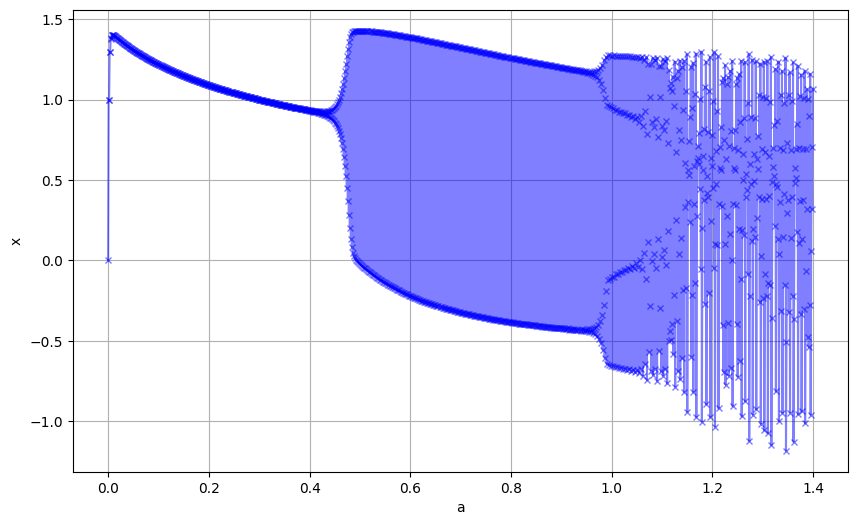

In [5]:
# parameters
b = 0.3
sigma = 0.01
step = 0.001
n_points = 1400

# initialize arrays
x = np.zeros(n_points)
y = np.zeros(n_points)
a = np.zeros(n_points)
gaussian_noise = np.random.normal(0, 1, n_points)

# compute henon map with varying 'a' parameter
for i in range(1, n_points):
    x[i] = 1 - a[i-1] * x[i-1]**2 + b * y[i-1] + sigma * gaussian_noise[i-1] * np.sqrt(step)
    y[i] = x[i-1] + sigma * gaussian_noise[i-1] * np.sqrt(step) 
    a[i] = a[i-1] + step

# plot the trajectory (x vs a) with dots connected by lines
plt.figure(figsize=(10, 6))
plt.plot(a, x, marker='x', markersize=4, linestyle='-', color='blue', alpha=0.5)
plt.xlabel("a")
plt.ylabel("x")
plt.grid()
plt.show()

c:\Users\eliot\Desktop\MVA\Time Series\project\tda_finance\.venv\lib\site-packages\gudhi\persistence_graphical_tools.py:129: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


<Axes: title={'center': 'Persistence diagram'}, xlabel='Birth', ylabel='Death'>

<Figure size 800x600 with 0 Axes>

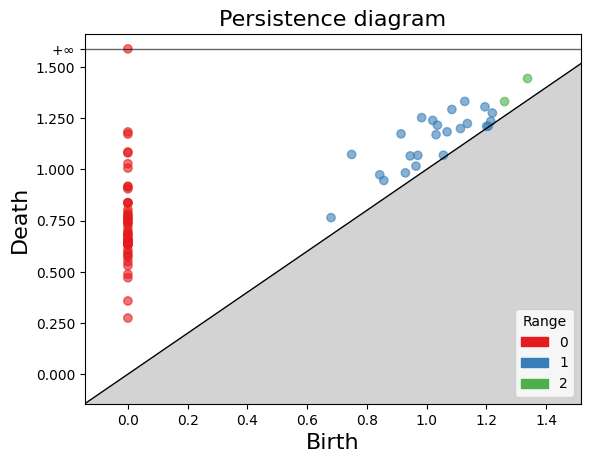

In [6]:
w = 50
b_values = [0.27, 0.28, 0.29, 0.3]

x = np.zeros((n_points, len(b_values)))
y = np.zeros((n_points, len(b_values)))
a = np.zeros((n_points, len(b_values)))
gaussian_noise = np.random.normal(0, 1, (n_points, len(b_values)))

for j, b in enumerate(b_values):
    for i in range(1, n_points):
        x[i, j] = 1 - a[i-1, j] * x[i-1, j]**2 + b * y[i-1, j] + sigma * gaussian_noise[i-1, j] * np.sqrt(step)
        y[i, j] = x[i-1, j] + sigma * gaussian_noise[i-1, j] * np.sqrt(step) 
        a[i, j] = a[i-1, j] + step

# compute the persistence diagrams of this 4D for every sliding window
diagrams = []
for i in range(n_points - w):
    window = x[i:i+w, :]  # shape (w, 4)
    rips = ripser.ripser(window, maxdim=2)
    diagrams.append(rips['dgms'])

# plot the persistence diagram of the last sliding window
plt.figure(figsize=(8, 6))
gd.plot_persistence_diagram(diagrams[-1])

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is 

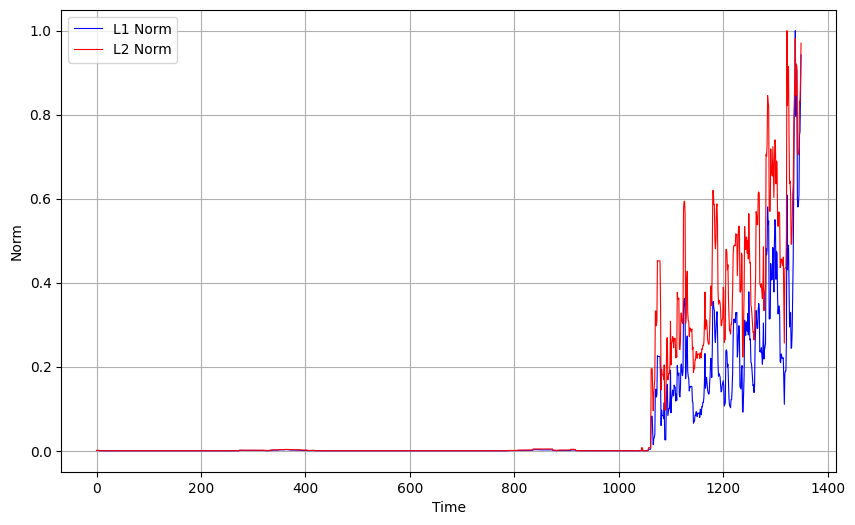

In [7]:
# plot the L^1 and L^2 norms of the persistence landscapes over time on the same plot
import gudhi.representations as grepr

l1_norms = []
l2_norms = []
for diag in diagrams:
    pl = grepr.Landscape(num_landscapes=10, resolution=500)
    landscape = pl.fit_transform([diag[1]])[0]
    l1_norms.append(np.sum(np.abs(landscape)))
    l2_norms.append(np.sqrt(np.sum(landscape**2)))

# min-max normalize the norms
l1_norms = (np.array(l1_norms) - np.min(l1_norms)) / (np.max(l1_norms) - np.min(l1_norms) + 1e-10)
l2_norms = (np.array(l2_norms) - np.min(l2_norms)) / (np.max(l2_norms) - np.min(l2_norms) + 1e-10)

plt.figure(figsize=(10, 6))
plt.plot(l1_norms, label='L1 Norm', color='blue', linewidth=0.8)
plt.plot(l2_norms, label='L2 Norm', color='red', linewidth=0.8)
plt.xlabel("Time")
plt.ylabel("Norm")
plt.legend()
plt.grid()

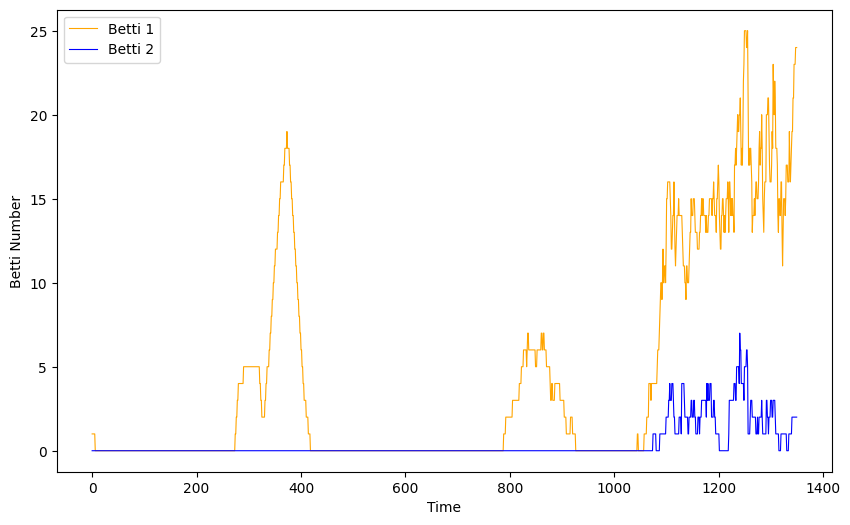

In [9]:
# plot Betti numbers over time
betti_1 = []
betti_2 = []
for diag in diagrams:
    b1 = np.sum(diag[1][:, 1] - diag[1][:, 0] > 0)
    b2 = np.sum(diag[2][:, 1] - diag[2][:, 0] > 0)
    betti_1.append(b1)
    betti_2.append(b2)

plt.figure(figsize=(10, 6))
plt.plot(betti_1, label='Betti 1', color='orange', linewidth=0.8)
plt.plot(betti_2, label='Betti 2', color='blue', linewidth=0.8)
plt.xlabel("Time")
plt.ylabel("Betti Number")
plt.legend()
plt.show()

# Ising model

In [10]:
# generate a vector representing m steps of a 2D Ising model with interactions at a given temperature. Return all the steps as a m -length vector of n^2 vectors

def ising_model_2d(n, m, temperature):
    def metropolis_step(spins, beta):
        for _ in range(n * n):
            i = np.random.randint(0, n)
            j = np.random.randint(0, n)
            delta_E = 2 * spins[i, j] * (
                spins[(i + 1) % n, j] + spins[(i - 1) % n, j] +
                spins[i, (j + 1) % n] + spins[i, (j - 1) % n]
            )
            if delta_E < 0 or np.random.rand() < np.exp(-beta * delta_E):
                spins[i, j] *= -1
        return spins

    beta = 1.0 / temperature
    spins = np.random.choice([-1, 1], size=(n, n))
    configurations = []

    for _ in range(m):
        spins = metropolis_step(spins, beta)
        configurations.append(spins.copy().flatten())

    # return last configuration as a numpy array
    return np.array(configurations[-1])

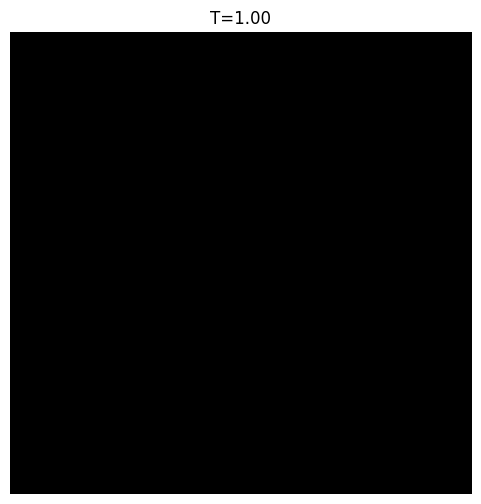

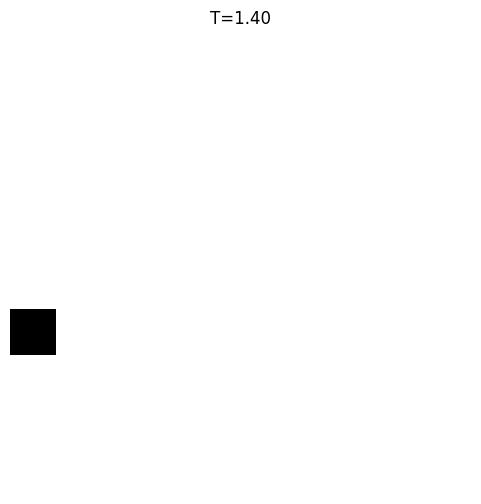

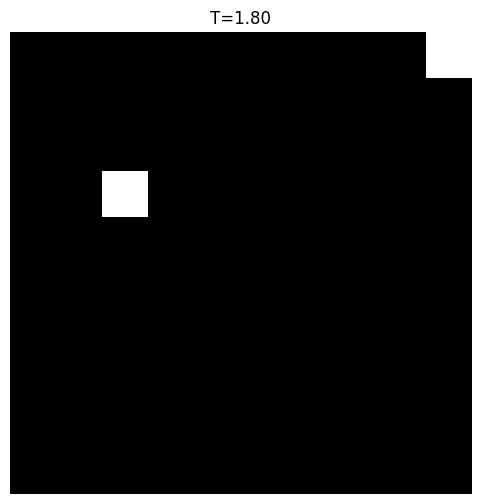

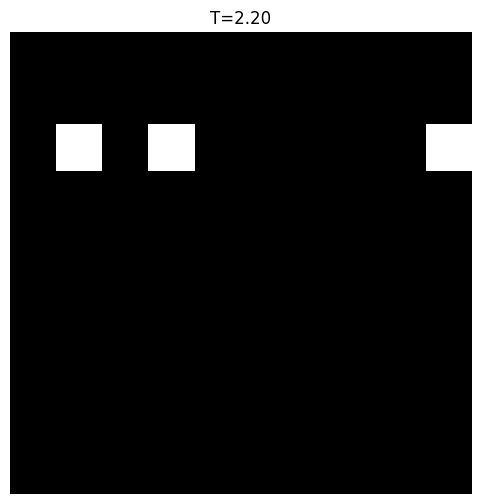

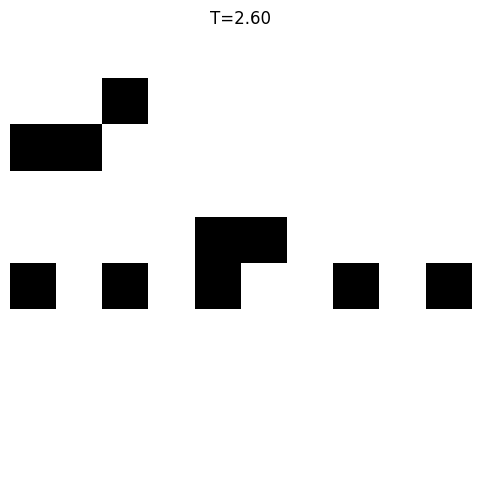

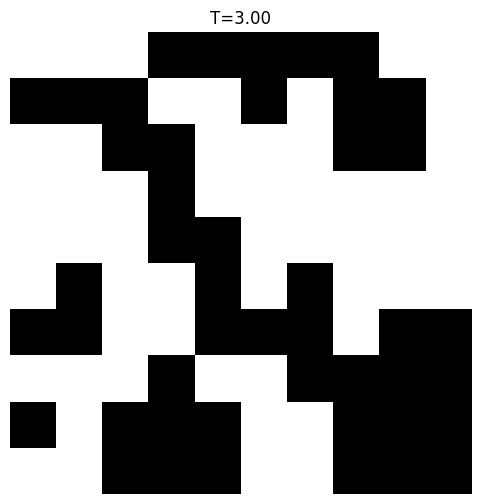

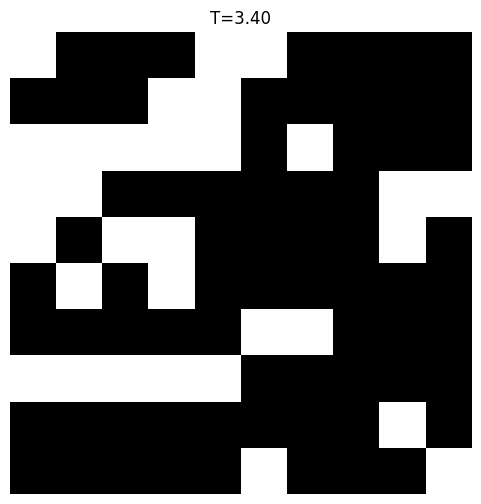

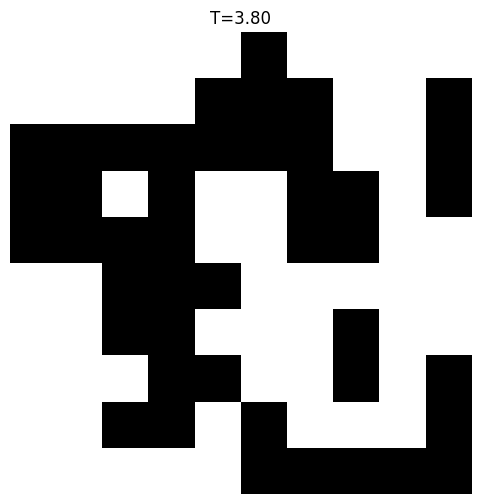

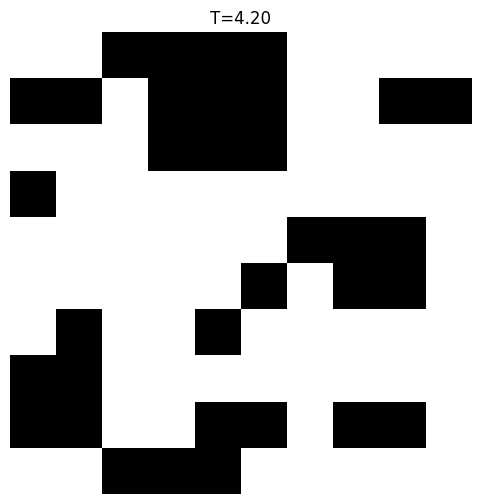

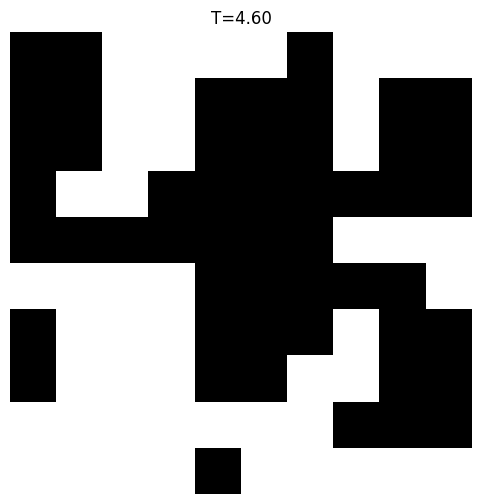

(1000, 100)


In [13]:
X = np.zeros((1000, 100))
tempratures = np.linspace(1, 5, 1000)
for i, T in enumerate(tempratures):
    X[i] = ising_model_2d(10, 100, T).flatten()
    # visualize Ising model for every 100 steps
    if i % 100 == 0:
        plt.figure(figsize=(6, 6))
        plt.imshow(X[i].reshape(10, 10), cmap='gray')
        plt.title(f'T={T:.2f}')
        plt.axis('off')
        plt.show()
print(X.shape)

In [14]:
# compute persistence diagrams for the Ising model configurations using sliding windows
w = 50
diagrams_ising = []
for i in range(X.shape[0] - w):
    window = X[i:i+w, :]  # shape (w, n^2)
    rips = ripser.ripser(window, maxdim=2)
    diagrams_ising.append(rips['dgms'])

c:\Users\eliot\Desktop\MVA\Time Series\project\tda_finance\.venv\lib\site-packages\ripser\ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
c:\Users\eliot\Desktop\MVA\Time Series\project\tda_finance\.venv\lib\site-packages\ripser\ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
c:\Users\eliot\Desktop\MVA\Time Series\project\tda_finance\.venv\lib\site-packages\ripser\ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
c:\Users\eliot\Desktop\MVA\Time Series\project\tda_finance\.venv\lib\site-packages\ripser\ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
c:\Users\eliot\Desktop\MVA\Time Series\project\tda_finance\.venv\lib\site-packages\ripser\ripser.py:253: UserWarning: The input point cloud has more col

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is 

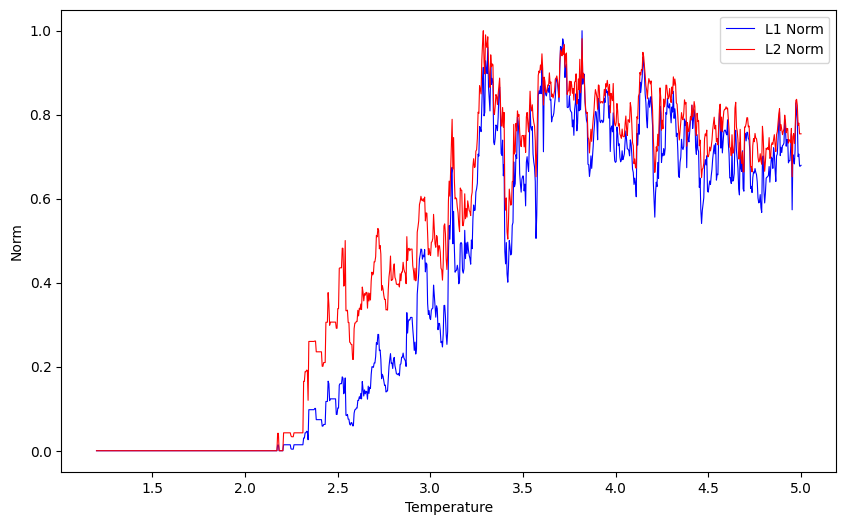

In [15]:
# plot the L^1 and L^2 norms of the persistence landscapes over time on the same plot

import gudhi.representations as grepr

l1_norms_ising = []
l2_norms_ising = []

for diag in diagrams_ising:
    pl = grepr.Landscape(num_landscapes=10, resolution=500)
    landscape = pl.fit_transform([diag[1]])[0]
    l1_norms_ising.append(np.sum(np.abs(landscape)))
    l2_norms_ising.append(np.sqrt(np.sum(landscape**2)))

# normalize the norms between 0 and 1
l1_norms_ising = (np.array(l1_norms_ising) - np.min(l1_norms_ising)) / (np.max(l1_norms_ising) - np.min(l1_norms_ising) + 1e-10)
l2_norms_ising = (np.array(l2_norms_ising) - np.min(l2_norms_ising)) / (np.max(l2_norms_ising) - np.min(l2_norms_ising) + 1e-10)

plt.figure(figsize=(10, 6))
plt.plot(tempratures[w:], l1_norms_ising, label='L1 Norm', color='blue', linewidth=0.8)
plt.plot(tempratures[w:], l2_norms_ising, label='L2 Norm', color='red', linewidth=0.8)
plt.xlabel("Temperature")
plt.ylabel("Norm")
plt.legend()
plt.show()

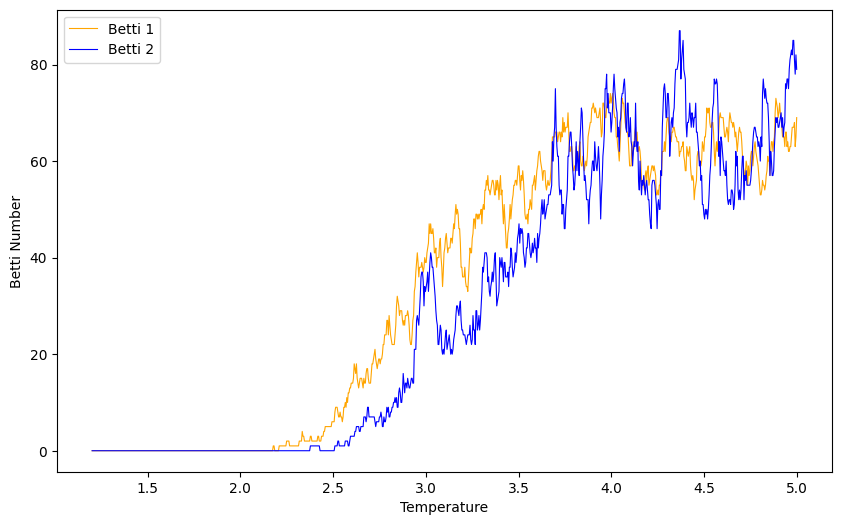

In [16]:
# plot Betti numbers over time
betti_1 = []
betti_2 = []
for diag in diagrams_ising:
    b1 = np.sum(diag[1][:, 1] - diag[1][:, 0] > 0)
    b2 = np.sum(diag[2][:, 1] - diag[2][:, 0] > 0)
    betti_1.append(b1)
    betti_2.append(b2)

plt.figure(figsize=(10, 6))
plt.plot(tempratures[w:], betti_1, label='Betti 1', color='orange', linewidth=0.8)
plt.plot(tempratures[w:], betti_2, label='Betti 2', color='blue', linewidth=0.8)
plt.xlabel("Temperature")
plt.ylabel("Betti Number")
plt.legend()
plt.show()

# White noise with Gamma-distributed inverse variance

In [17]:
X = []
num_clouds = 100
points_per_cloud = 100
scale_param = 8.0
beta_param = 1.0
M = 100 # number of Monte Carlo simulations

l1_norms_mc = []

for _ in range(M):
    X = []
    scale_param = 8.0
    for i in range(num_clouds):
        if i >= 75:
            scale_param -= 0.25
        variances = np.random.gamma(shape=2.0, scale=scale_param, size=4)
        std_devs = np.sqrt(1 / variances)
        cloud = np.random.normal(loc=0.0, scale=std_devs, size=(points_per_cloud, 4))
        X.append(cloud)
    
    diagrams_mc = []
    for cloud in X:
        rips = ripser.ripser(cloud)
        diagrams_mc.append(rips['dgms'])

    l1_norms_temp = []
    for diag in diagrams_mc:
        pl = grepr.Landscape(num_landscapes=10, resolution=500)
        landscape = pl.fit_transform([diag[1]])[0]
        l1_norms_temp.append(np.sum(np.abs(landscape)))
    l1_norms_mc.append(l1_norms_temp)
    
l1_norms_mc = np.array(l1_norms_mc)
l1_norms = np.mean(l1_norms_mc, axis=0)
l1_norms = (l1_norms - np.mean(l1_norms)) / np.std(l1_norms)

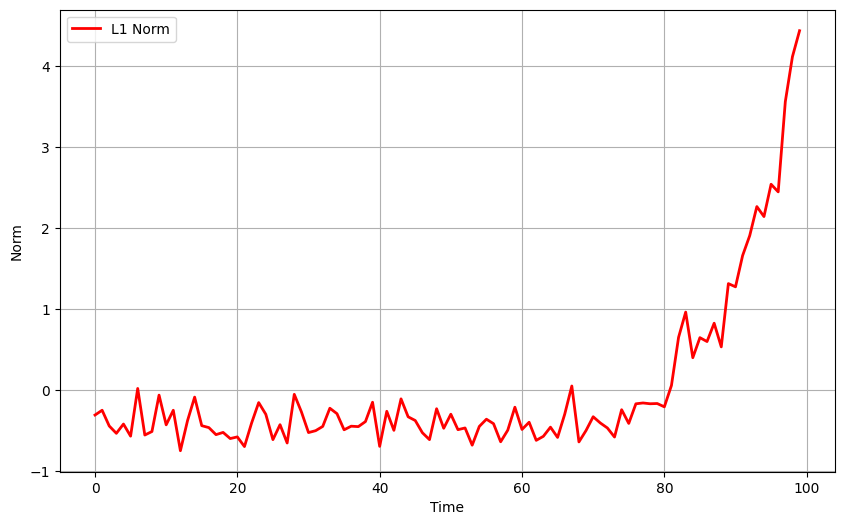

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(l1_norms, label='L1 Norm', color='red', linewidth=2)
plt.xlabel("Time")
plt.ylabel("Norm")
plt.legend()
plt.grid()
plt.show()

# Empirical analysis of financial data - Dotcom and Lehman Brothers crashes

In [99]:
# We analyze the daily time series of four major US stock market indices: S&P 500, DJIA, NASDAQ, Russel 2000? and VIX between December 23, 1987 and December 08, 2016 (7301 trading days). The times series data were downloaded from Yahoo Finance

tickers = ['^GSPC', '^DJI', '^IXIC', '^RUT', '^VIX']
data = yf.download(tickers, start='1987-12-23', end='2016-12-08')['Close']

C:\Users\eliot\AppData\Local\Temp\ipykernel_21168\4276305204.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='1987-12-23', end='2016-12-08')['Close']
[*********************100%***********************]  5 of 5 completed


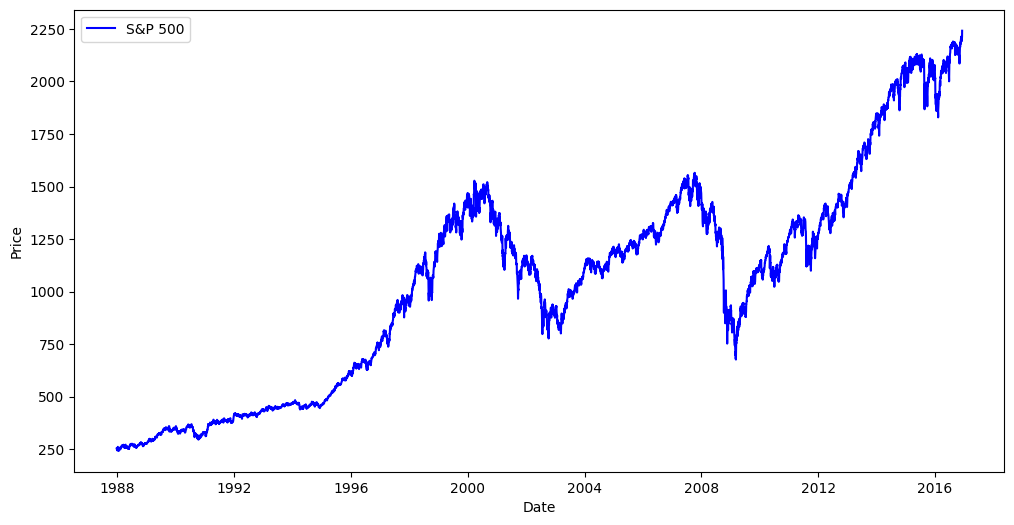

In [100]:
# plot SP500 time series
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['^GSPC'], label='S&P 500', color='blue')
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

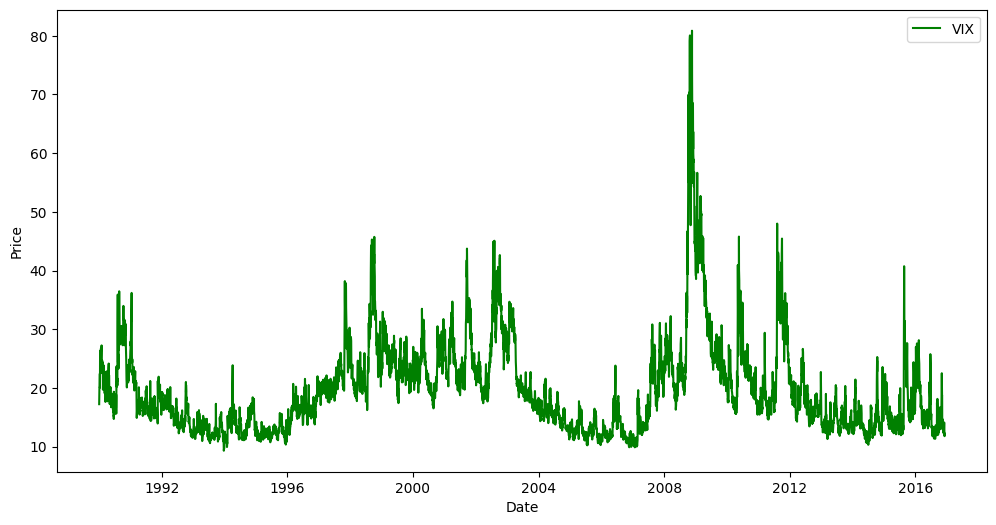

In [101]:
# plot VIX time series
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['^VIX'], label='VIX', color='green')
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [102]:
# calculate log returns for all tickers except VIX
log_returns = np.log(data[tickers[:-1]] / data[tickers[:-1]].shift(1)).fillna(0)

 41%|████      | 2947/7200 [00:06<00:09, 465.63it/s]

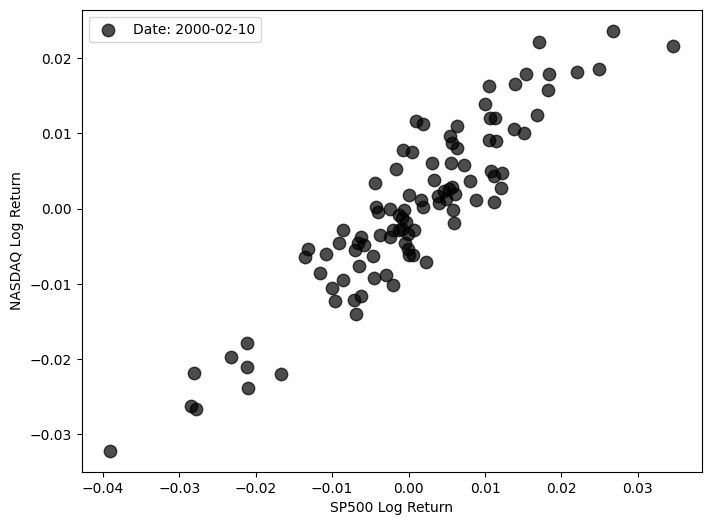

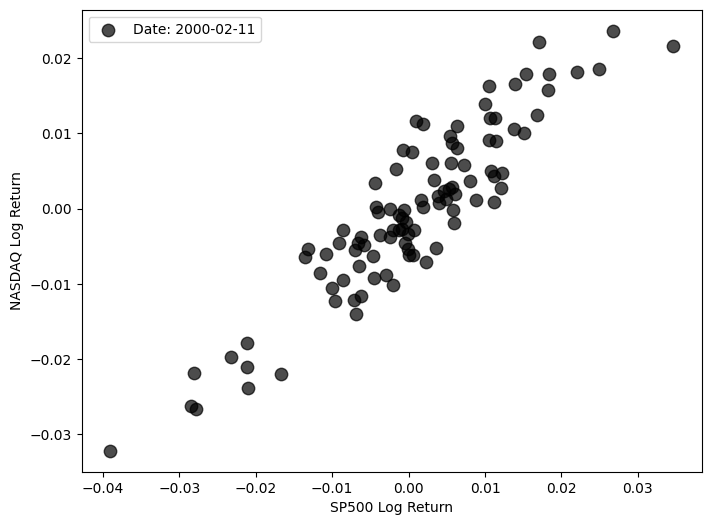

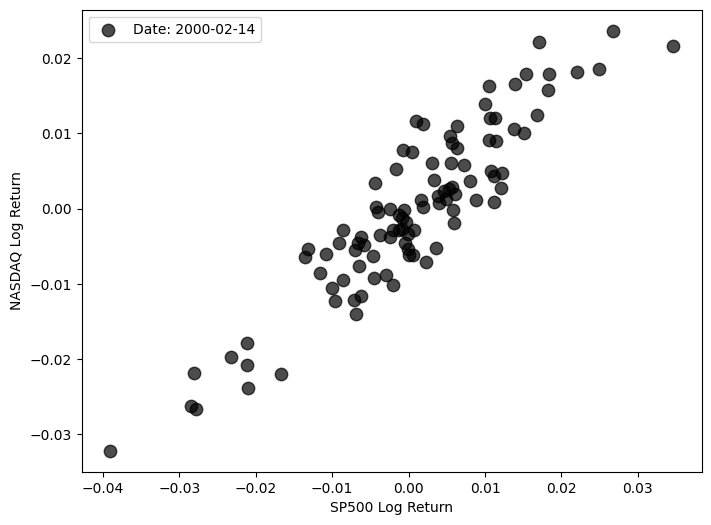

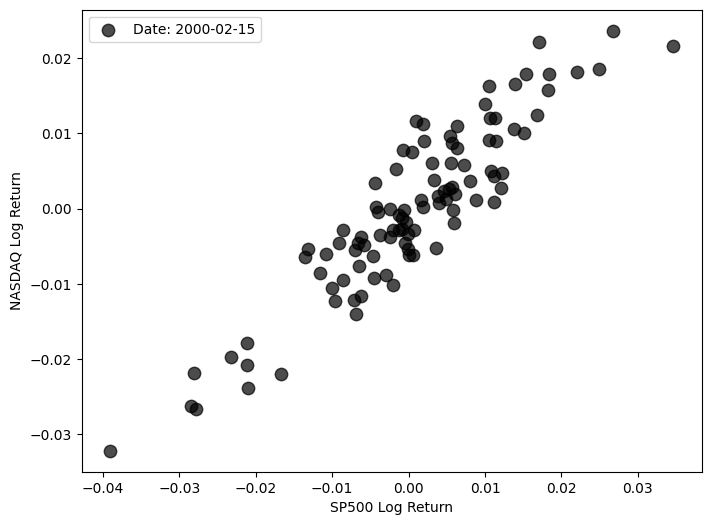

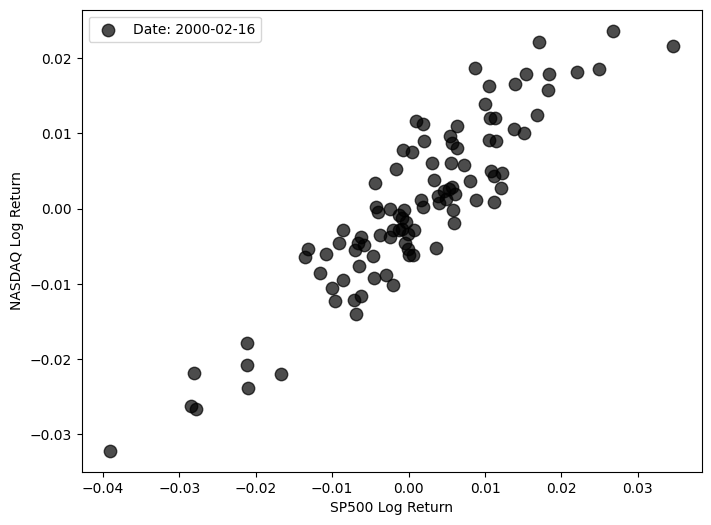

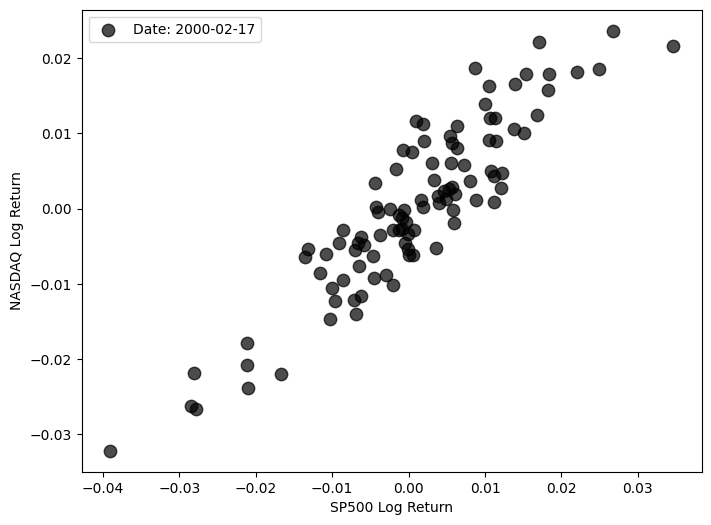

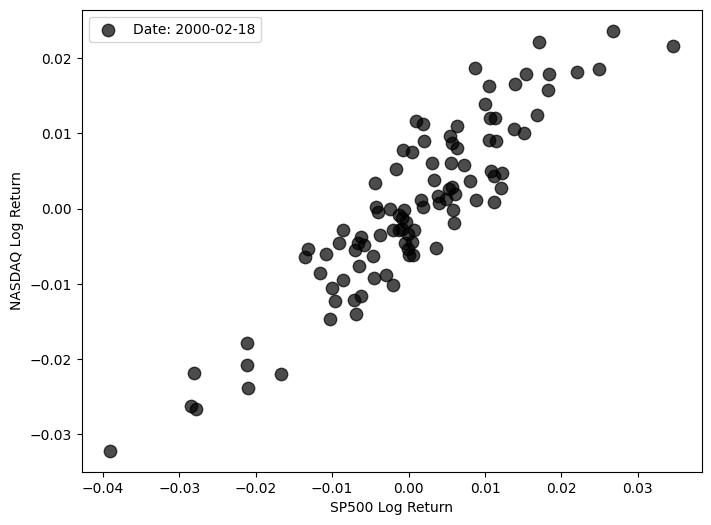

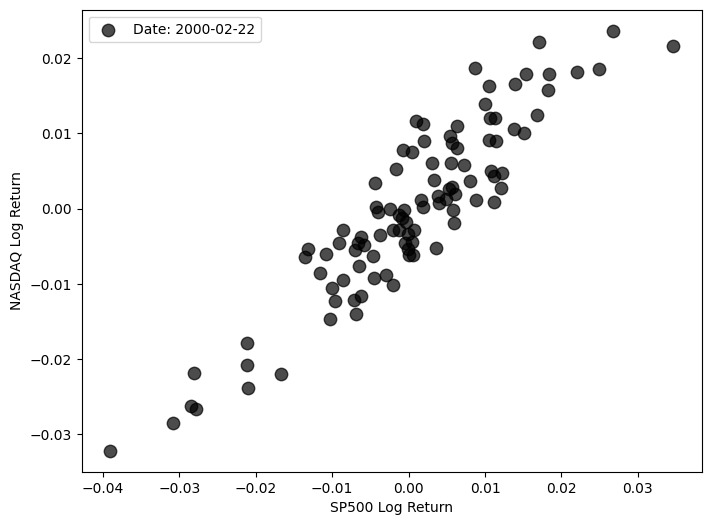

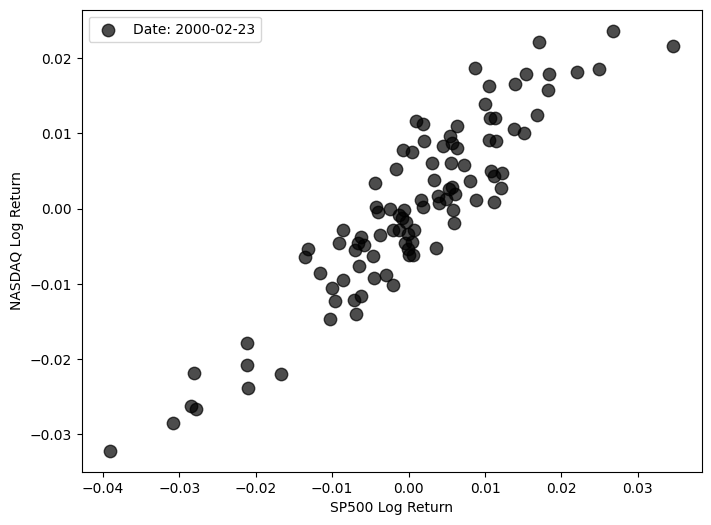

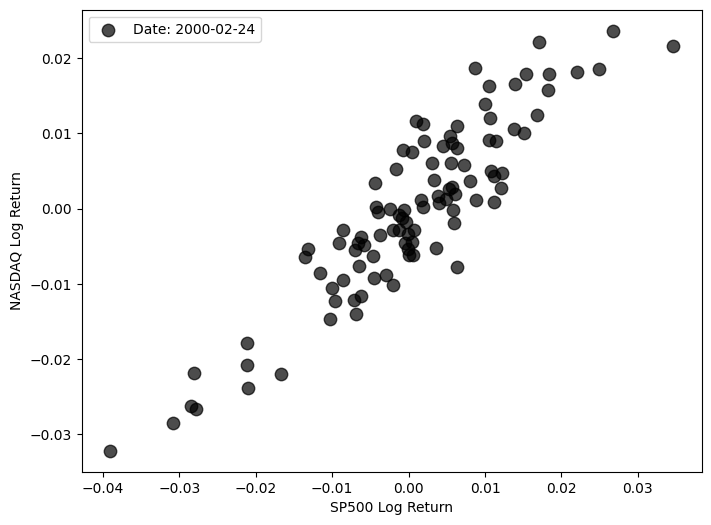

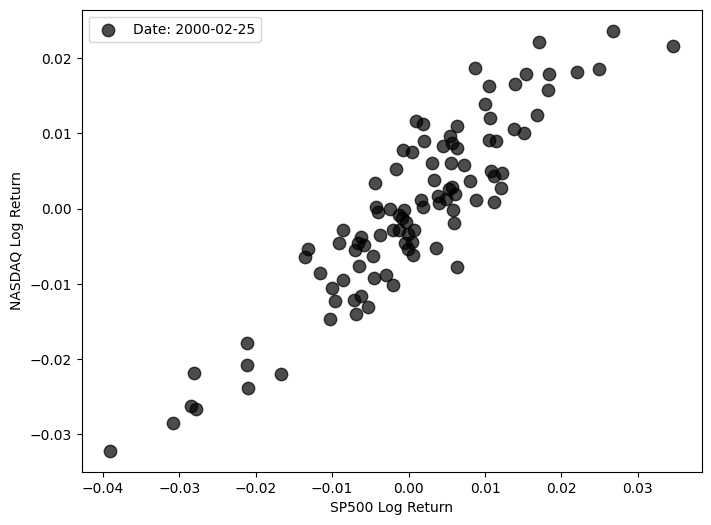

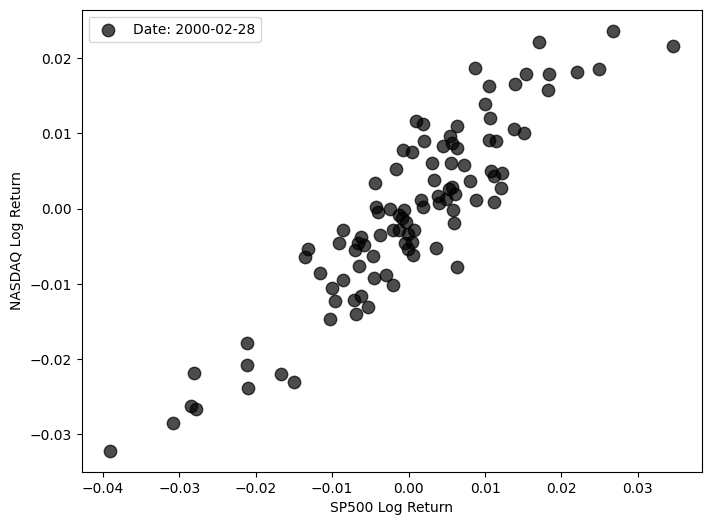

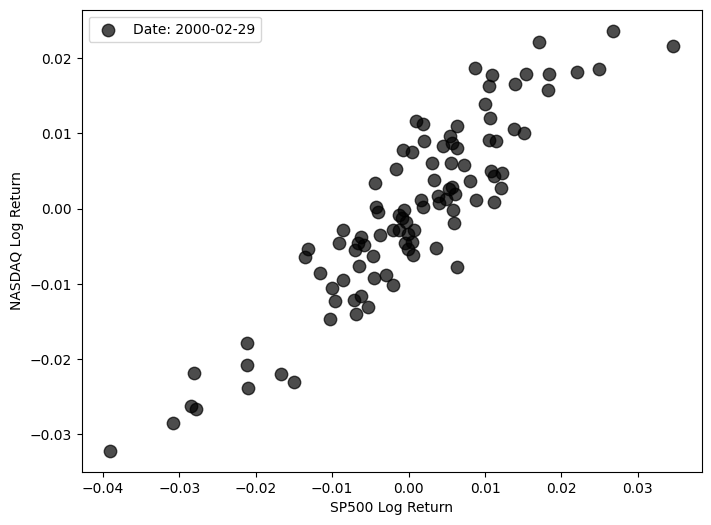

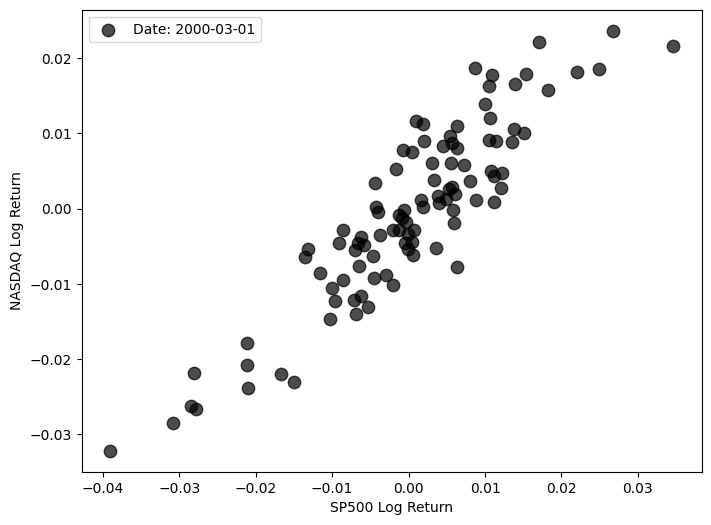

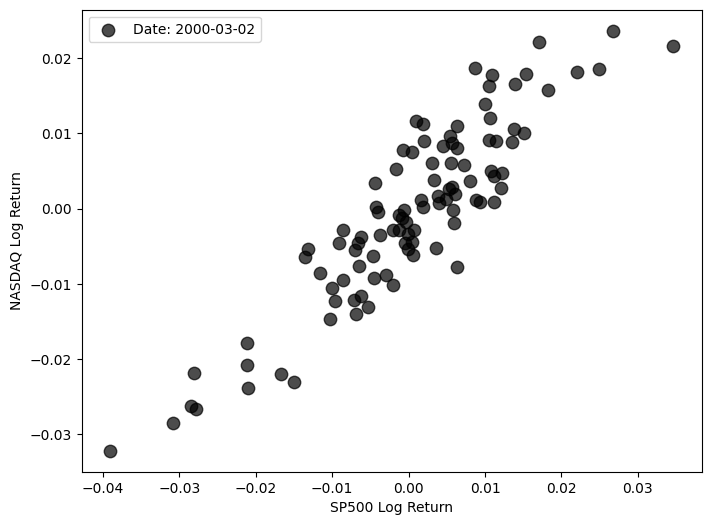

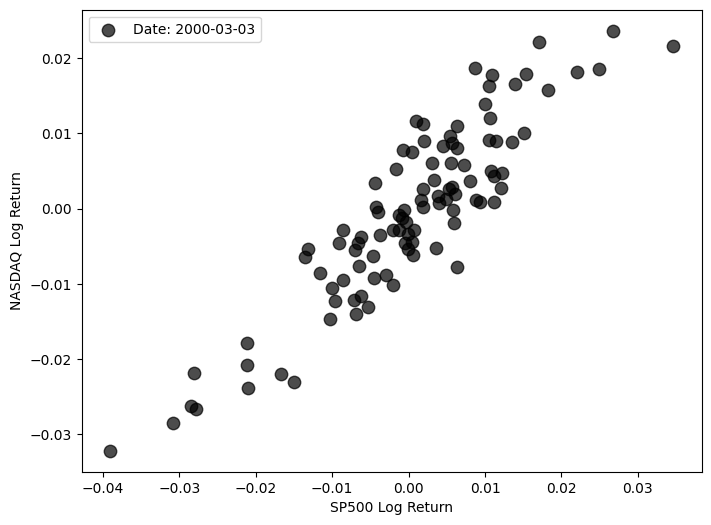

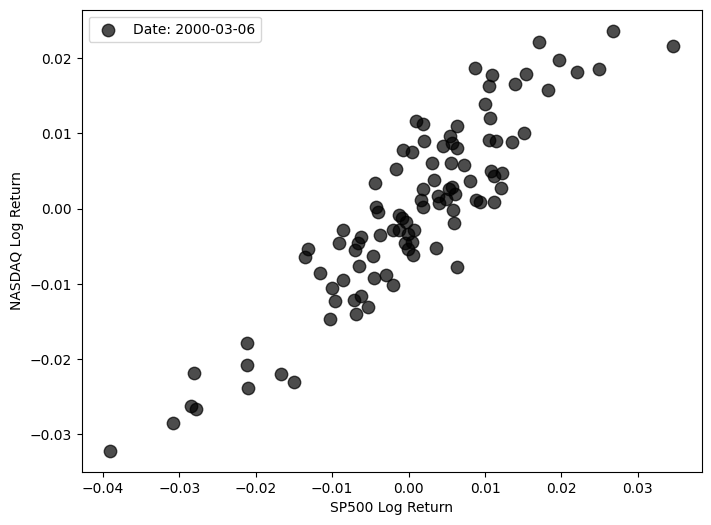

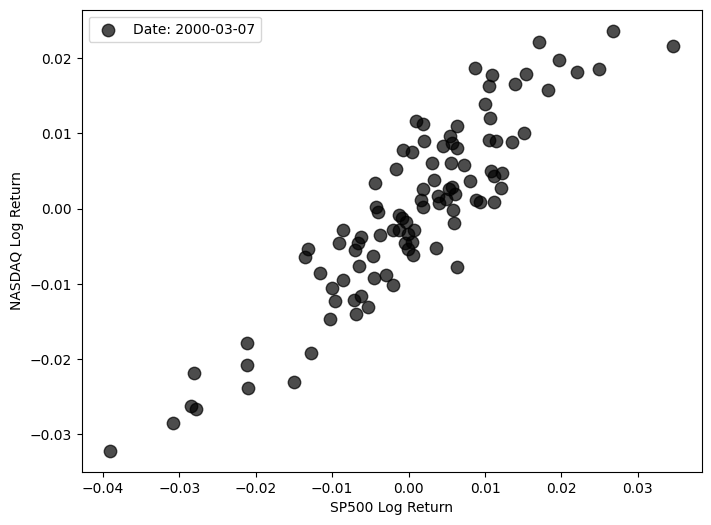

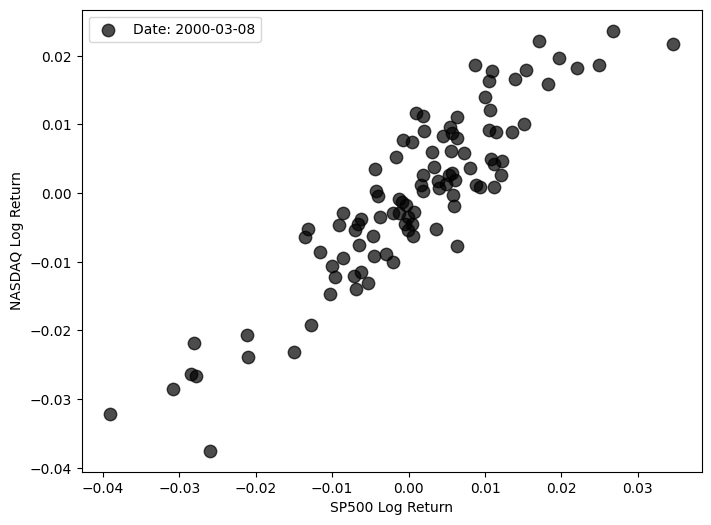

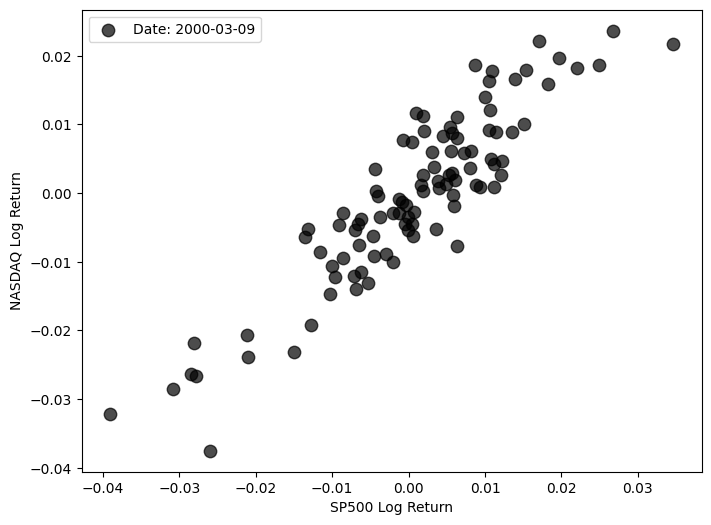

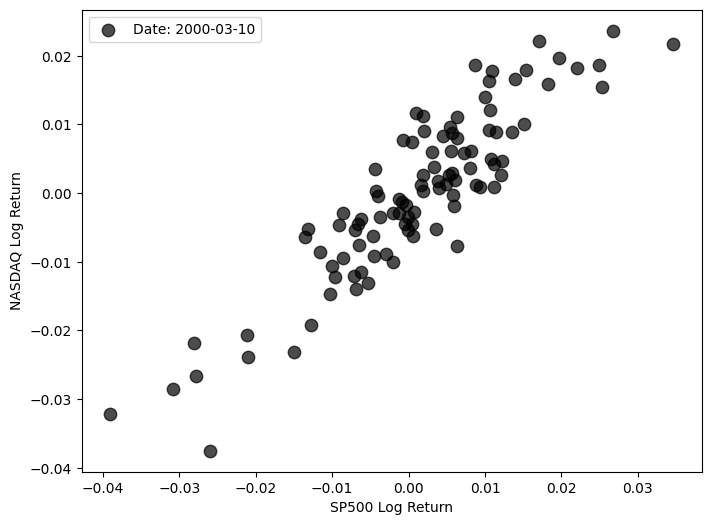

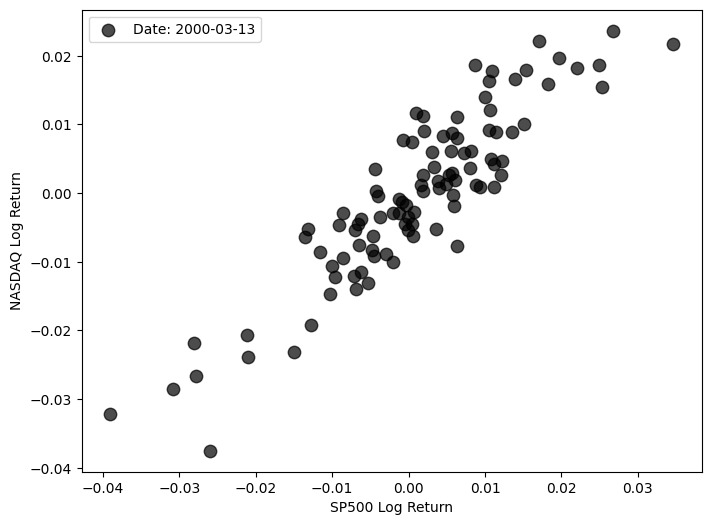

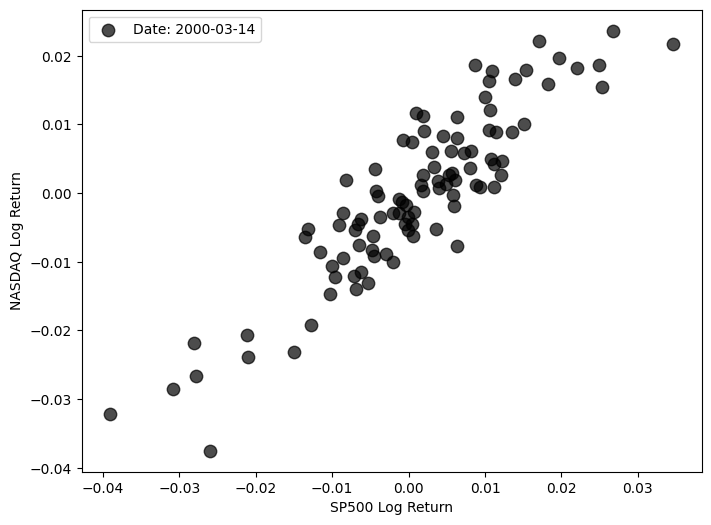

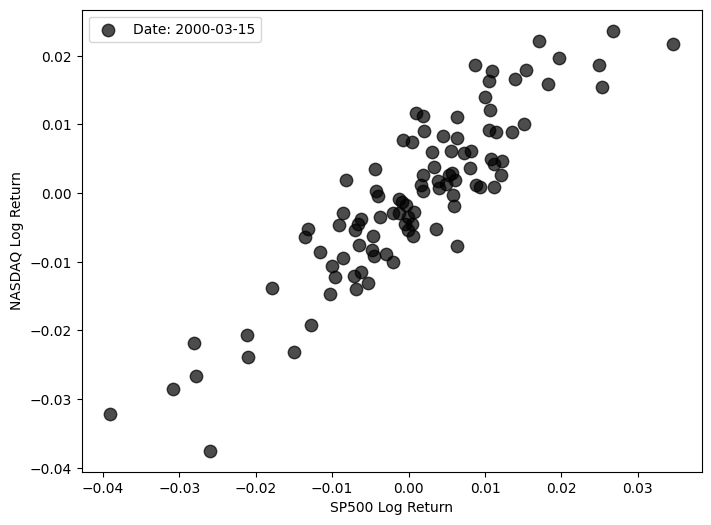

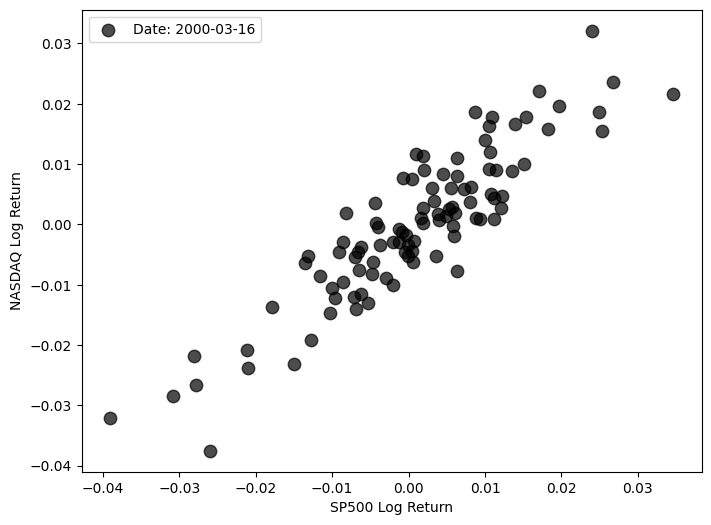

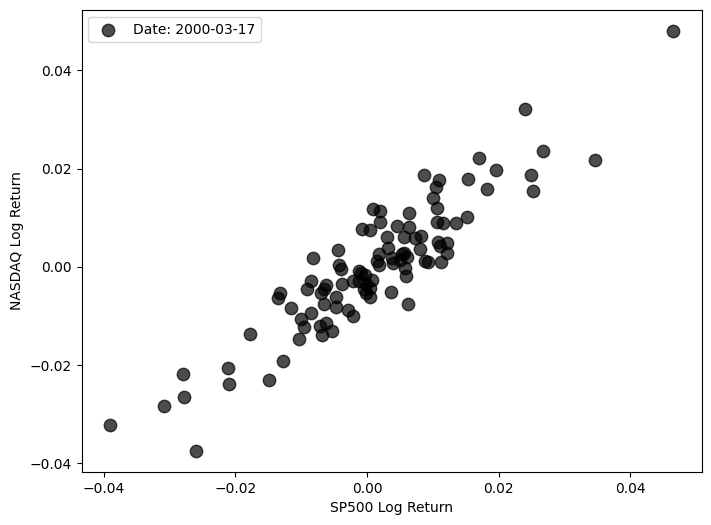

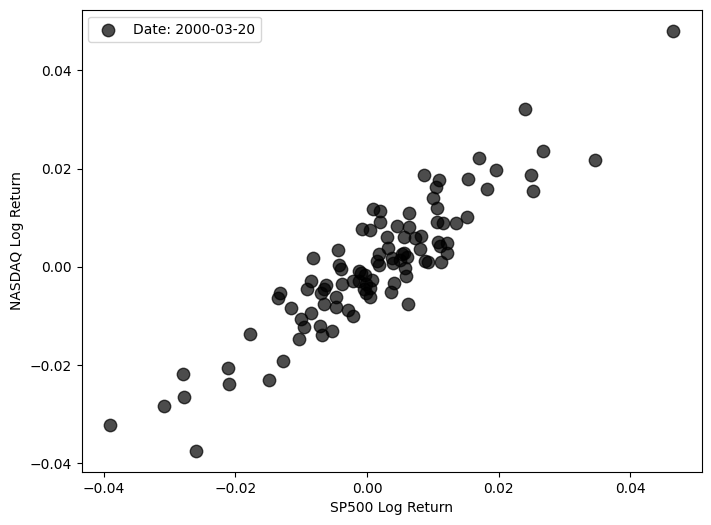

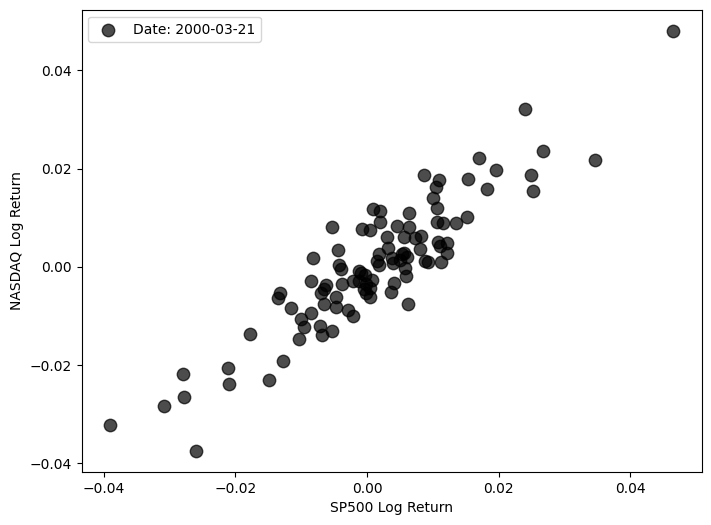

 42%|████▏     | 2994/7200 [00:08<01:03, 66.41it/s] 

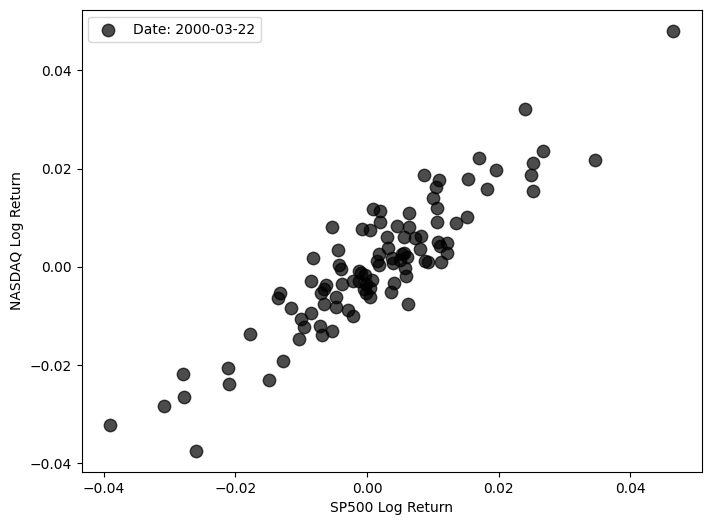

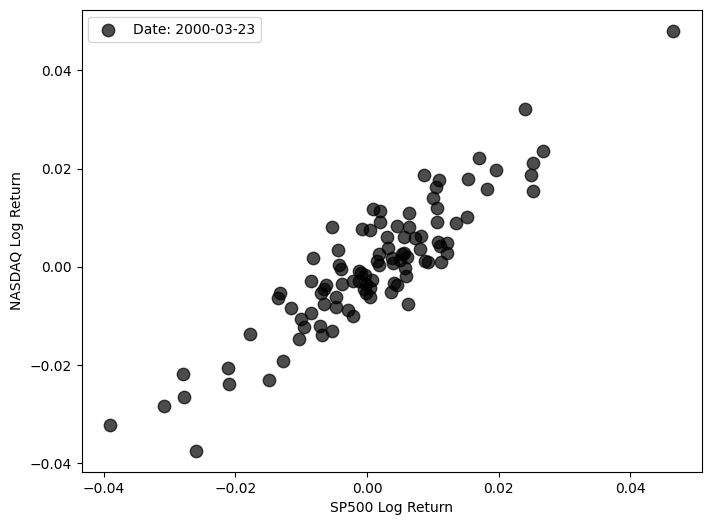

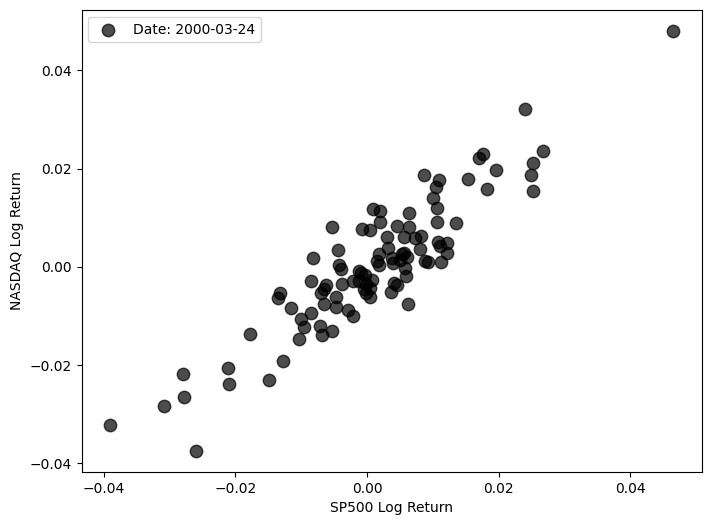

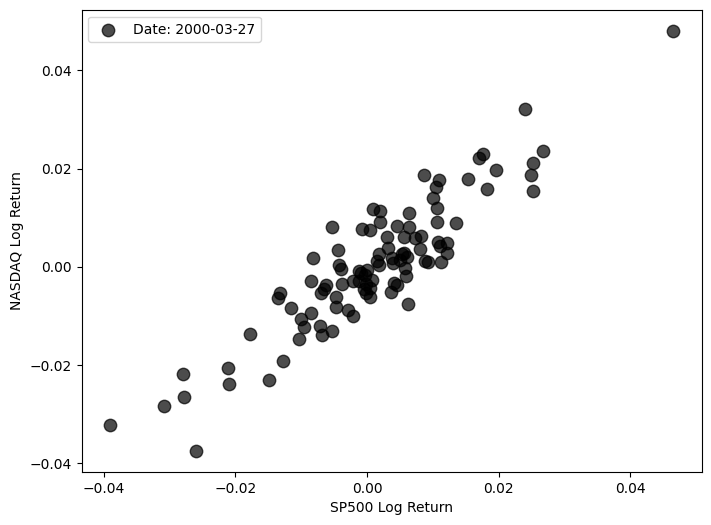

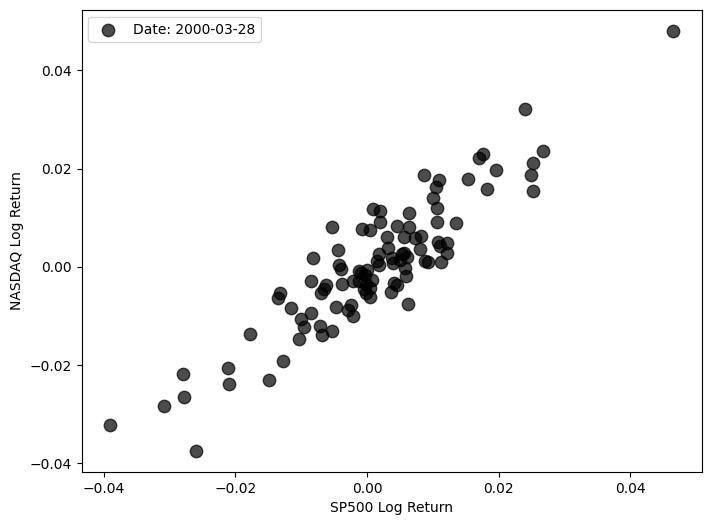

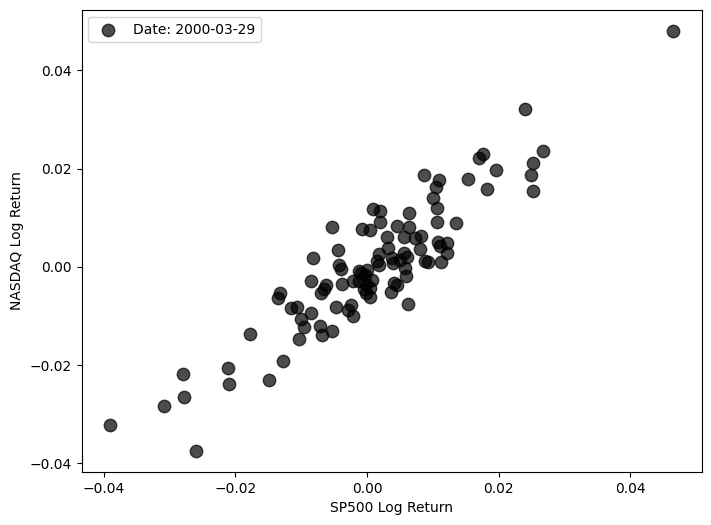

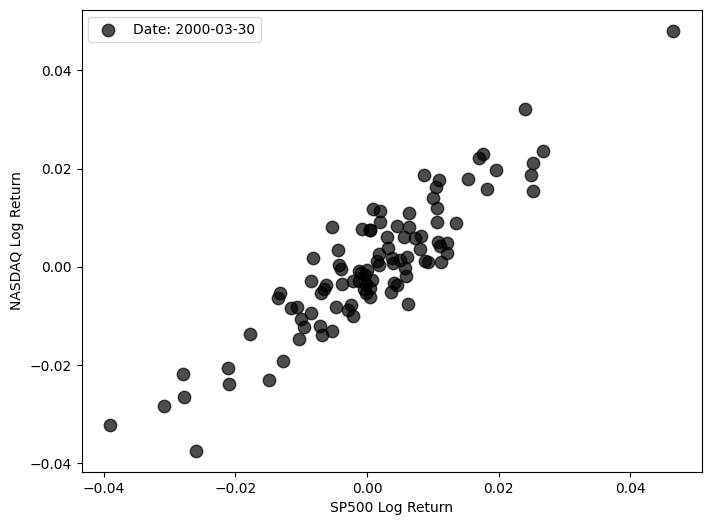

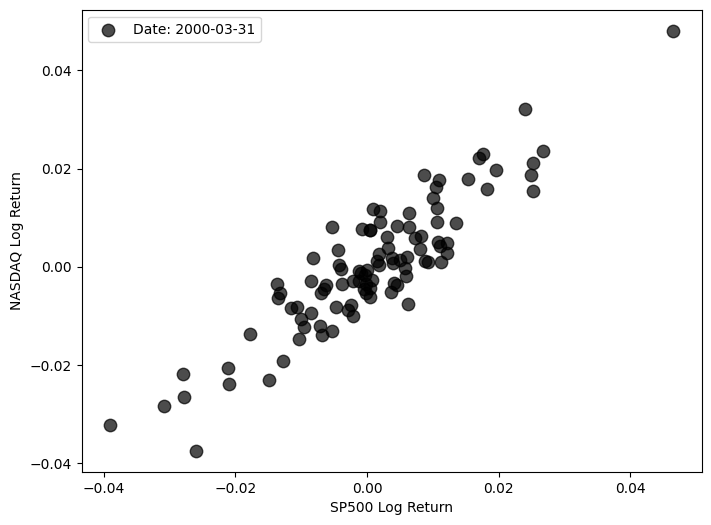

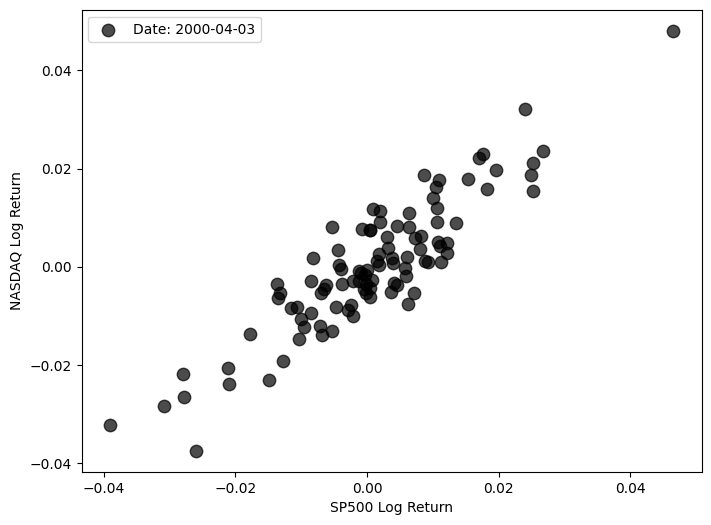

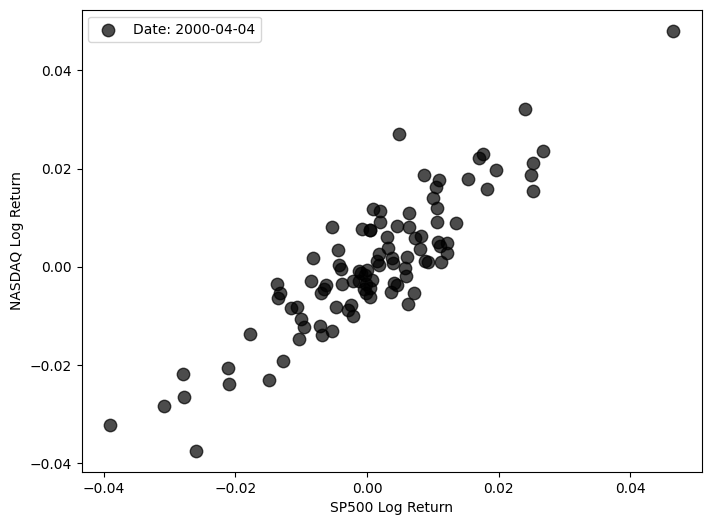

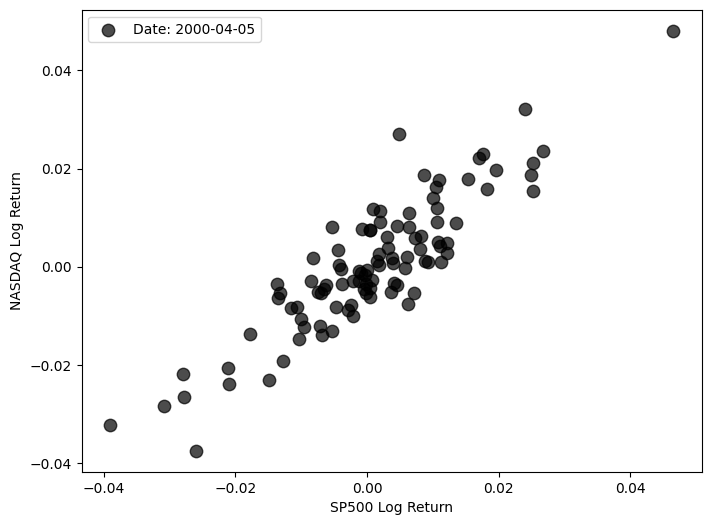

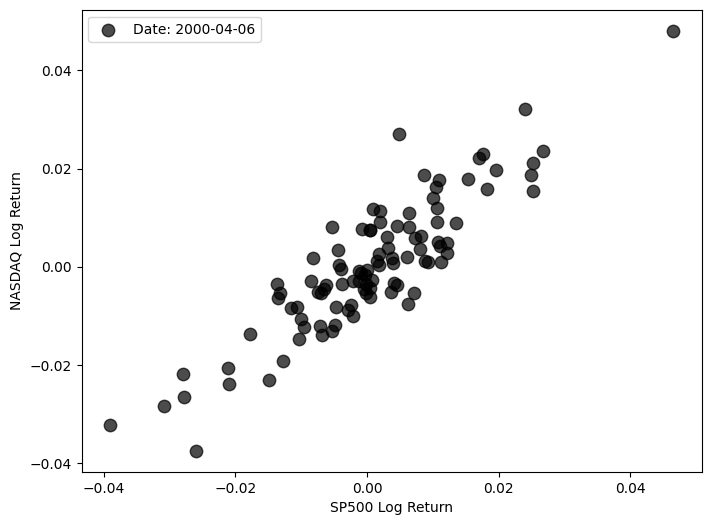

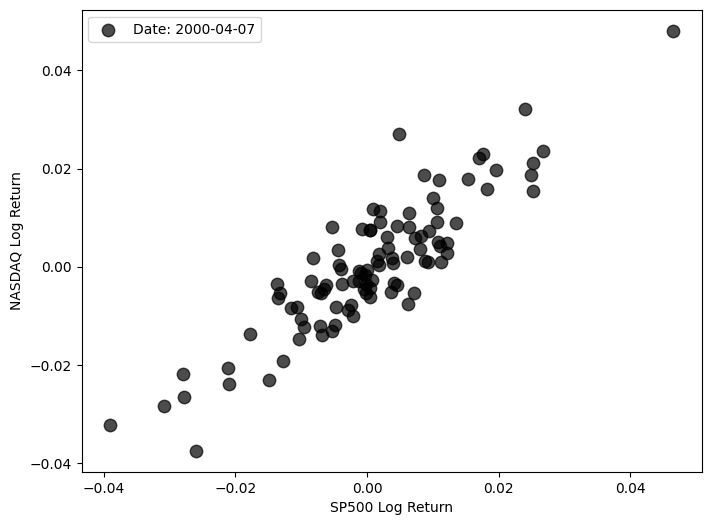

 71%|███████   | 5101/7200 [00:13<00:03, 540.96it/s]

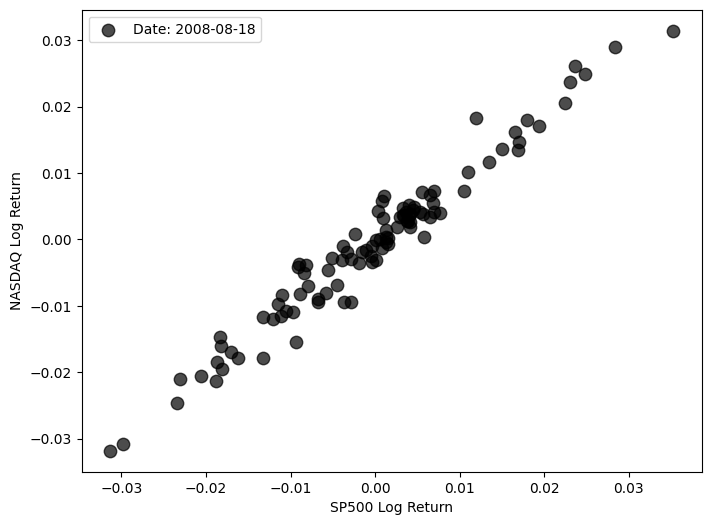

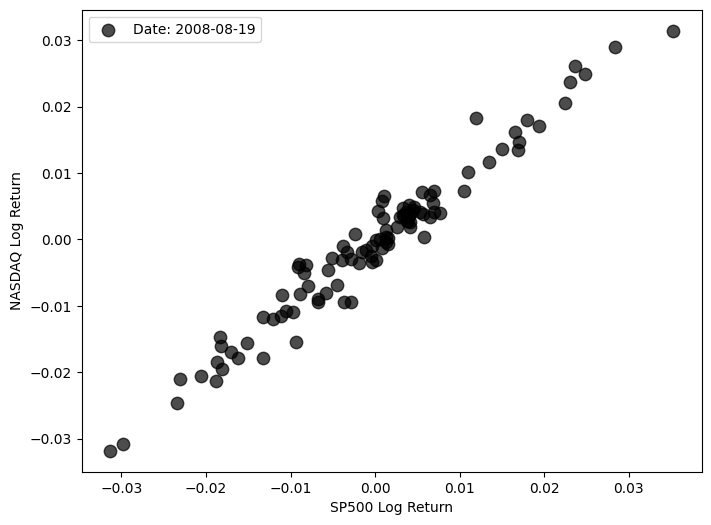

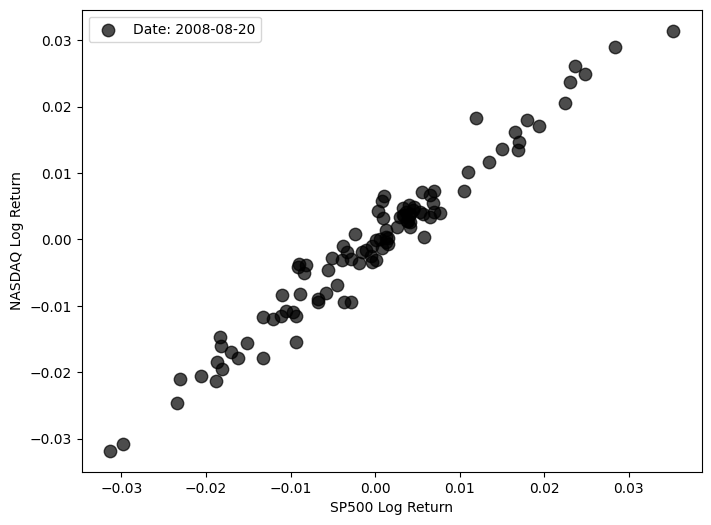

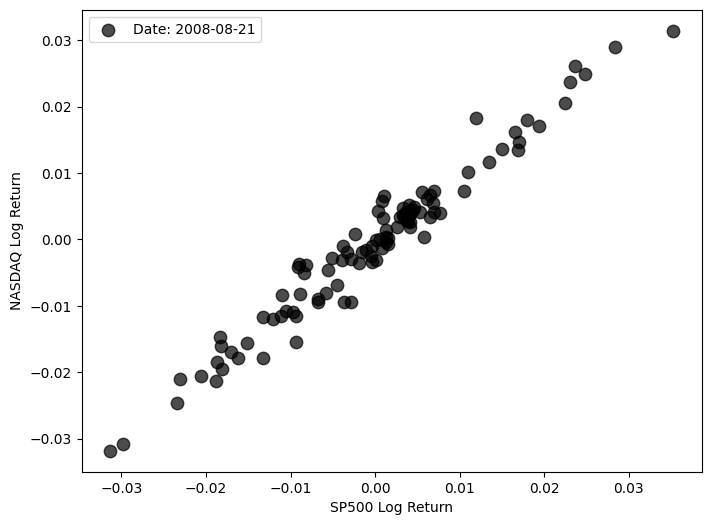

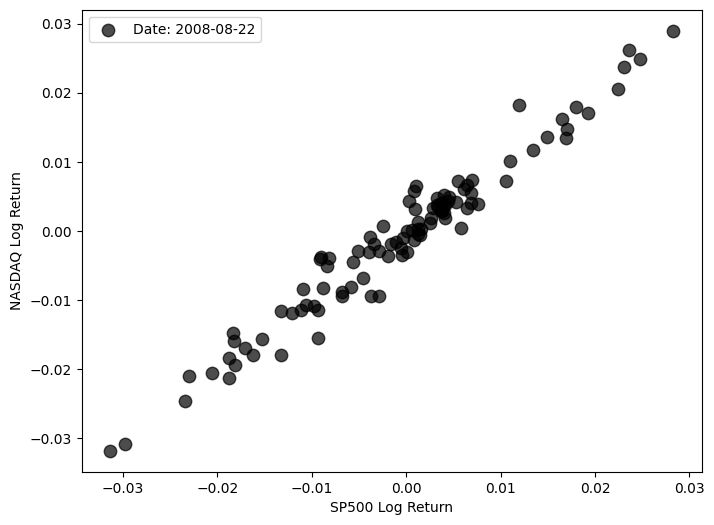

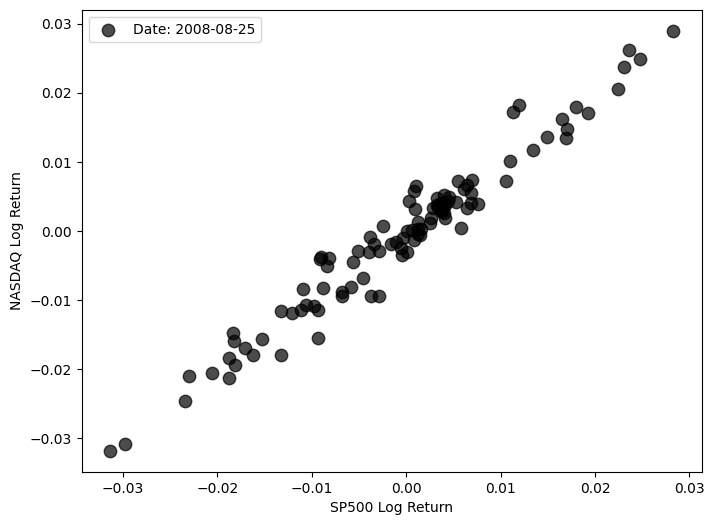

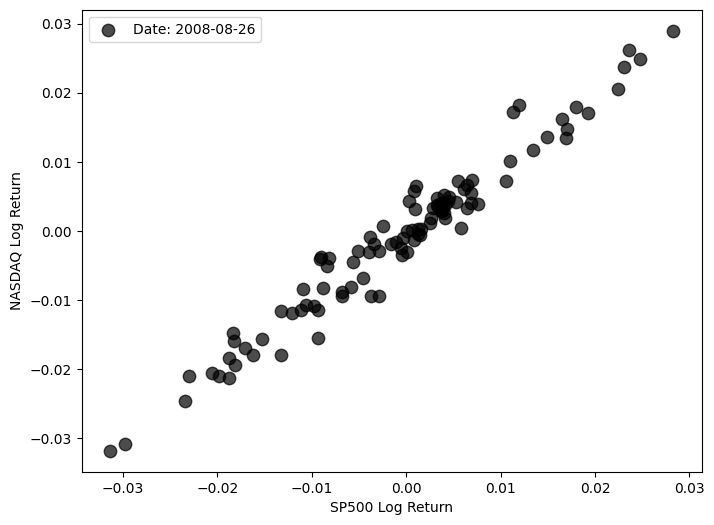

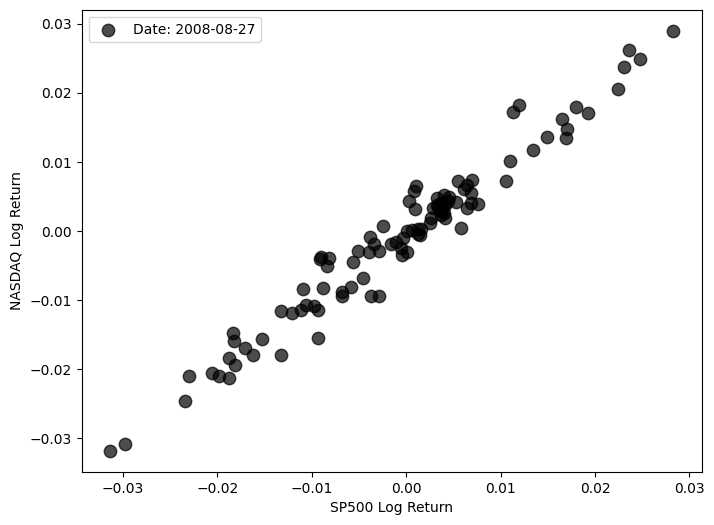

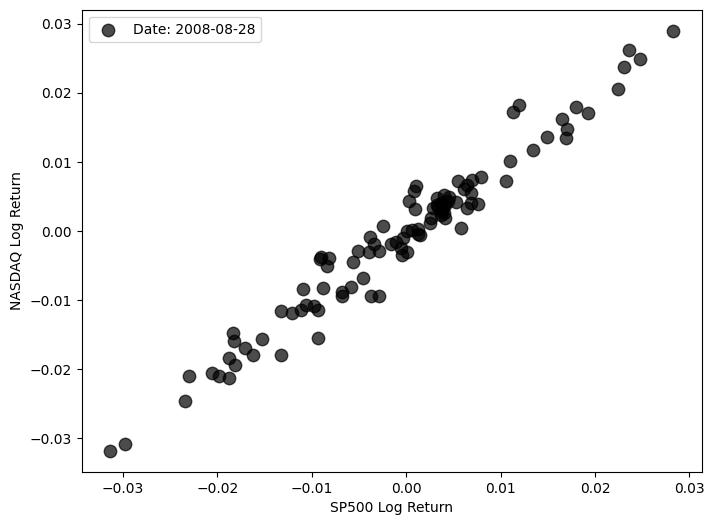

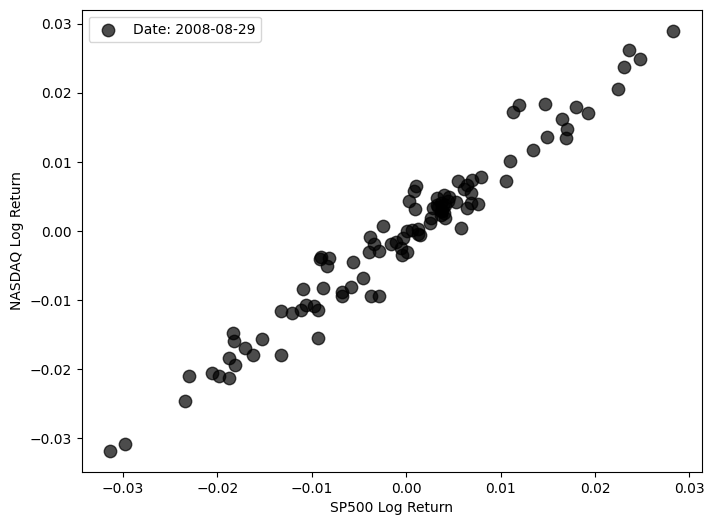

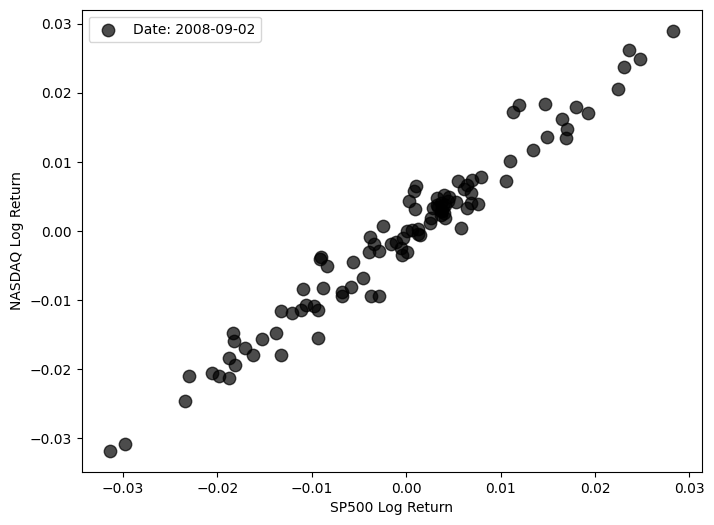

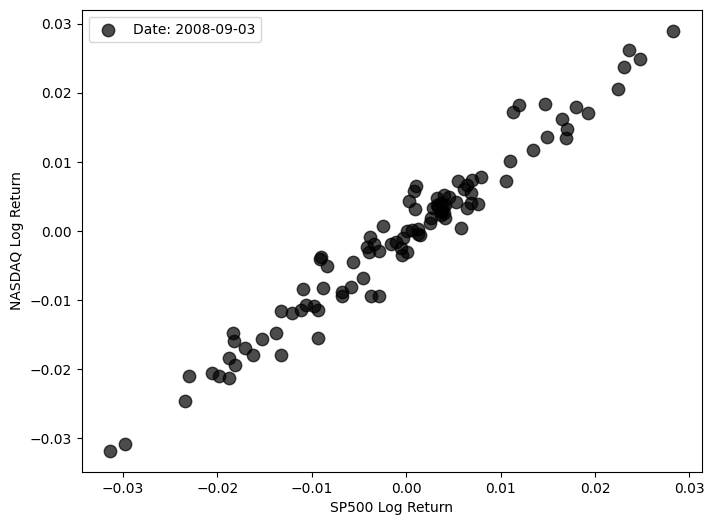

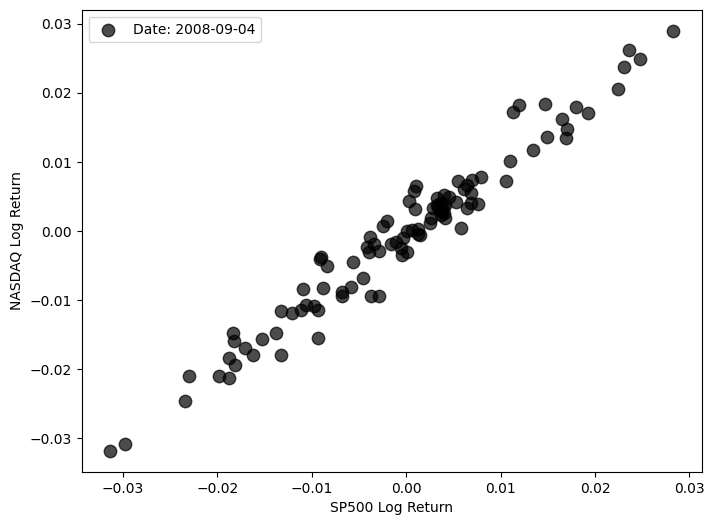

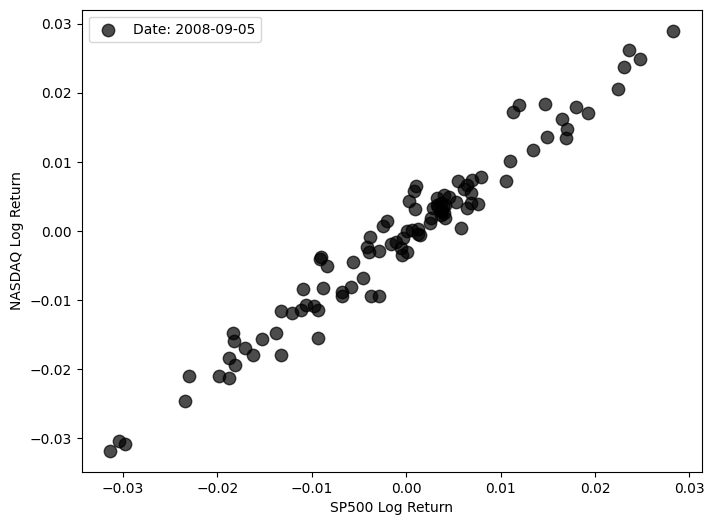

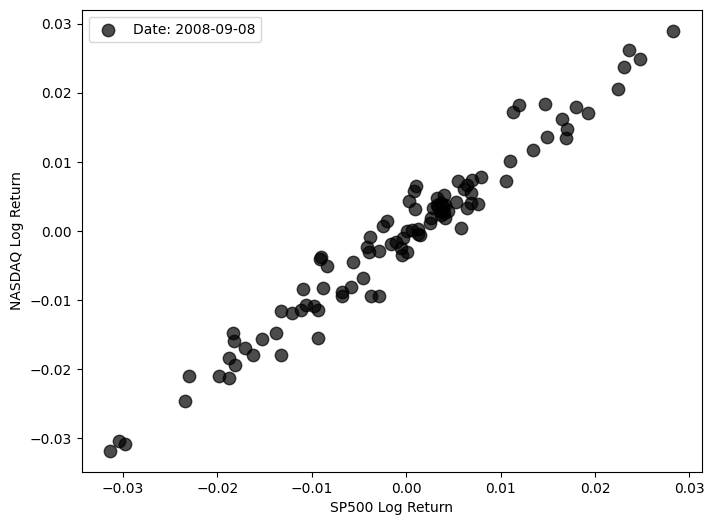

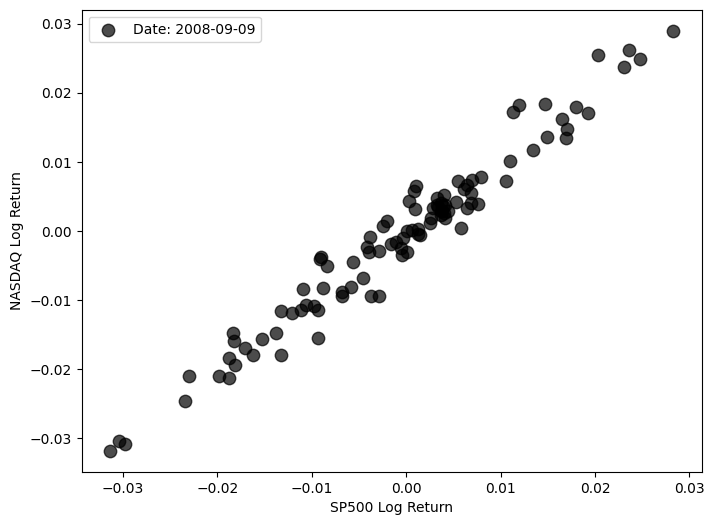

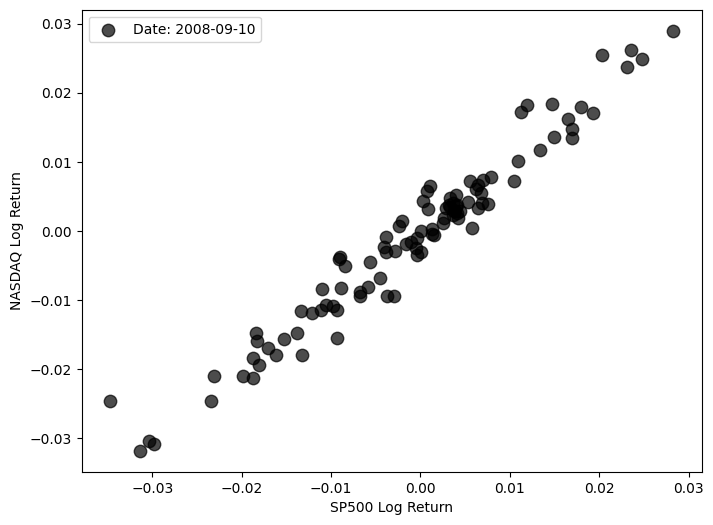

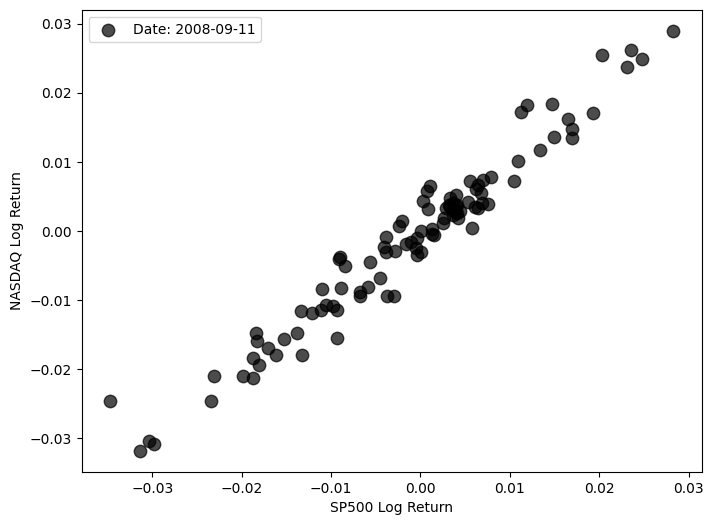

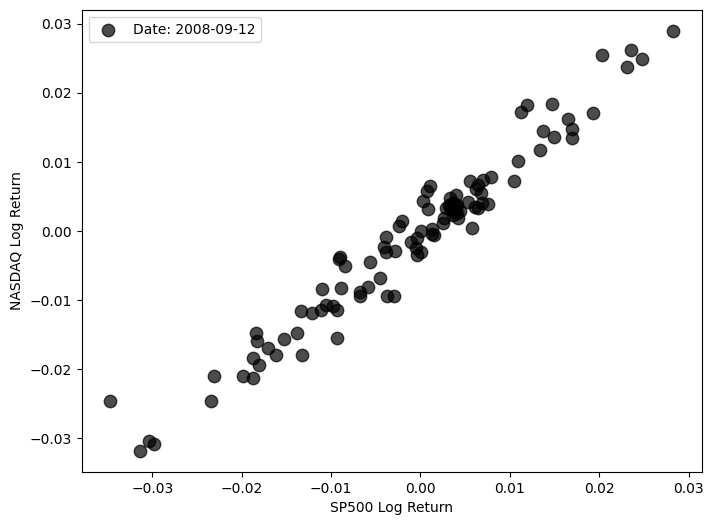

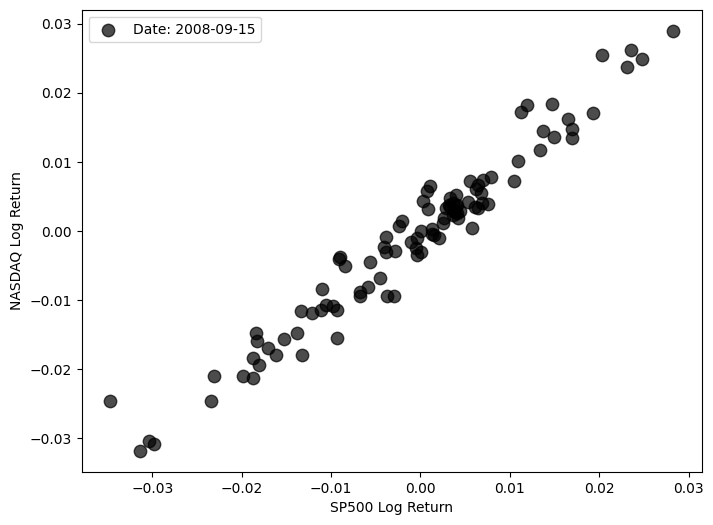

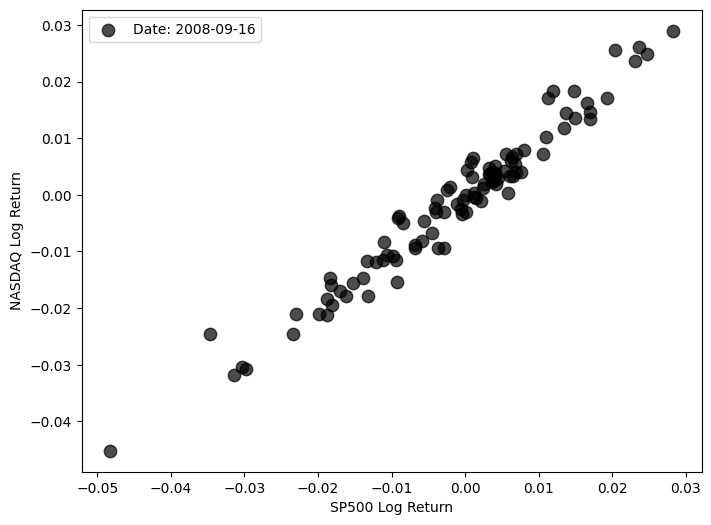

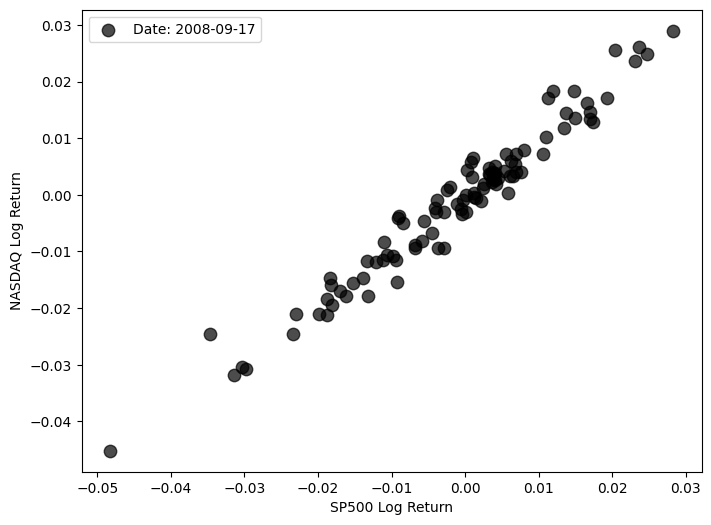

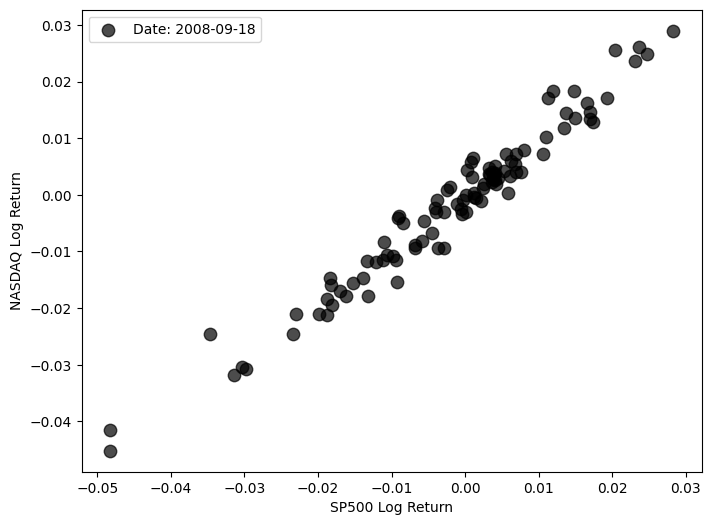

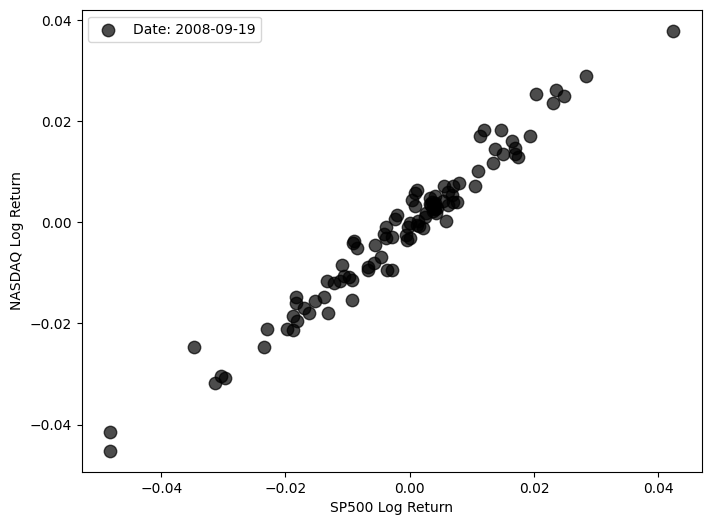

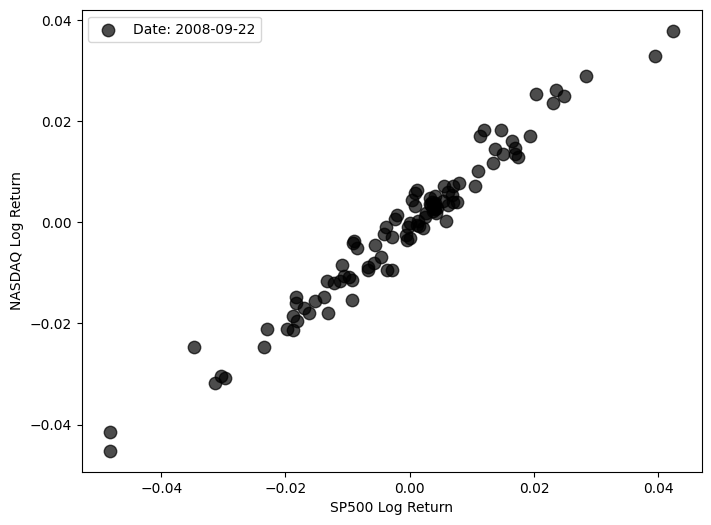

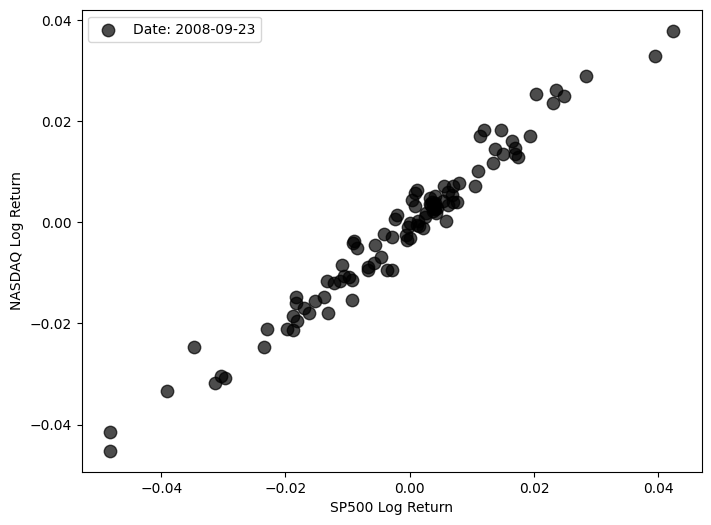

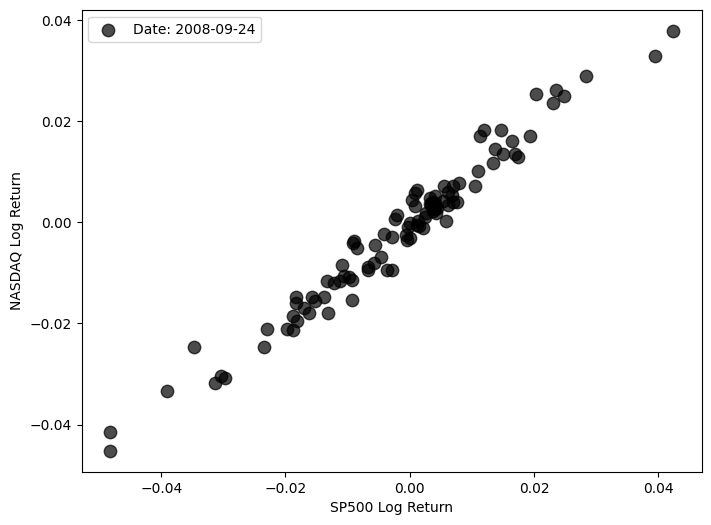

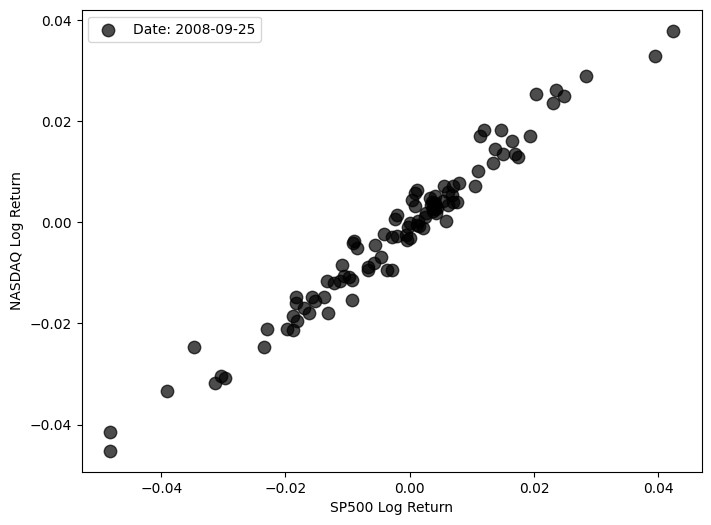

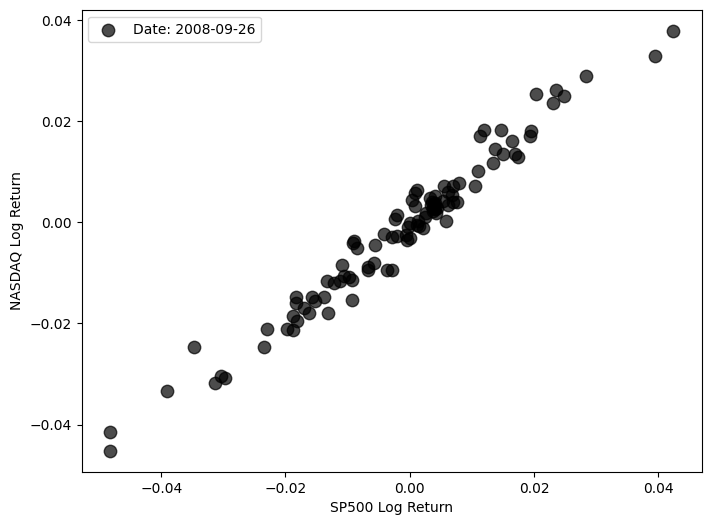

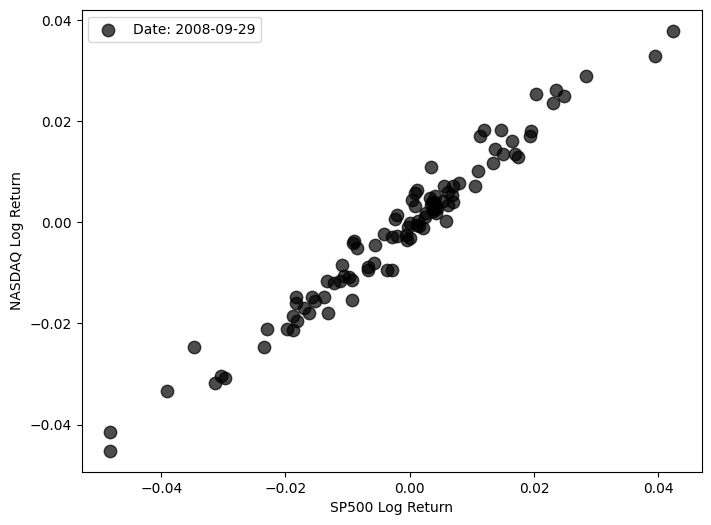

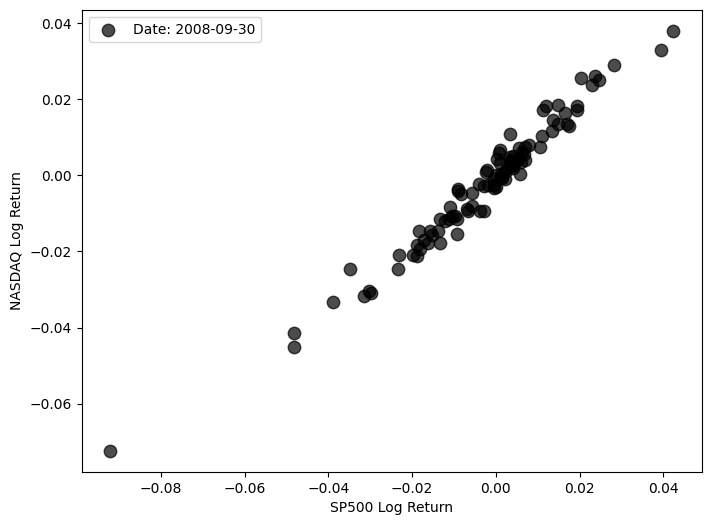

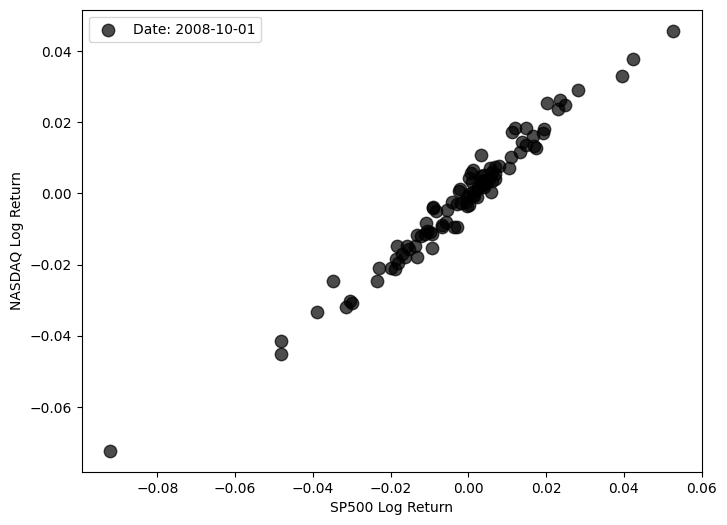

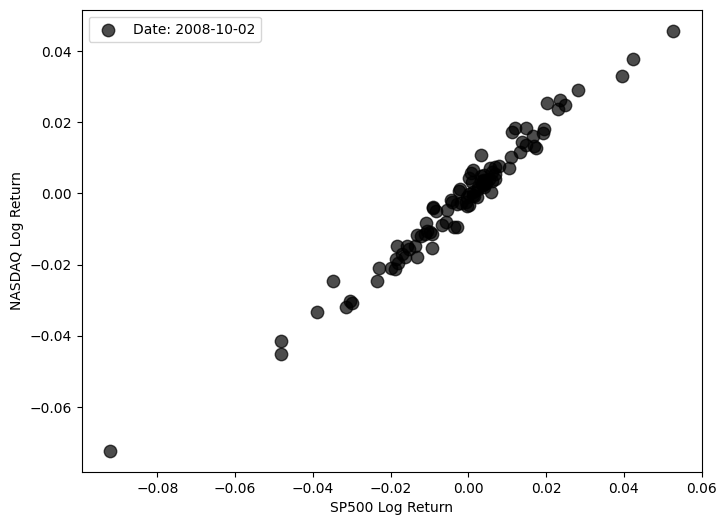

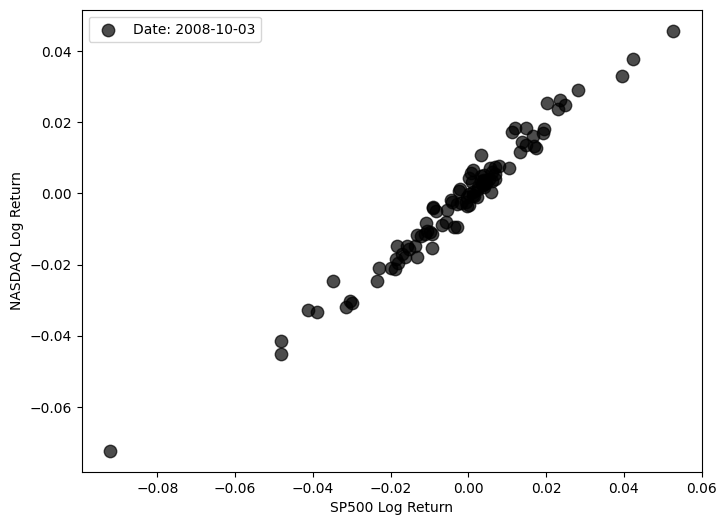

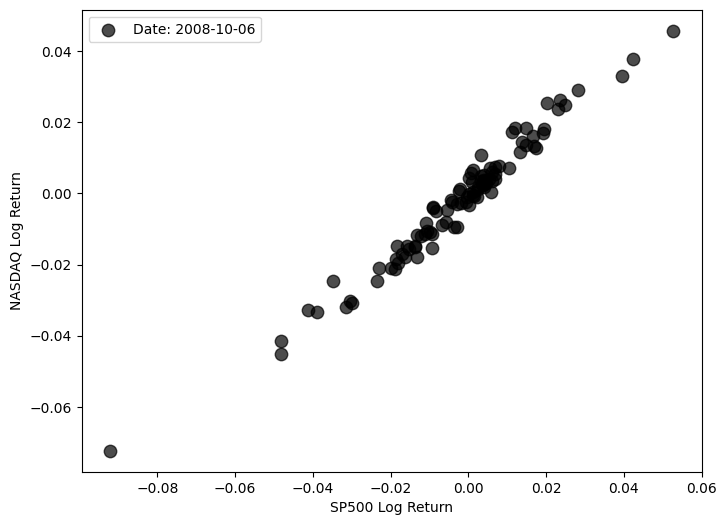

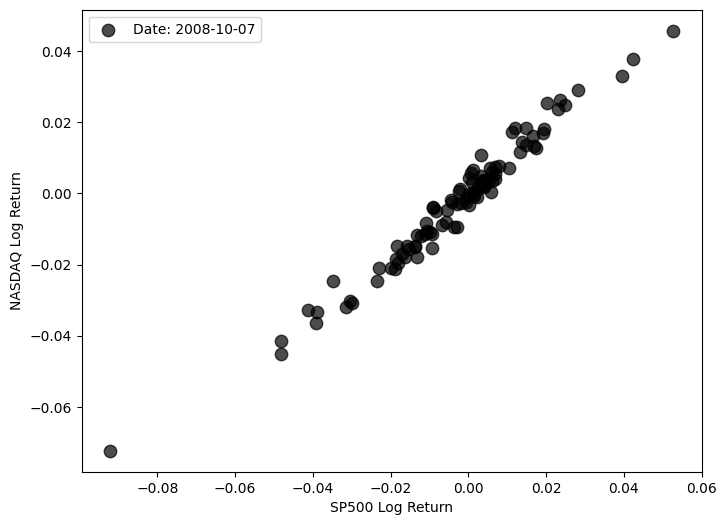

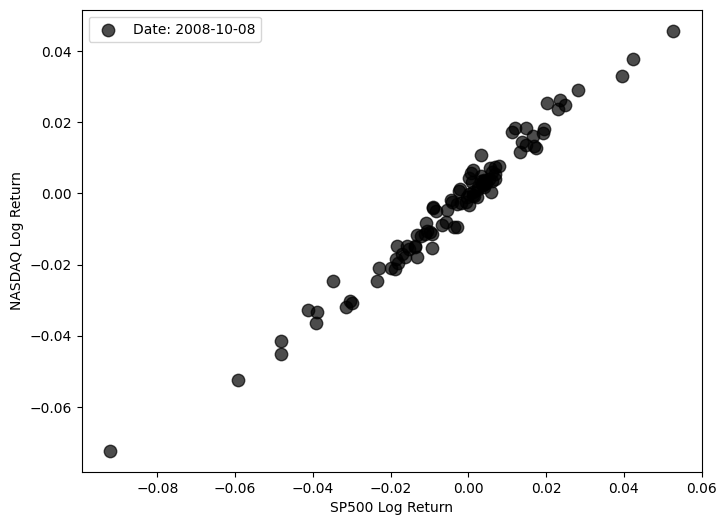

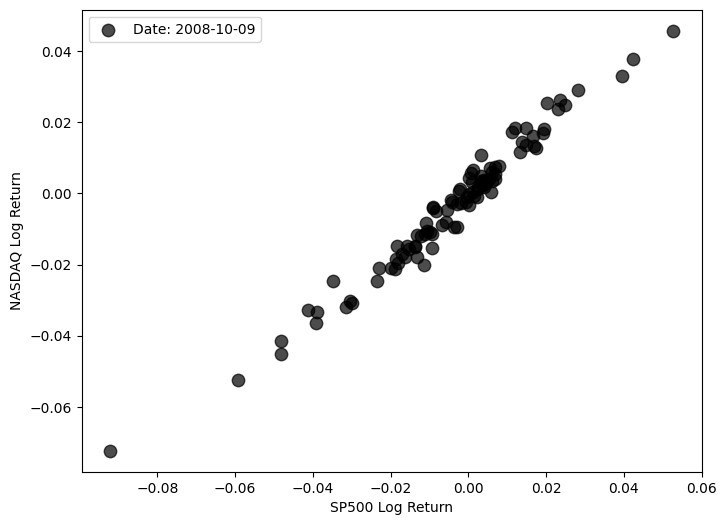

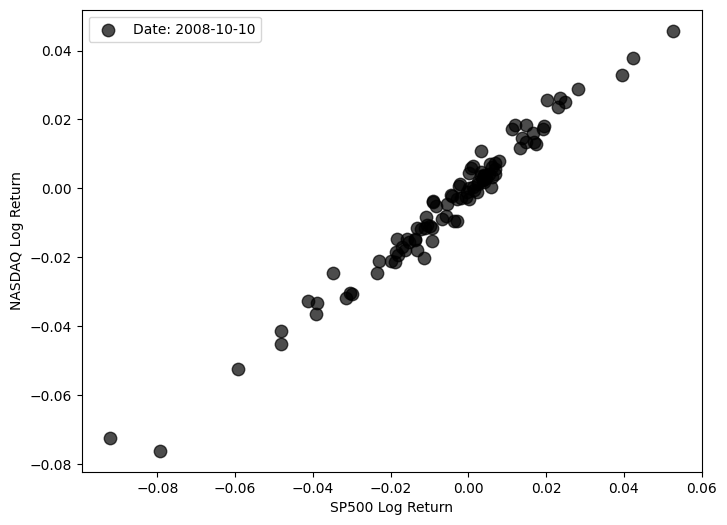

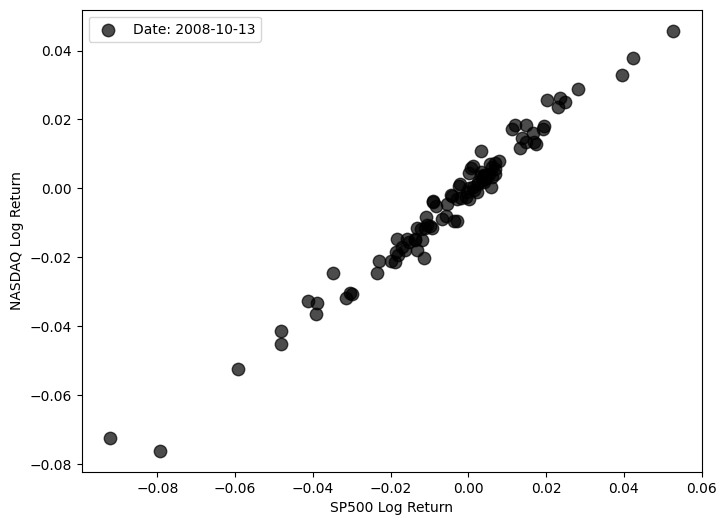

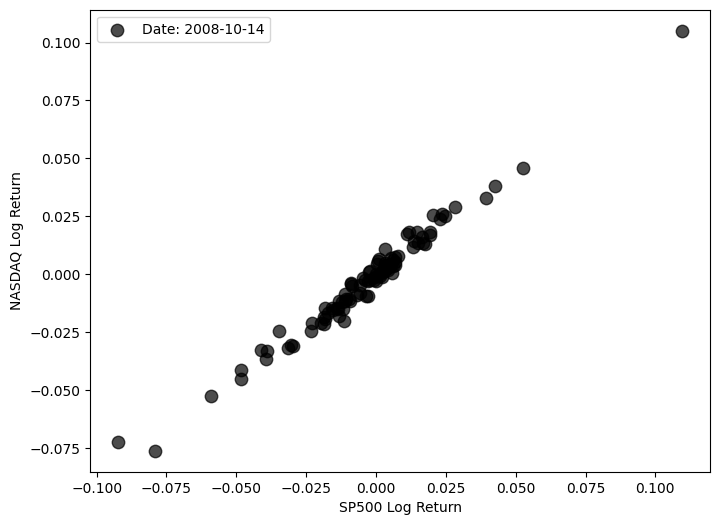

100%|██████████| 7200/7200 [00:20<00:00, 352.60it/s]


In [103]:
from tqdm import tqdm
import gudhi.representations as grepr

# plot around the dotcom bubble and 2008 financial crisis
dotcom_date = pd.Timestamp("2000-03-10")
financial_crisis_date = pd.Timestamp("2008-09-15")

w = 100 # window size
diagrams_returns = []
for i in tqdm(range(w, len(log_returns))):
    window = log_returns.iloc[i-w:i].values  # shape (w, 4)
    rips = ripser.ripser(window)
    diagrams_returns.append(rips['dgms'])

    if np.abs(log_returns.index[i] - dotcom_date) < pd.Timedelta(days=30) or np.abs(log_returns.index[i] - financial_crisis_date) < pd.Timedelta(days=30):
        # plot the point cloud of the current window
        plt.figure(figsize=(8, 6))
        plt.xlabel("SP500 Log Return")
        plt.ylabel("NASDAQ Log Return")
        date = log_returns.index[i]
        plt.scatter(window[:, 0], window[:, 1], c='black', s=80, alpha=0.7, label=f'Date: {date.date()}')
        plt.legend()
        plt.show()

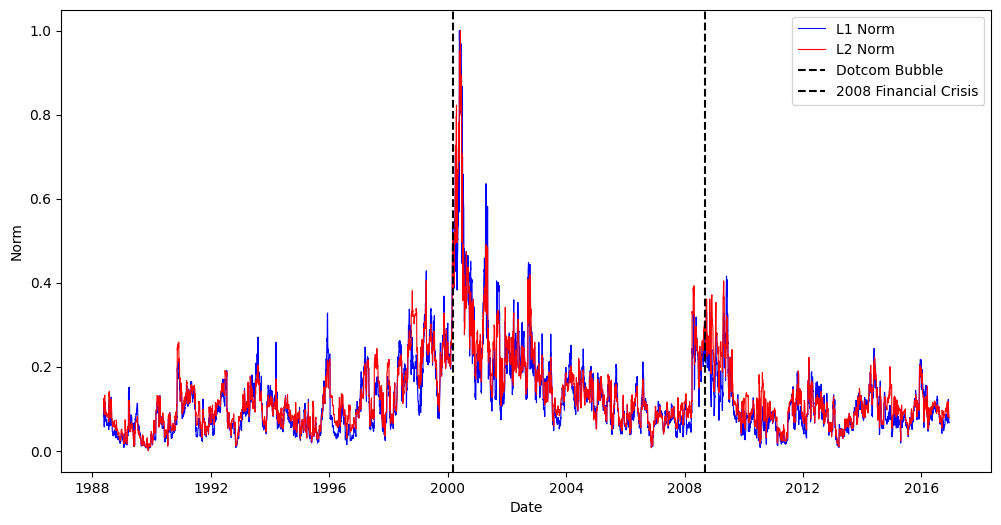

In [104]:
# on three subplots, one is normalized L1 and L2 norms of persistence landscapes over time, then VIX time series, finally Betti numbers over time
l1_norms_returns = []
l2_norms_returns = []
for diag in diagrams_returns:
    pl = grepr.Landscape(num_landscapes=10, resolution=500)
    landscape = pl.fit_transform([diag[1]])[0]
    l1_norms_returns.append(np.sum(np.abs(landscape)))
    l2_norms_returns.append(np.sqrt(np.sum(landscape**2)))

# normalize between 0 and 1
l1_norms_returns = (np.array(l1_norms_returns) - np.min(l1_norms_returns)) / (np.max(l1_norms_returns) - np.min(l1_norms_returns))
l2_norms_returns = (np.array(l2_norms_returns) - np.min(l2_norms_returns)) / (np.max(l2_norms_returns) - np.min(l2_norms_returns))

dates = log_returns.index

# on three subplots, one is both normalized L1 / L2 norms of persistence landscapes over time, other is VIX time series, finally Betti numbers over time
# add vertical lines corresponding to dotcom bubble (Mar 10, 2000) and 2008 financial crisis (Sep 15, 2008)
plt.figure(figsize=(12, 6))
plt.plot(dates[w:], l1_norms_returns, label='L1 Norm', color='blue', linewidth=0.8)
plt.plot(dates[w:], l2_norms_returns, label='L2 Norm', color='red', linewidth=0.8)
plt.axvline(pd.Timestamp("2000-03-10"), color='black', linestyle='--',  label='Dotcom Bubble')
plt.axvline(pd.Timestamp("2008-09-15"), color='black', linestyle='--',  label='2008 Financial Crisis')
plt.xlabel("Date")
plt.ylabel("Norm")
plt.legend()
plt.show()

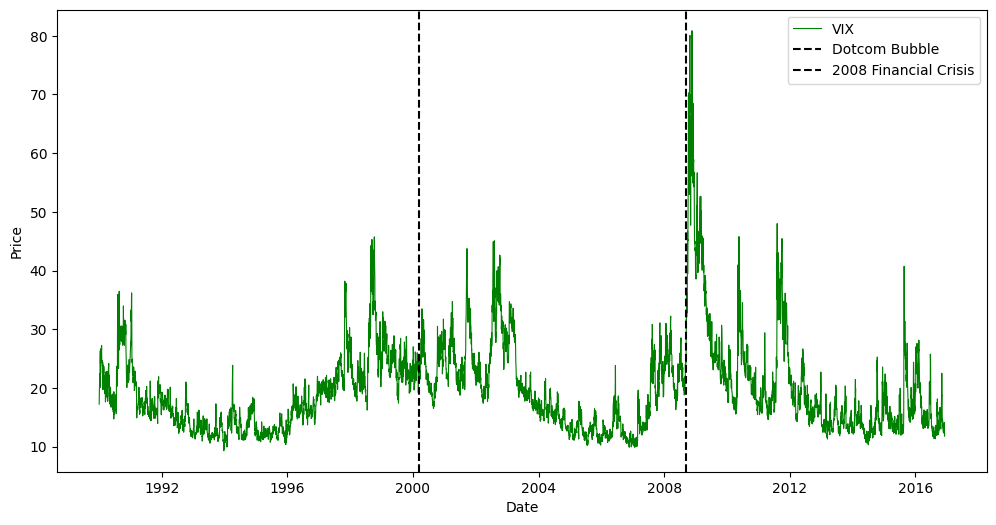

In [85]:
plt.figure(figsize=(12, 6))
plt.plot(dates[w:], data.loc[dates[w:], '^VIX'], label='VIX', color='green', linewidth=0.8)
plt.axvline(pd.Timestamp("2000-03-10"), color='black', linestyle='--',  label='Dotcom Bubble')
plt.axvline(pd.Timestamp("2008-09-15"), color='black', linestyle='--',  label='2008 Financial Crisis')
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [46]:
# use the library ruptures to detect change points in the L2 norm time series.
import ruptures as rpt

l2_signal = l2_norms_returns.reshape(-1, 1)
model = "l2"
algo = rpt.Pelt(model=model).fit(l2_signal)
result = algo.predict(pen=2)

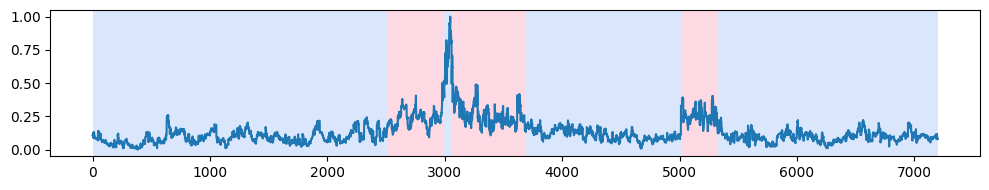

In [48]:
# plot the change points on the L2 norm time series
rpt.display(l2_signal, result)
plt.show()

In [49]:
# employ the 500 days rolling window with the sliding step of one day to calculate the variance, the average spectral density at low frequencies and the firstlag of the auto-correlation function (ACF) of the L2 norm for 250 trading days prior to the date of a market crash

import statsmodels.api as sm
from scipy.signal import welch

window_size = 500
variances = []
avg_spectral_densities = []
firstlags = []

for i in tqdm(range(window_size, len(l2_norms_returns))):
    window = pd.Series(l2_norms_returns[i-window_size:i])
    
    # Variance
    variance = window.var()
    variances.append(variance)
    
    # Average spectral density at low frequencies
    f, Pxx = welch(window.values, fs=1.0)
    low_freq_indices = f < 0.1
    avg_spectral_density = Pxx[low_freq_indices].mean()
    avg_spectral_densities.append(avg_spectral_density)

    # First lag of the Auto-Correlation Function (ACF)
    acf_values = sm.tsa.acf(window.values, nlags=1, fft=True)
    firstlag = acf_values[1].mean()
    firstlags.append(firstlag)

100%|██████████| 6700/6700 [00:01<00:00, 5101.98it/s]


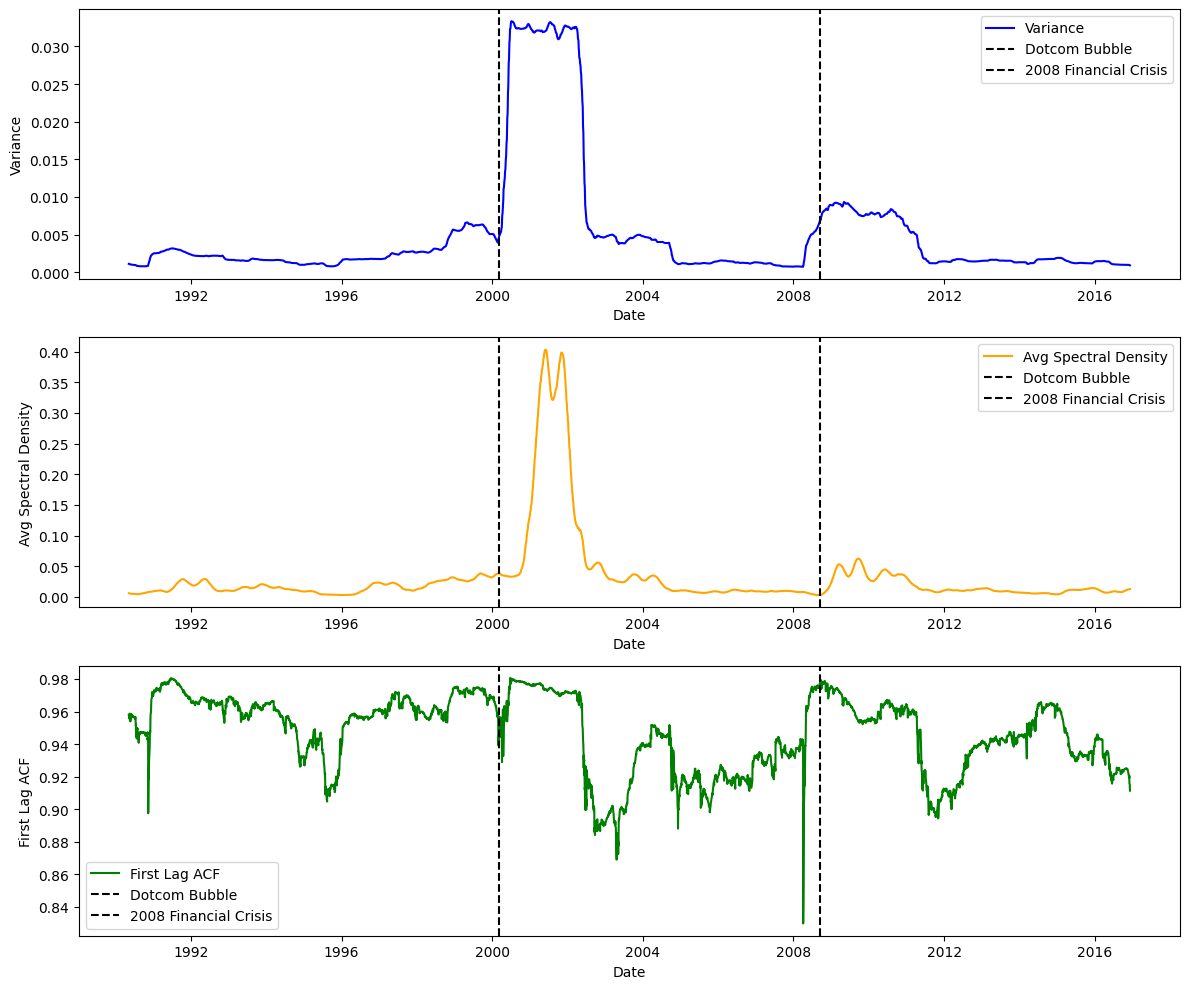

In [87]:
# plot variance, average spectral density, and firstlag over time

plt.figure(figsize=(12, 10))
plt.subplot(3, 1, 1)
plt.plot(dates[window_size+100:], variances, label='Variance', color='blue')
plt.axvline(pd.Timestamp("2000-03-10"), color='black', linestyle='--',  label='Dotcom Bubble')
plt.axvline(pd.Timestamp("2008-09-15"), color='black', linestyle='--',  label='2008 Financial Crisis')
plt.xlabel("Date")
plt.ylabel("Variance")
plt.legend()
plt.subplot(3, 1, 2)
plt.plot(dates[window_size+100:], avg_spectral_densities, label='Avg Spectral Density', color='orange')
plt.axvline(pd.Timestamp("2000-03-10"), color='black', linestyle='--',  label='Dotcom Bubble')
plt.axvline(pd.Timestamp("2008-09-15"), color='black', linestyle='--',  label='2008 Financial Crisis')
plt.xlabel("Date")
plt.ylabel("Avg Spectral Density")
plt.legend()
plt.subplot(3, 1, 3)
plt.plot(dates[window_size+100:], firstlags, label='First Lag ACF', color='green')
plt.axvline(pd.Timestamp("2000-03-10"), color='black', linestyle='--',  label='Dotcom Bubble')
plt.axvline(pd.Timestamp("2008-09-15"), color='black', linestyle='--',  label='2008 Financial Crisis')
plt.xlabel("Date")
plt.ylabel("First Lag ACF")
plt.legend()
plt.tight_layout()
plt.show()

# Empirical analysis of financial data - Covid-19 crisis and 2022 crash

In [28]:
# We analyze the daily time series of four major US stock market indices: S&P 500, DJIA, NASDAQ, Russel 2000? and VIX between December 23, 1987 and December 08, 2016 (7301 trading days). The times series data were downloaded from Yahoo Finance

tickers = ['^GSPC', '^DJI', '^IXIC', '^RUT', '^VIX']
# try other tickers : use several ETF such as XLF, XLK, XLE, XLY, XLI

# tickers = ['XLY', 'XLP', 'XLE', 'XLF', 'XLV', 'XLI', 'XLB', 'XLK', 'XLU', 'SPY', '^VIX']
data = yf.download(tickers, start='2015-12-23', end='2025-11-08')['Close']

C:\Users\eliot\AppData\Local\Temp\ipykernel_5412\1567474829.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2015-12-23', end='2025-11-08')['Close']
[                       0%                       ]

[*********************100%***********************]  5 of 5 completed


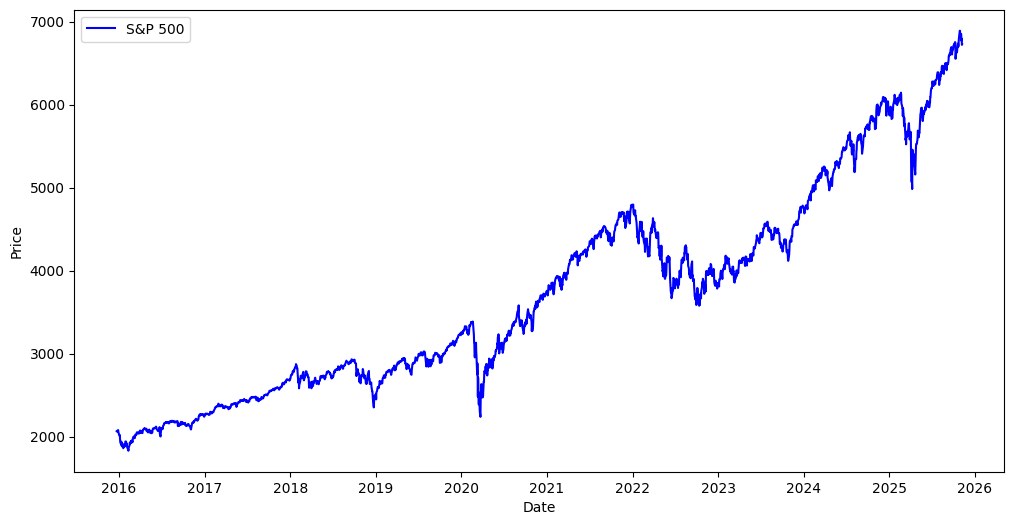

In [29]:
# plot SP500 time series
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['^GSPC'], label='S&P 500', color='blue')
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

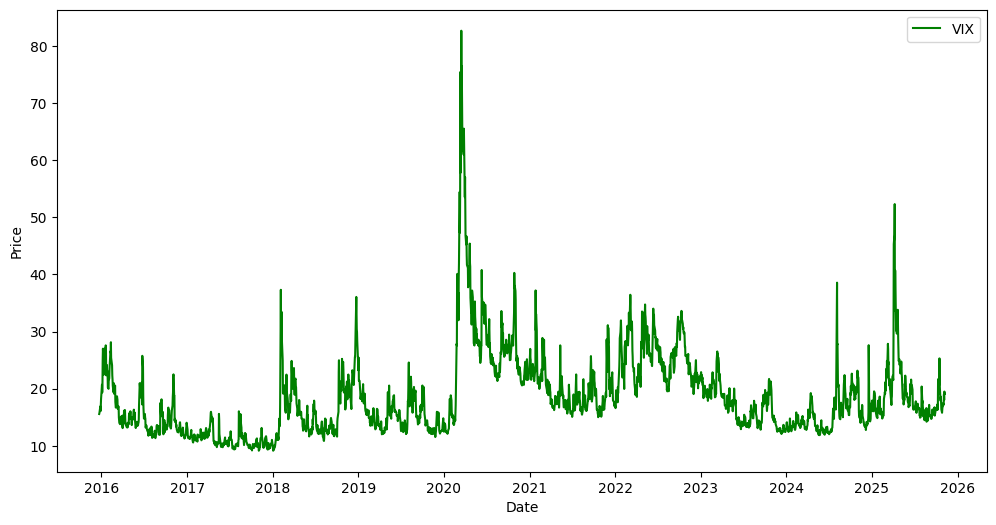

In [30]:
# plot VIX time series
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['^VIX'], label='VIX', color='green')
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [31]:
# calculate log returns for all tickers except VIX
log_returns = np.log(data[tickers[:-1]] / data[tickers[:-1]].shift(1)).fillna(0)

 39%|███▊      | 922/2384 [00:01<00:02, 540.10it/s]

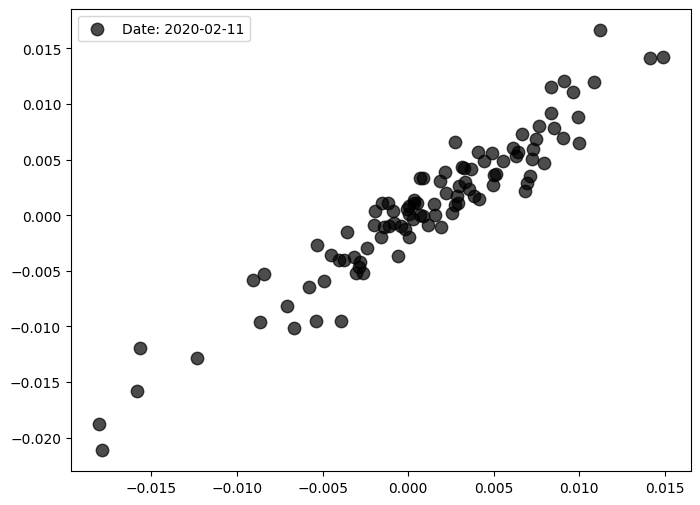

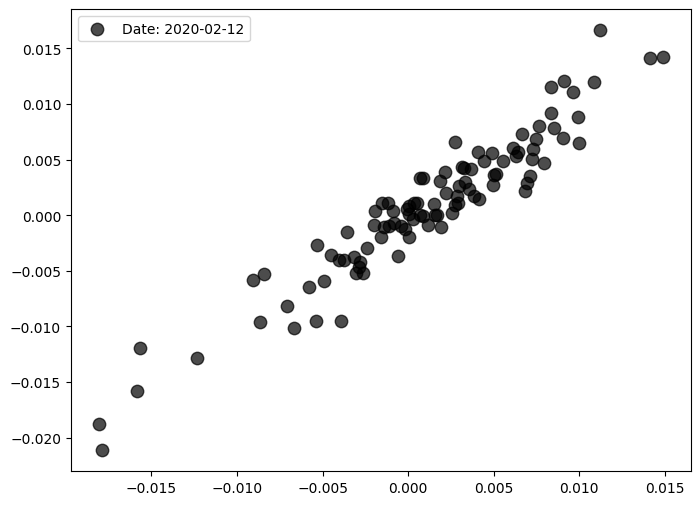

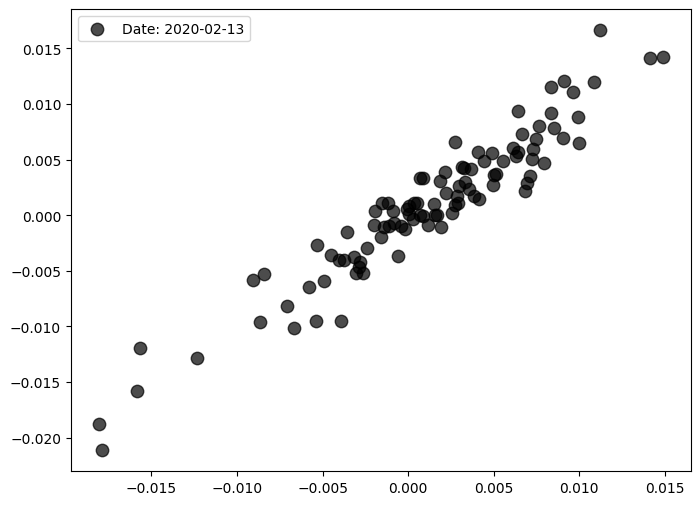

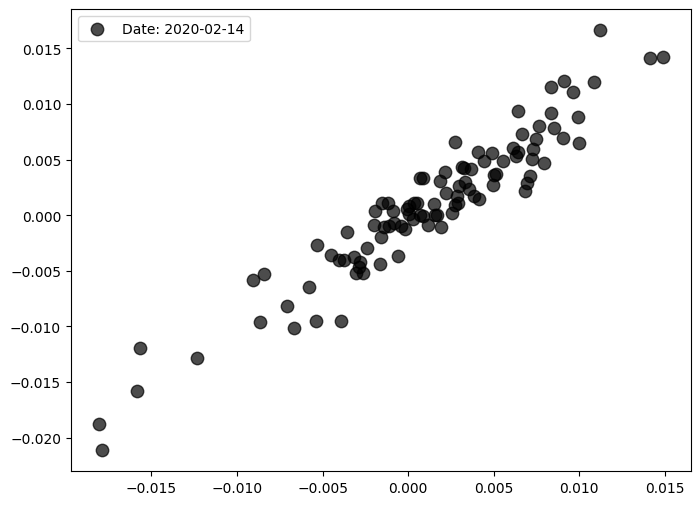

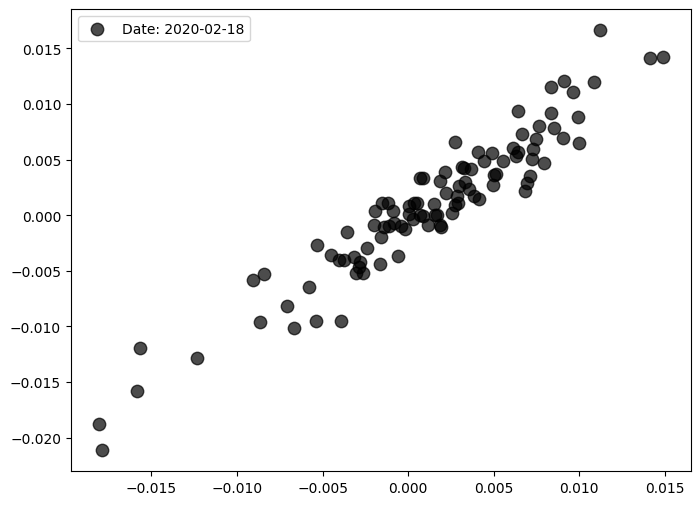

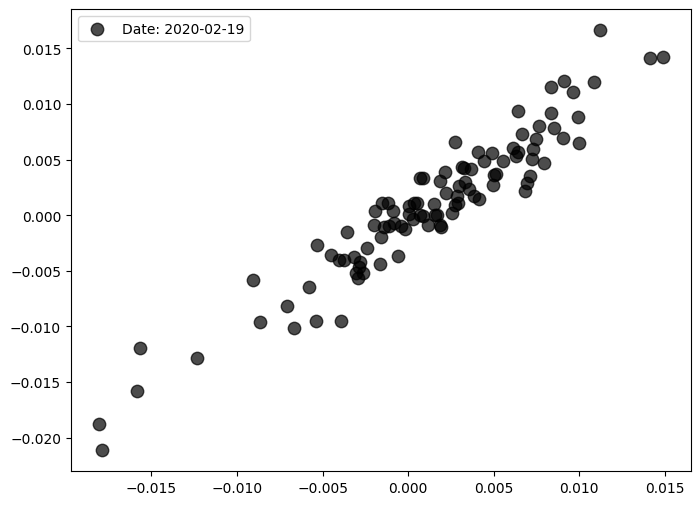

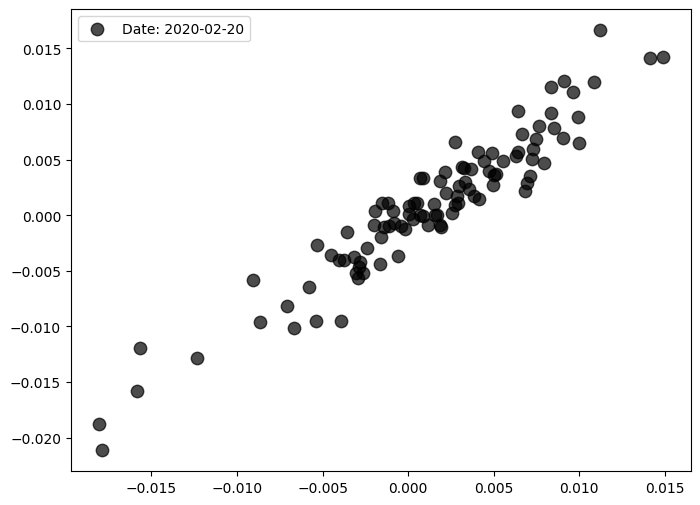

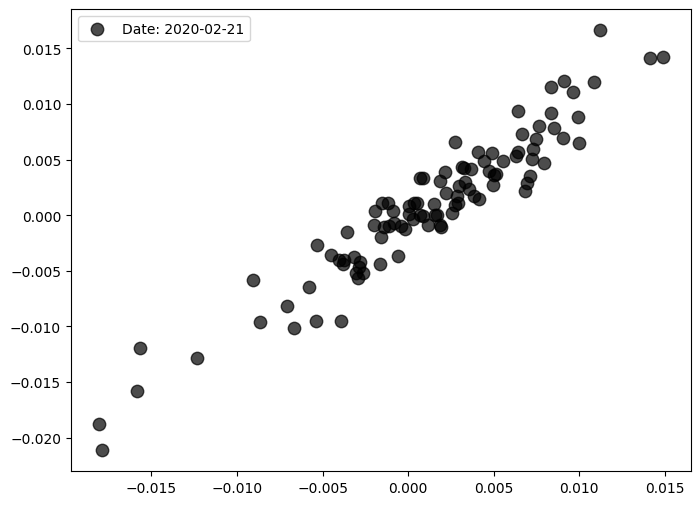

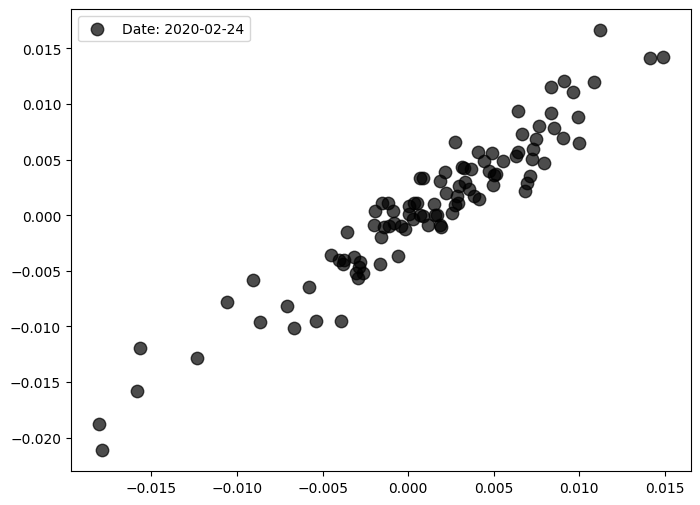

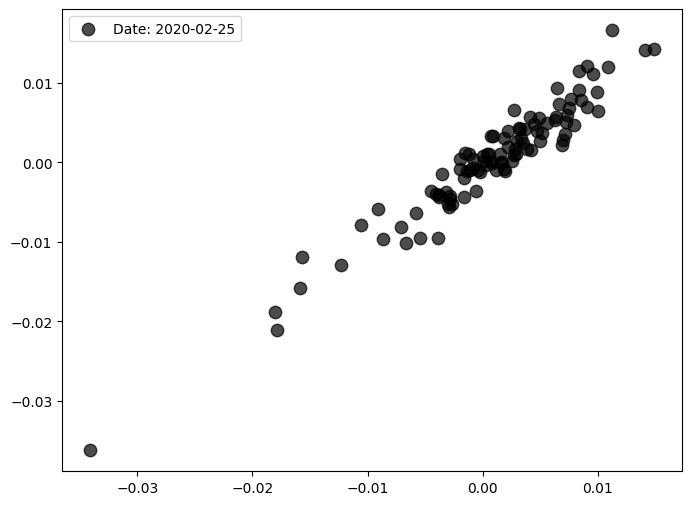

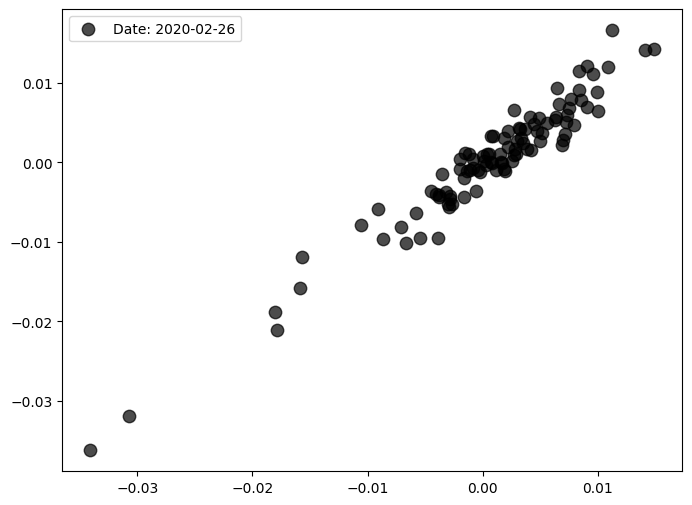

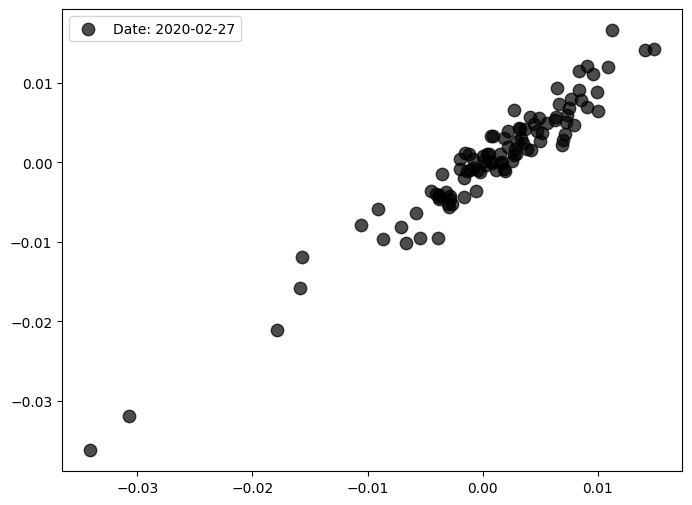

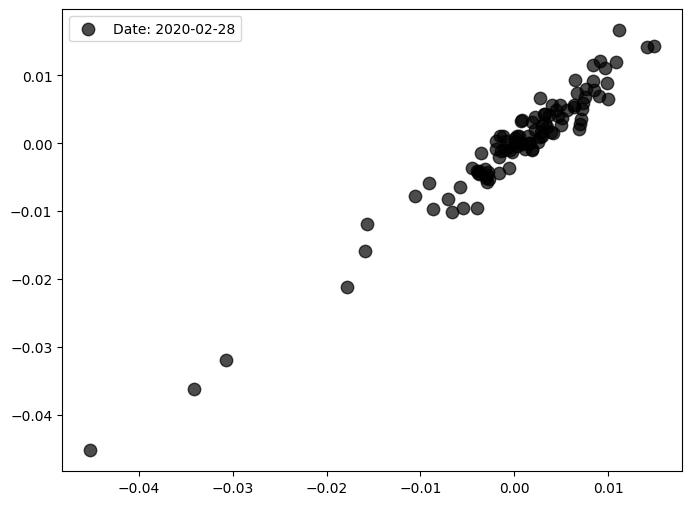

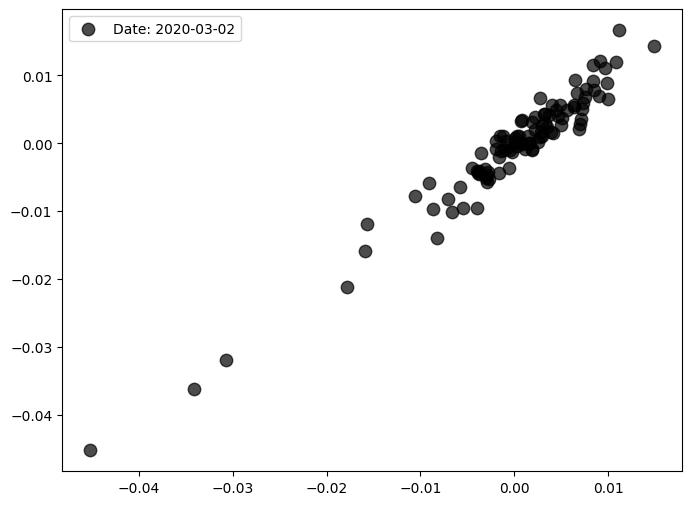

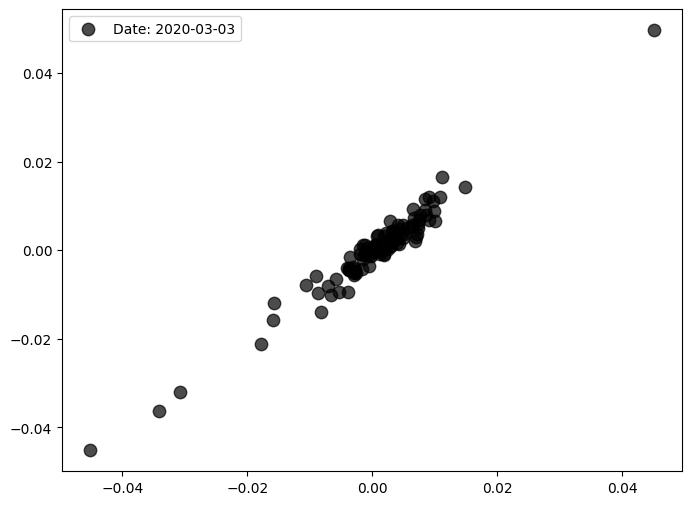

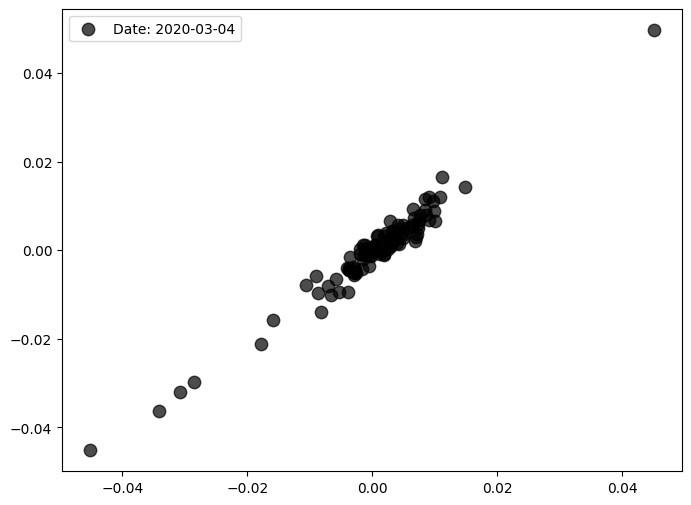

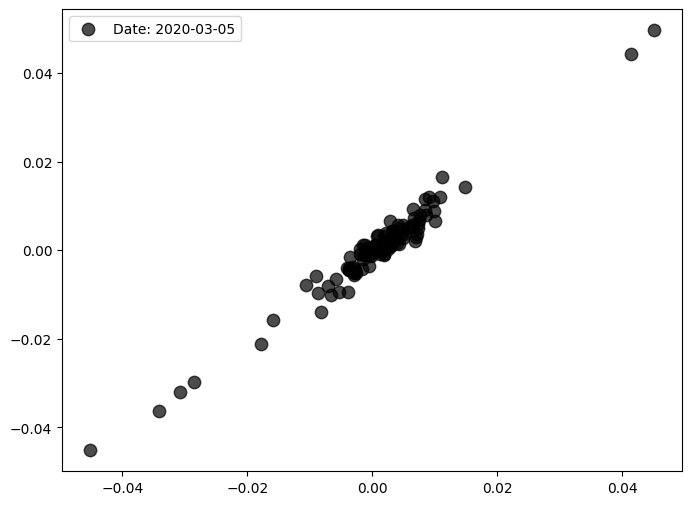

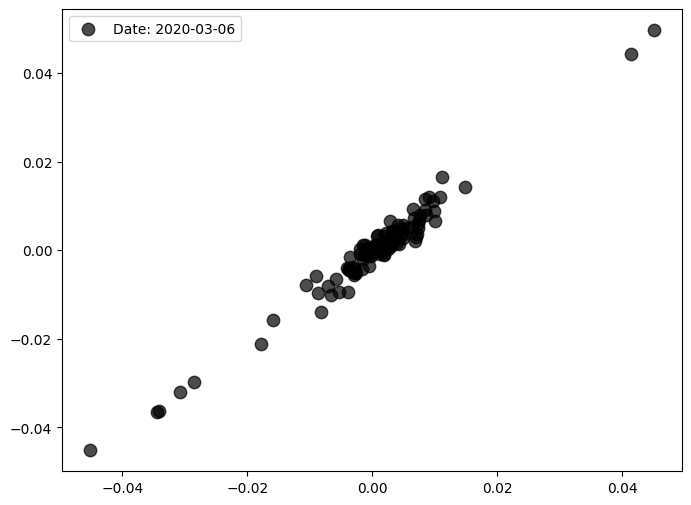

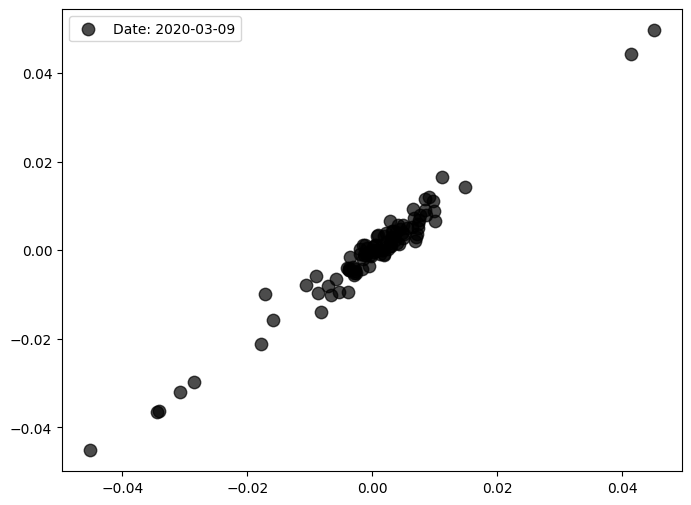

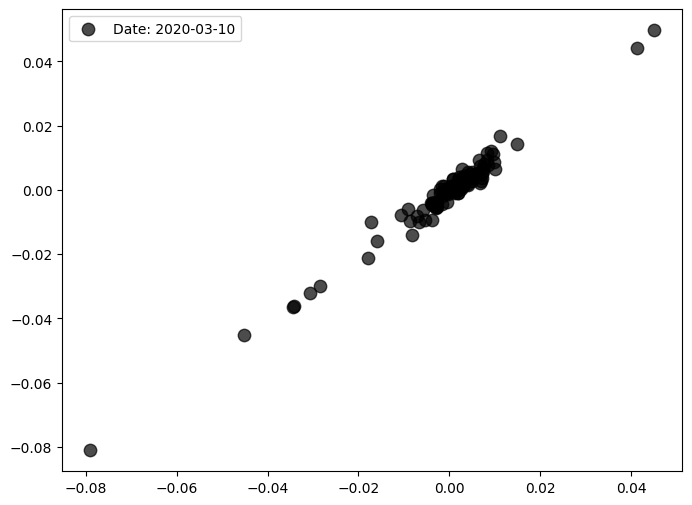

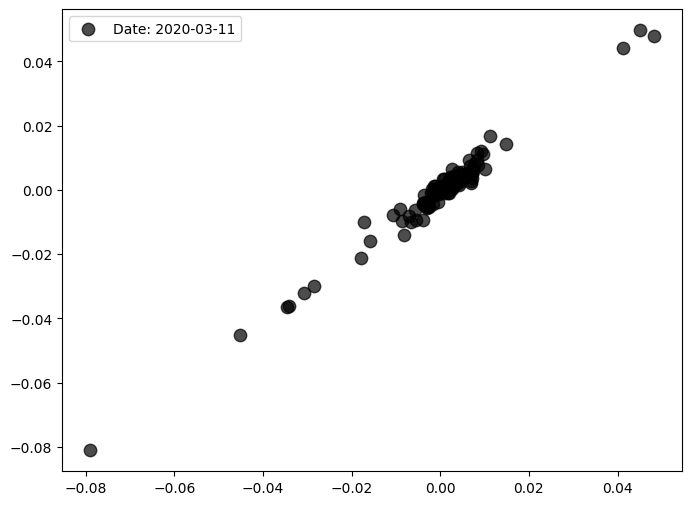

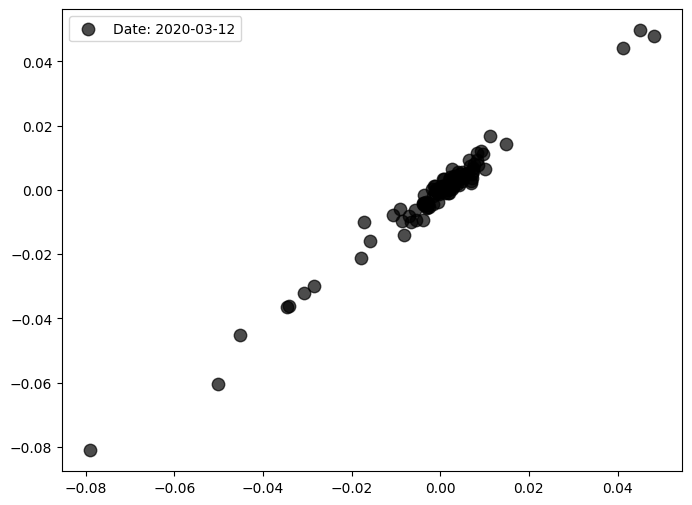

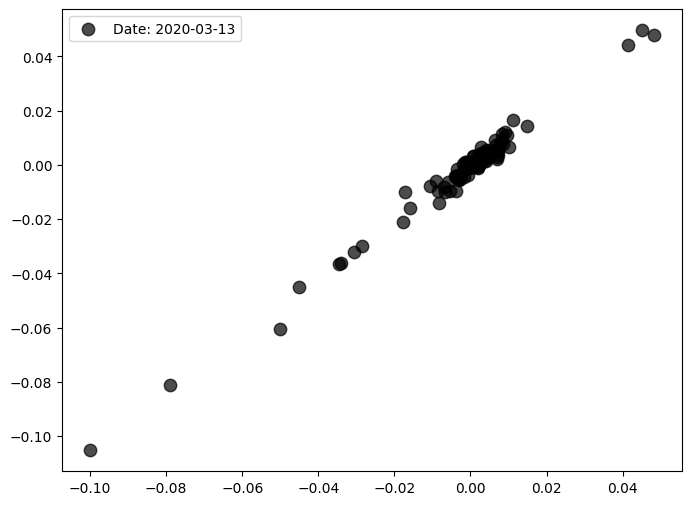

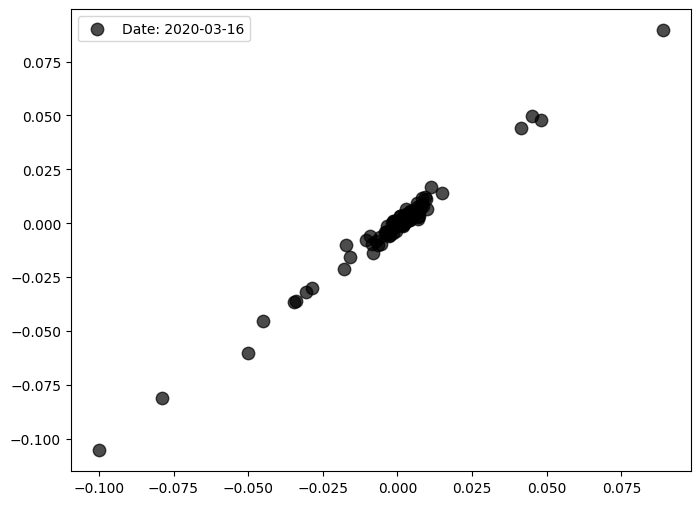

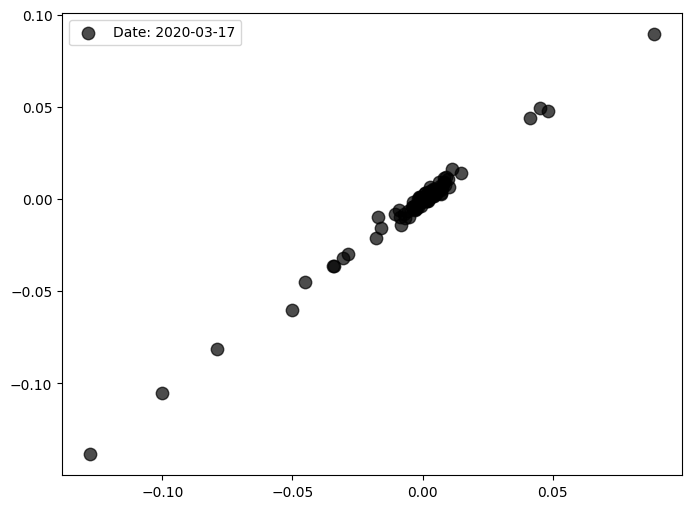

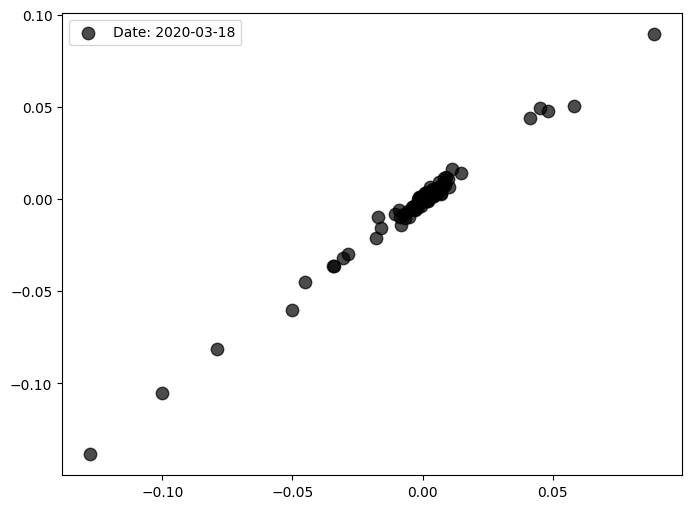

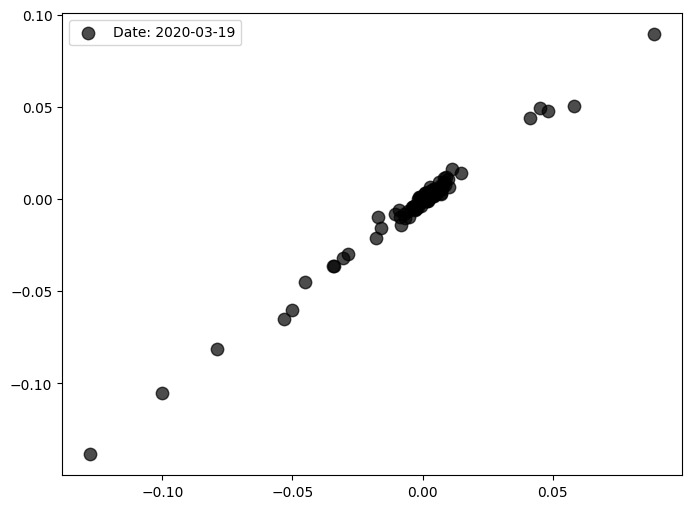

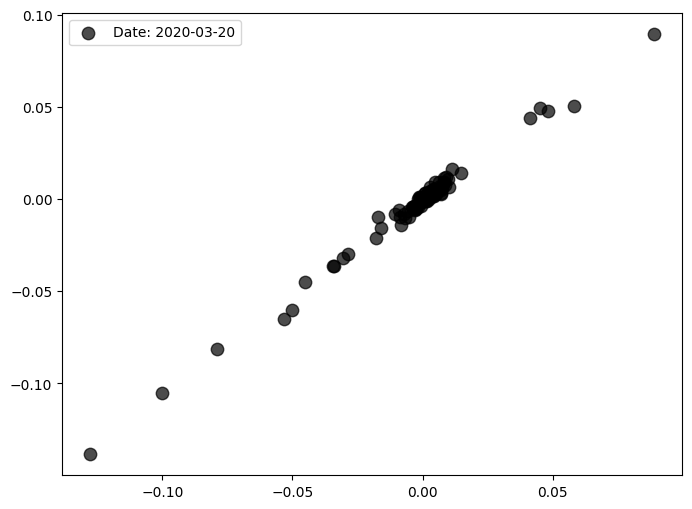

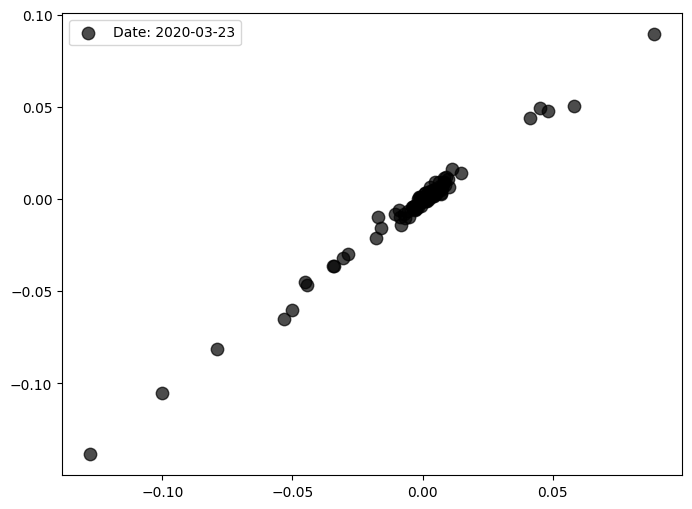

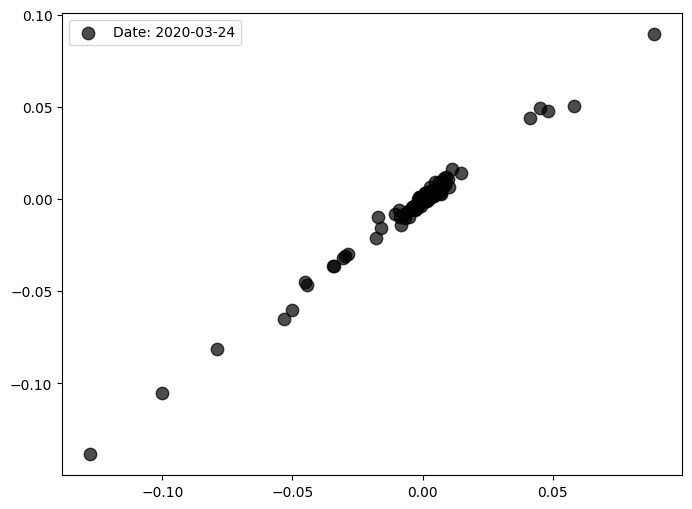

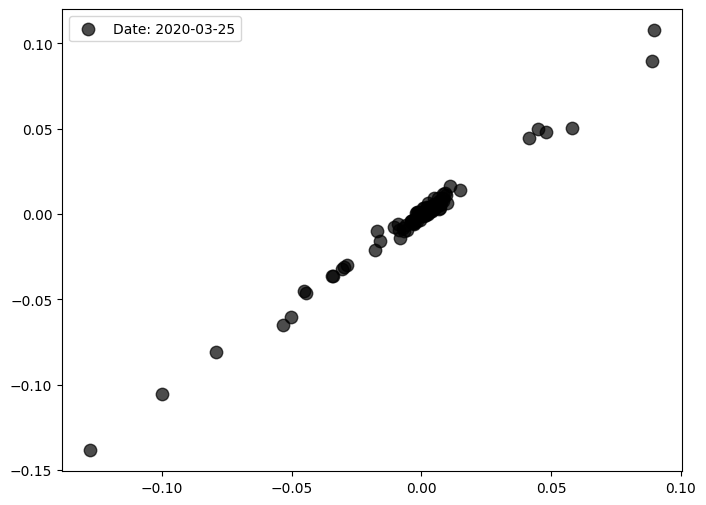

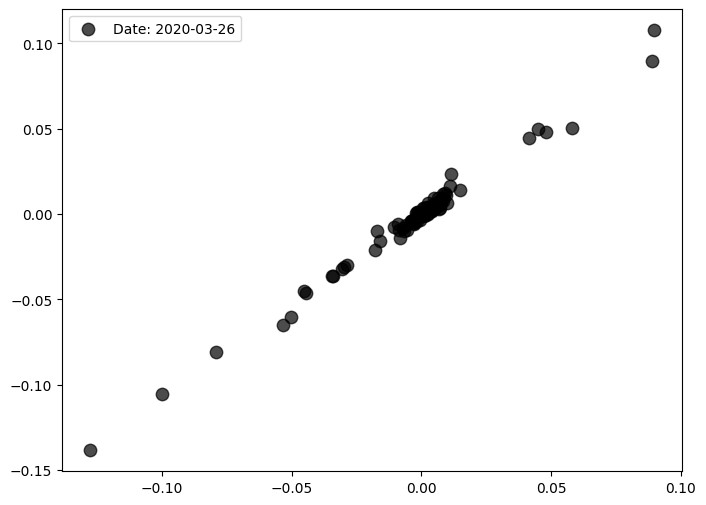

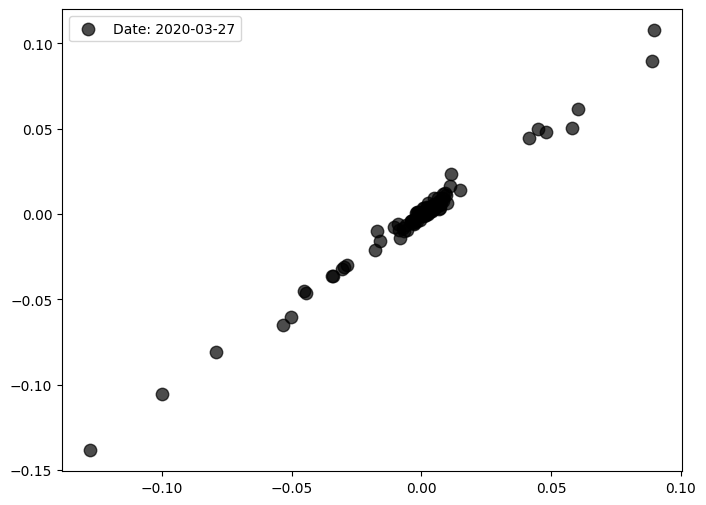

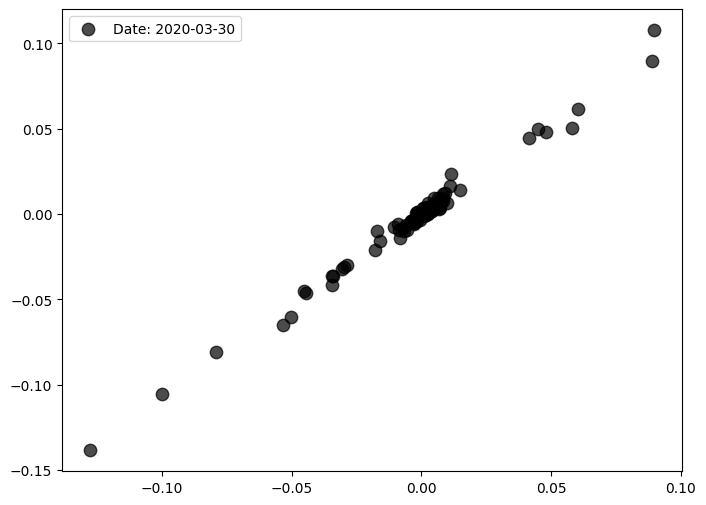

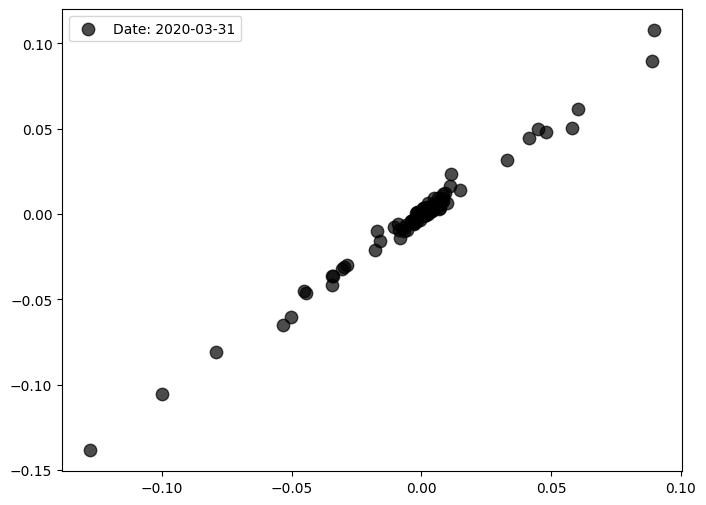

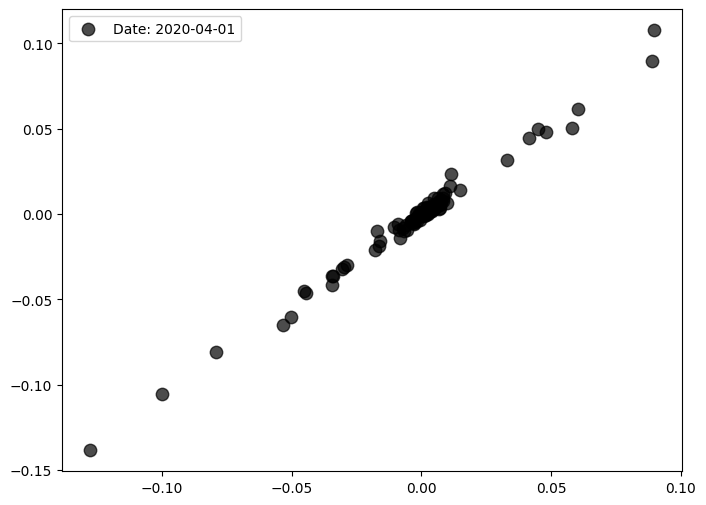

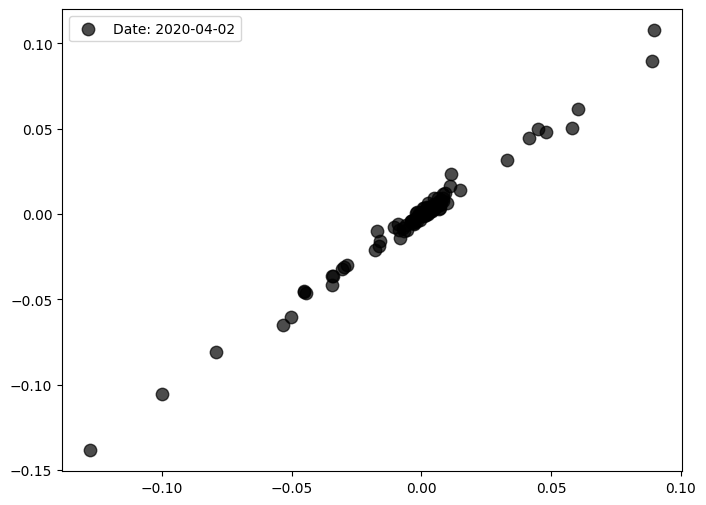

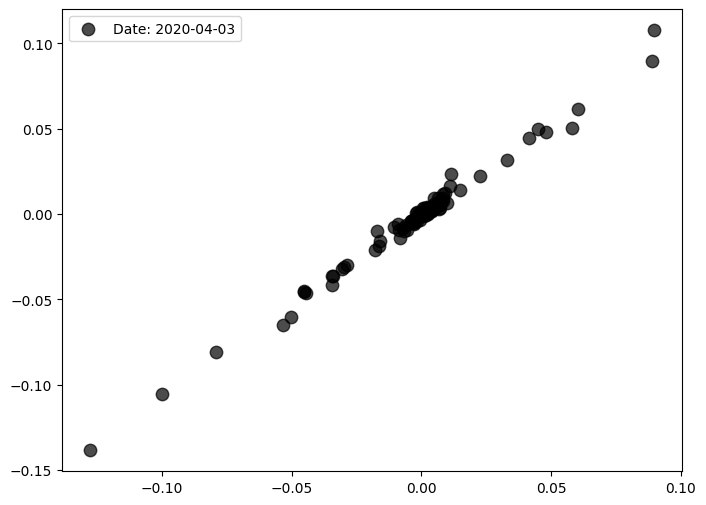

 41%|████      | 977/2384 [00:03<00:17, 81.60it/s] 

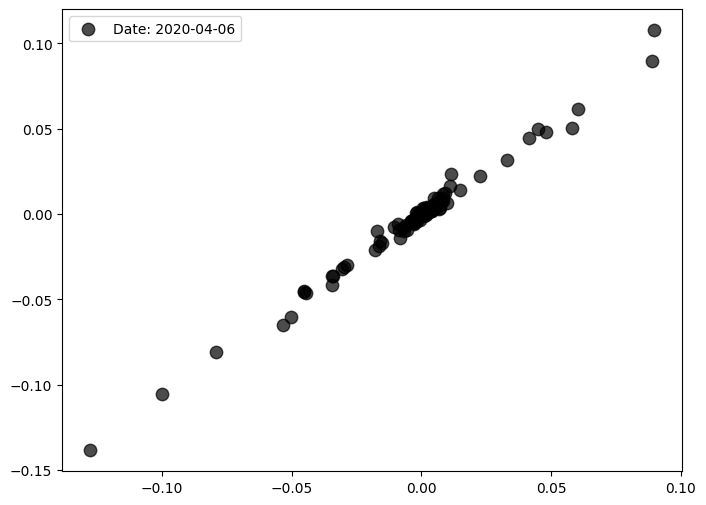

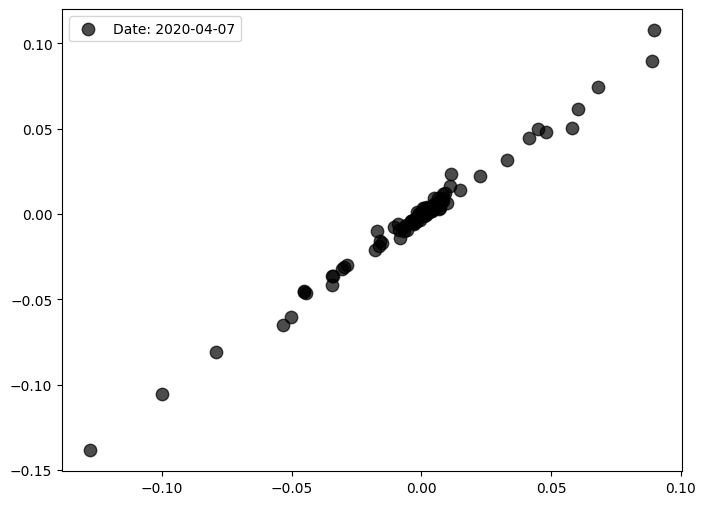

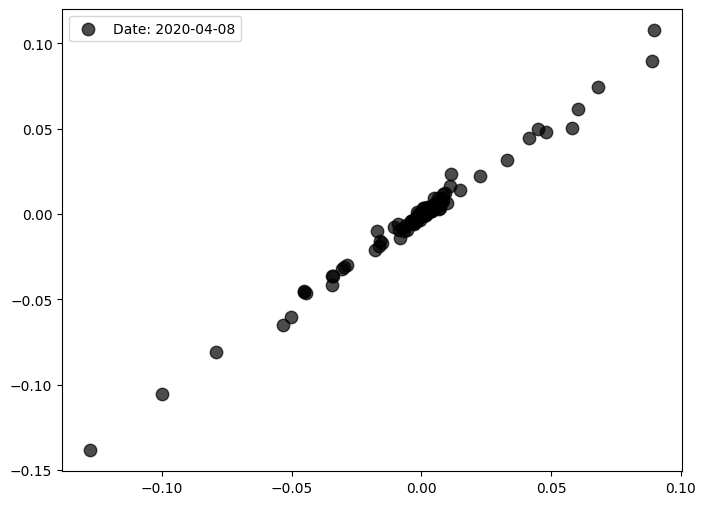

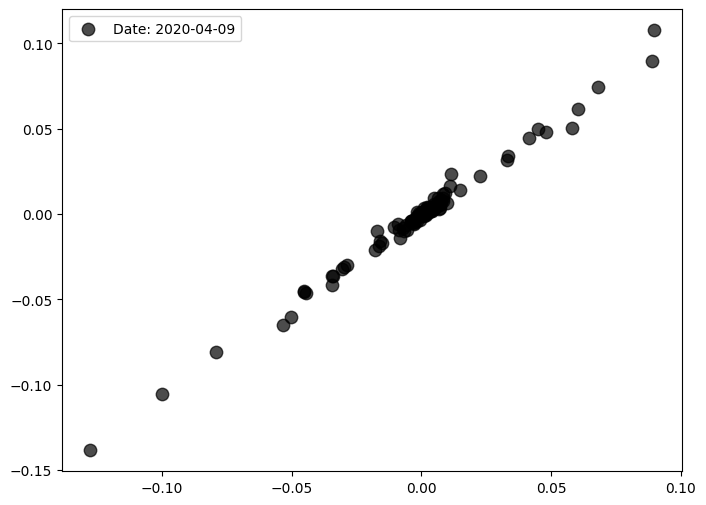

100%|██████████| 2384/2384 [00:06<00:00, 364.78it/s]


In [32]:
from tqdm import tqdm
import gudhi.representations as grepr

w = 100 # window size
diagrams_returns = []

covid_date = pd.Timestamp("2020-03-11")
for i in tqdm(range(w, len(log_returns))):
    window = log_returns.iloc[i-w:i].values  # shape (w, 4)
    rips = ripser.ripser(window)
    diagrams_returns.append(rips['dgms'])

    if np.abs(log_returns.index[i] - covid_date) < pd.Timedelta(days=30):
        # plot the point cloud of the current window
        plt.figure(figsize=(8, 6))
        date = log_returns.index[i]
        plt.scatter(window[:, 0], window[:, 1], c='black', s=80, alpha=0.7, label=f'Date: {date.date()}')
        plt.legend()
        plt.show()

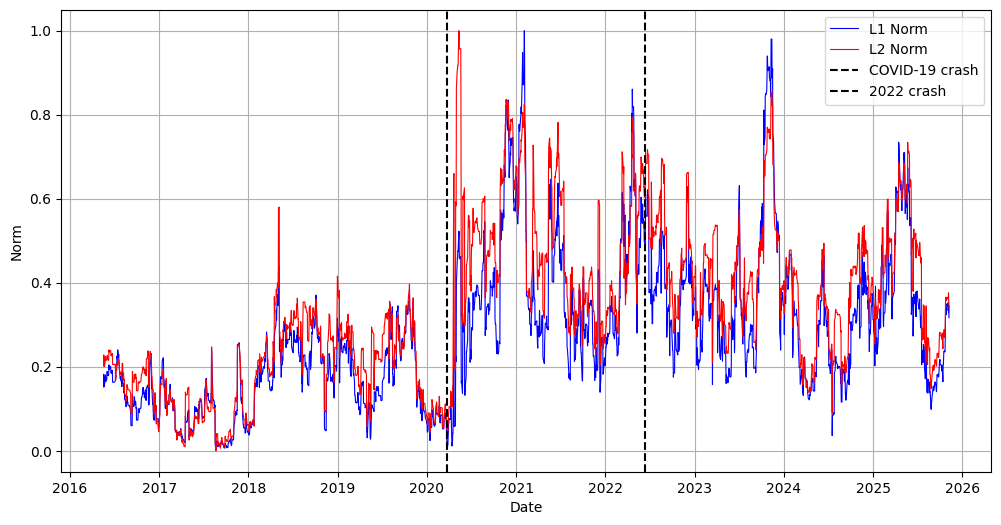

In [34]:
# on two subplots, one is normalized L1 and L2 norms of persistence landscapes over time, other is VIX time series
l1_norms_returns = []
l2_norms_returns = []
for diag in diagrams_returns:
    pl = grepr.Landscape(num_landscapes=10, resolution=500)
    landscape = pl.fit_transform([diag[1]])[0]
    l1_norms_returns.append(np.sum(np.abs(landscape)))
    l2_norms_returns.append(np.sqrt(np.sum(landscape**2)))

# normalize between 0 and 1
l1_norms_returns = (np.array(l1_norms_returns) - np.min(l1_norms_returns)) / (np.max(l1_norms_returns) - np.min(l1_norms_returns))
l2_norms_returns = (np.array(l2_norms_returns) - np.min(l2_norms_returns)) / (np.max(l2_norms_returns) - np.min(l2_norms_returns))

dates = log_returns.index

# on two subplots, one is both normalized L1 / L2 norms of persistence landscapes over time, other is VIX time series
# add vertical lines corresponding to COVID-19 market crash (March 23, 2020) and 2022 market crash (June 13, 2022)
plt.figure(figsize=(12, 6))
plt.plot(dates[w:], l1_norms_returns, label='L1 Norm', color='blue', linewidth=0.8)
plt.plot(dates[w:], l2_norms_returns, label='L2 Norm', color='red', linewidth=0.8)
plt.axvline(pd.Timestamp('2020-03-23'), color='black', linestyle='--', label='COVID-19 crash')
plt.axvline(pd.Timestamp('2022-06-13'), color='BLACK', linestyle='--', label='2022 crash')
plt.xlabel("Date")
plt.ylabel("Norm")
plt.legend()
plt.grid()
plt.show()

In [37]:
# use the library ruptures to detect change points in the L2 norm time series.
import ruptures as rpt

l2_signal = l2_norms_returns.reshape(-1, 1)
model = "l2"
algo = rpt.Pelt(model=model).fit(l2_signal)
result = algo.predict(pen=4)

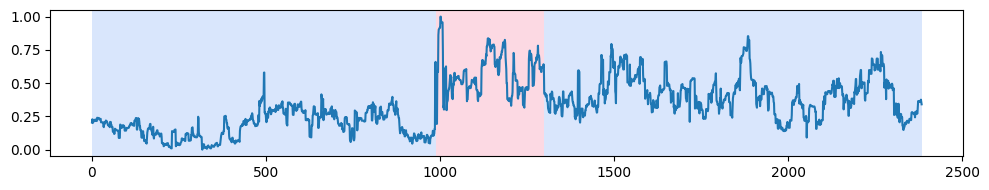

In [38]:
# plot the change points on the L2 norm time series
rpt.display(l2_signal, result)
plt.show()

In [39]:
# find the dates of the detected change points
change_point_dates = [dates[w + cp] for cp in result[:-1]]
print("Detected Change Points Dates:")
for date in change_point_dates:
    print(date)

Detected Change Points Dates:
2020-04-24 00:00:00
2021-07-19 00:00:00


In [40]:
# employ the 500 days rolling window with the sliding step of one day to calculate the variance, the average spectral density at low frequencies and the firstlag of the auto-correlation function (ACF) of the L2 norm for 250 trading days prior to the date of a market crash

import statsmodels.api as sm
from scipy.signal import welch

window_size = 500
variances = []
avg_spectral_densities = []
firstlags = []

for i in tqdm(range(window_size, len(l2_norms_returns))):
    window = pd.Series(l2_norms_returns[i-window_size:i])
    
    # Variance
    variance = window.var()
    variances.append(variance)
    
    # Average spectral density at low frequencies
    f, Pxx = welch(window.values, fs=1.0)
    low_freq_indices = f < 0.1
    avg_spectral_density = Pxx[low_freq_indices].mean()
    avg_spectral_densities.append(avg_spectral_density)

    # First lag of the Auto-Correlation Function (ACF)
    acf_values = sm.tsa.acf(window.values, nlags=1, fft=True)
    firstlag = acf_values[1].mean()
    firstlags.append(firstlag)

100%|██████████| 1884/1884 [00:00<00:00, 4963.80it/s]


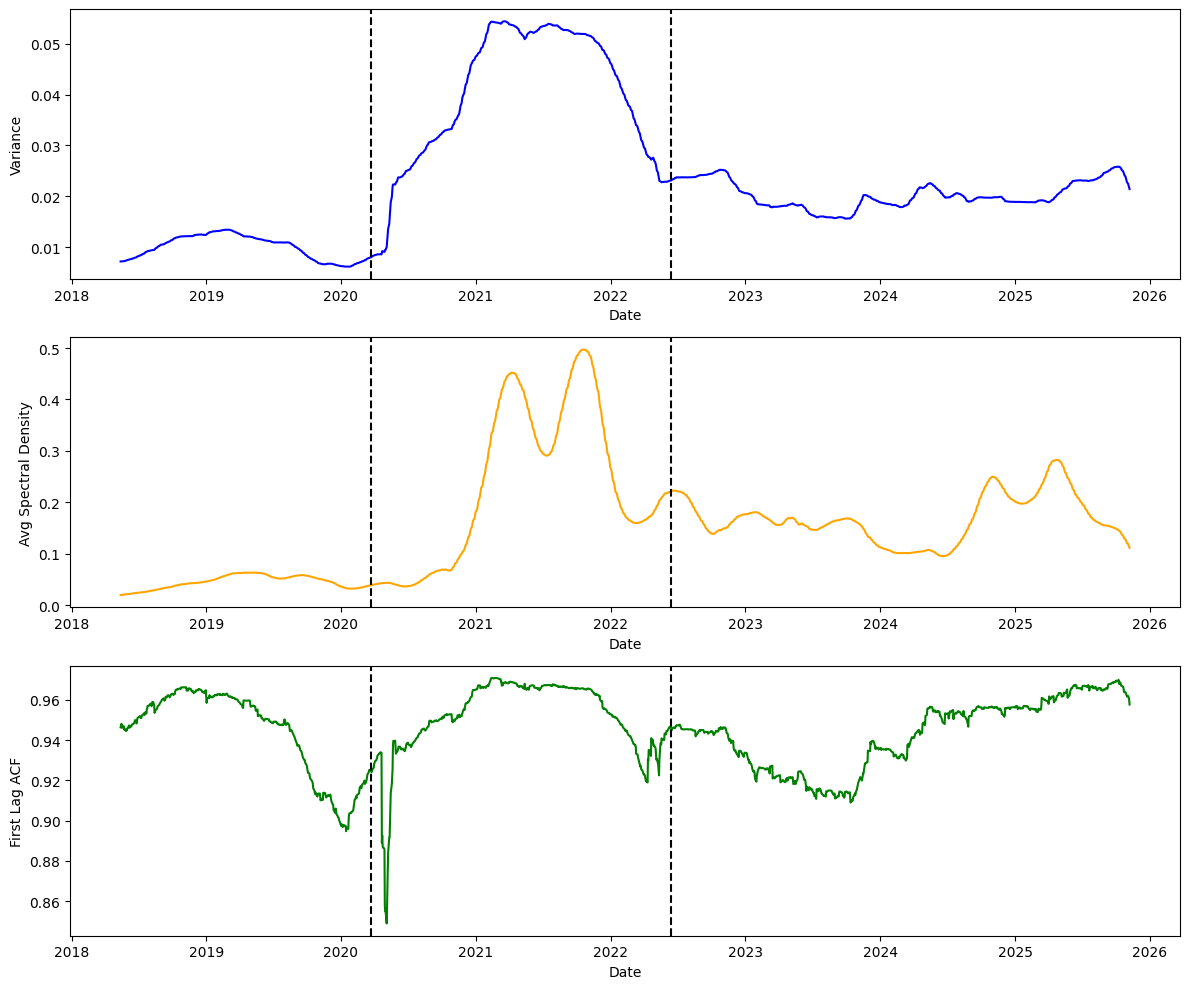

In [41]:
# plot variance, average spectral density, and firstlag over time

plt.figure(figsize=(12, 10))
plt.subplot(3, 1, 1)
plt.plot(dates[window_size+100:], variances, label='Variance', color='blue')
plt.axvline(pd.Timestamp("2020-03-23"), color='black', linestyle='--',  label='Covid-19 crash')
plt.axvline(pd.Timestamp('2022-06-13'), color='black', linestyle='--', label='2022 crash')
plt.xlabel("Date")
plt.ylabel("Variance")
plt.subplot(3, 1, 2)
plt.plot(dates[window_size+100:], avg_spectral_densities, label='Avg Spectral Density', color='orange')
plt.axvline(pd.Timestamp("2020-03-23"), color='black', linestyle='--',  label='Covid-19 crash')
plt.axvline(pd.Timestamp('2022-06-13'), color='black', linestyle='--', label='2022 crash')
plt.xlabel("Date")
plt.ylabel("Avg Spectral Density")
plt.subplot(3, 1, 3)
plt.plot(dates[window_size+100:], firstlags, label='First Lag ACF', color='green')
plt.axvline(pd.Timestamp("2020-03-23"), color='black', linestyle='--',  label='Covid-19 crash')
plt.axvline(pd.Timestamp('2022-06-13'), color='black', linestyle='--', label='2022 crash')
plt.xlabel("Date")
plt.ylabel("First Lag ACF")
plt.tight_layout()
plt.show()

# Empirical analysis of financial data (ETF) - Covid-19 crisis and 2022 crash

In [49]:
# We analyze the daily time series of four major US stock market indices: S&P 500, DJIA, NASDAQ, Russel 2000? and VIX between December 23, 1987 and December 08, 2016 (7301 trading days). The times series data were downloaded from Yahoo Finance
# try other tickers : use several ETF such as XLF, XLK, XLE, XLY, XLI

tickers = ['XLY', 'XLP', 'XLE', 'XLF', 'XLV', 'XLI', 'XLB', 'XLK', 'XLU', 'SPY', '^VIX']

data = yf.download(tickers, start='2015-12-23', end='2025-11-08')['Close']

C:\Users\eliot\AppData\Local\Temp\ipykernel_5412\1393716305.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2015-12-23', end='2025-11-08')['Close']
[*********************100%***********************]  11 of 11 completed


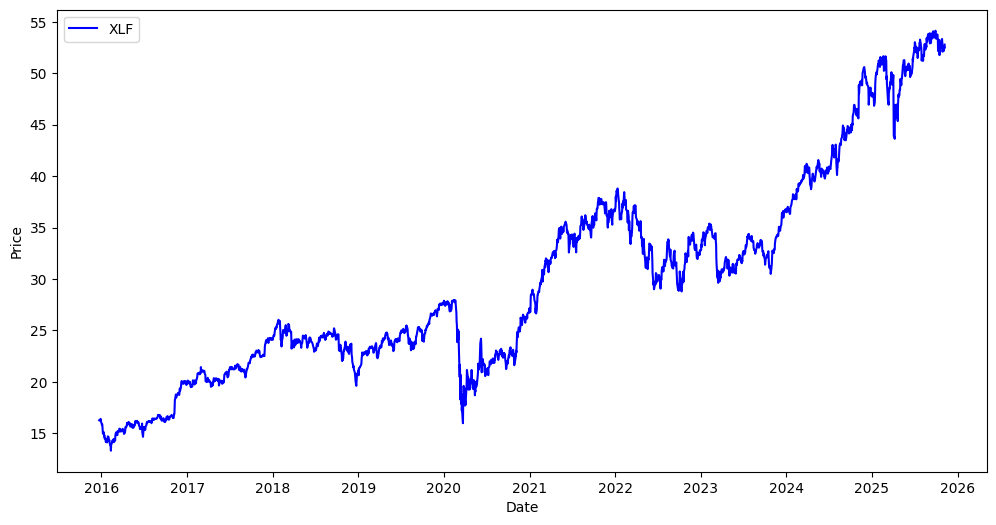

In [50]:
# plot SP500 time series
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['XLF'], label='XLF', color='blue')
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

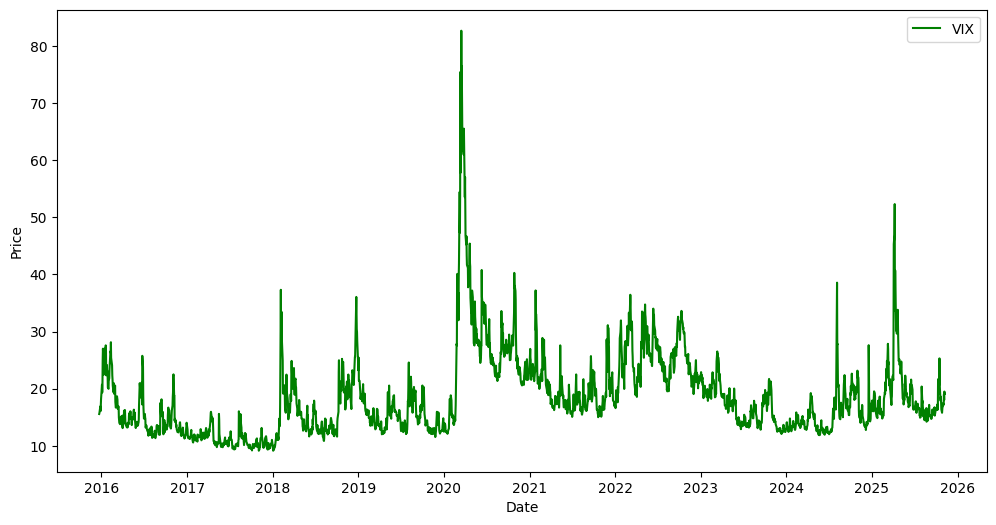

In [51]:
# plot VIX time series
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['^VIX'], label='VIX', color='green')
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [52]:
# calculate log returns for all tickers except VIX
log_returns = np.log(data[tickers[:-1]] / data[tickers[:-1]].shift(1)).fillna(0)

 37%|███▋      | 887/2384 [00:01<00:02, 523.56it/s]

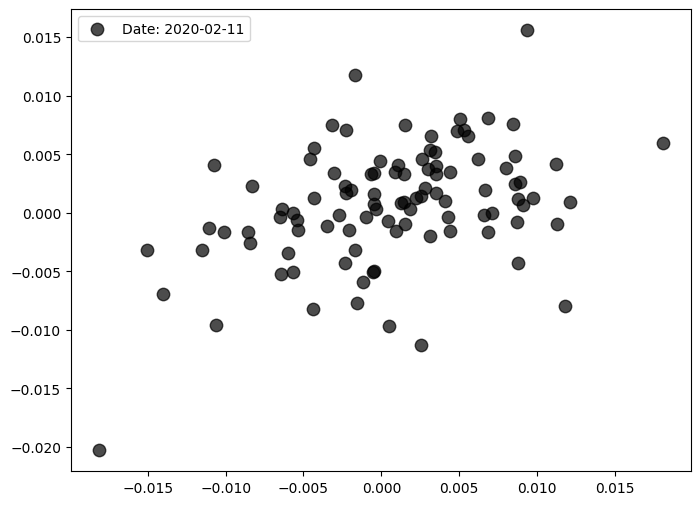

 39%|███▉      | 940/2384 [00:01<00:03, 463.13it/s]

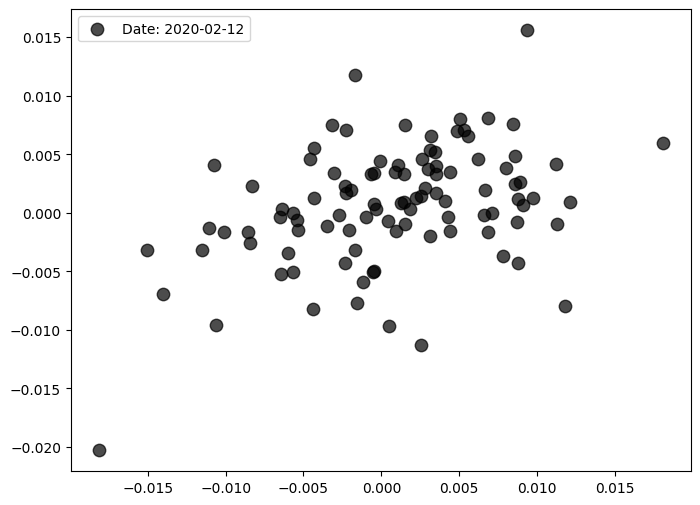

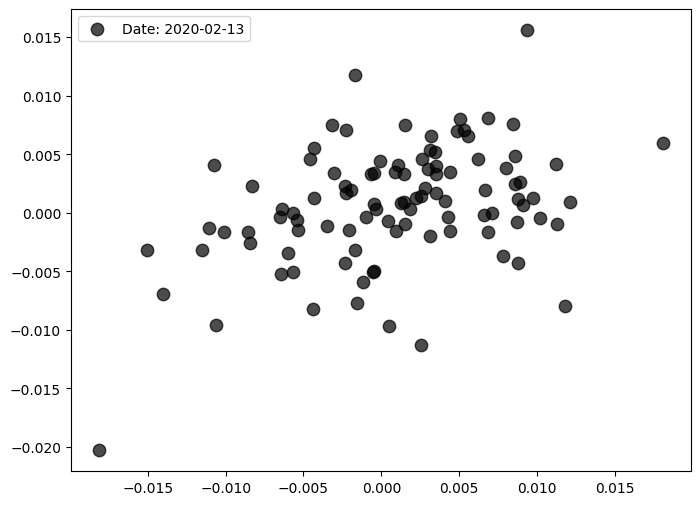

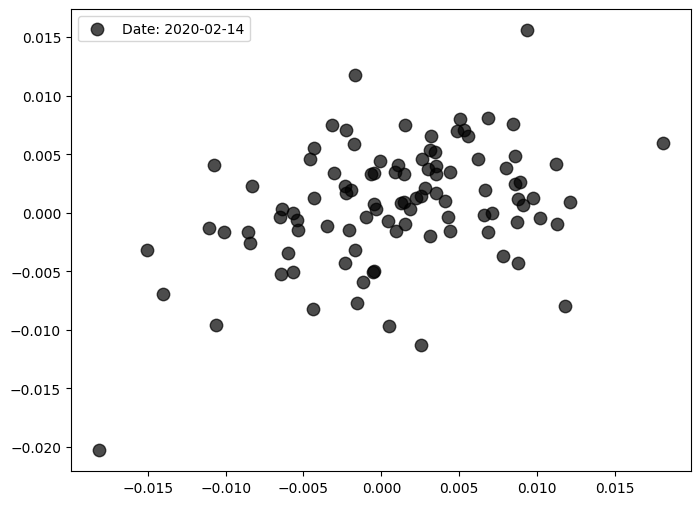

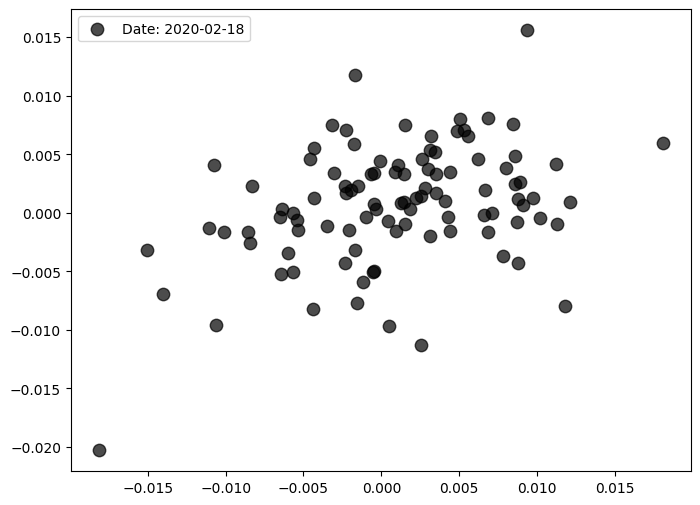

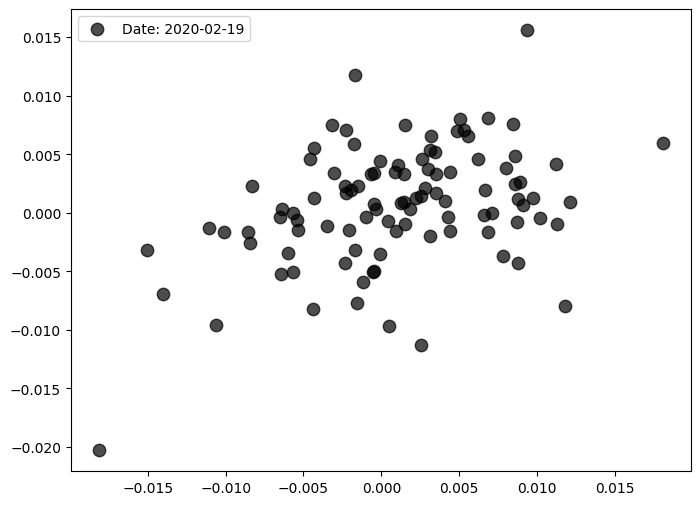

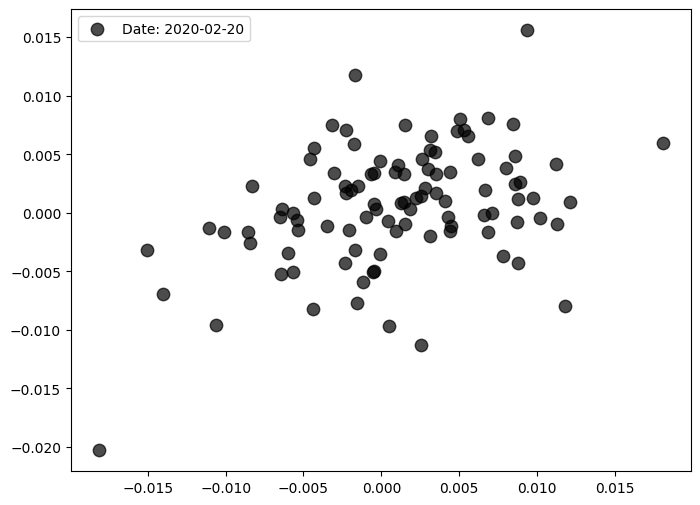

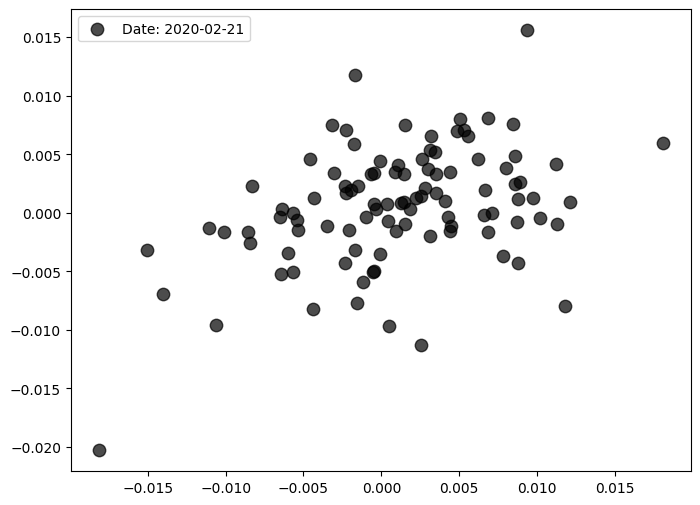

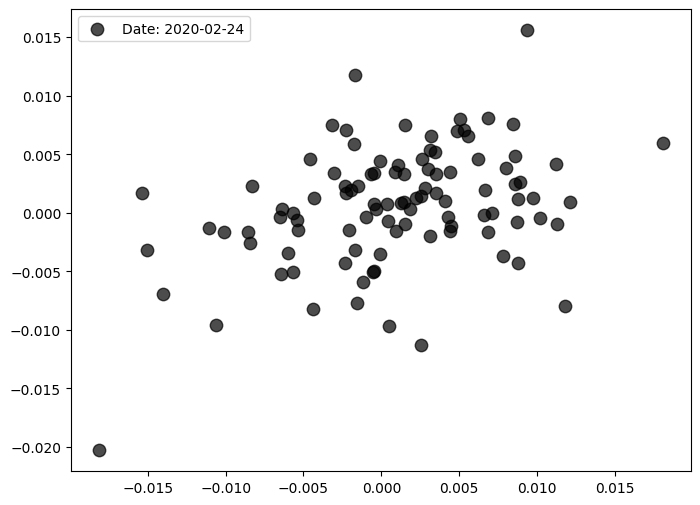

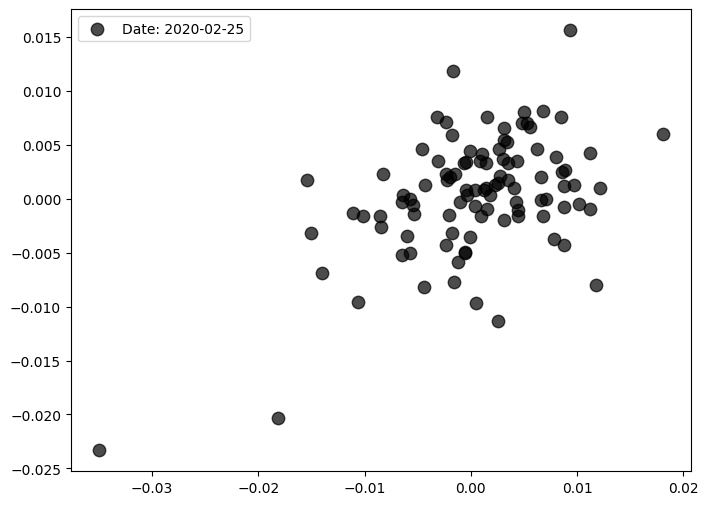

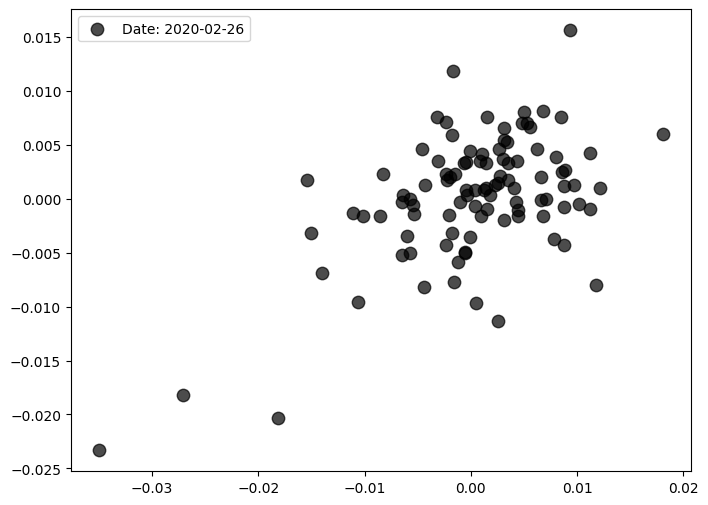

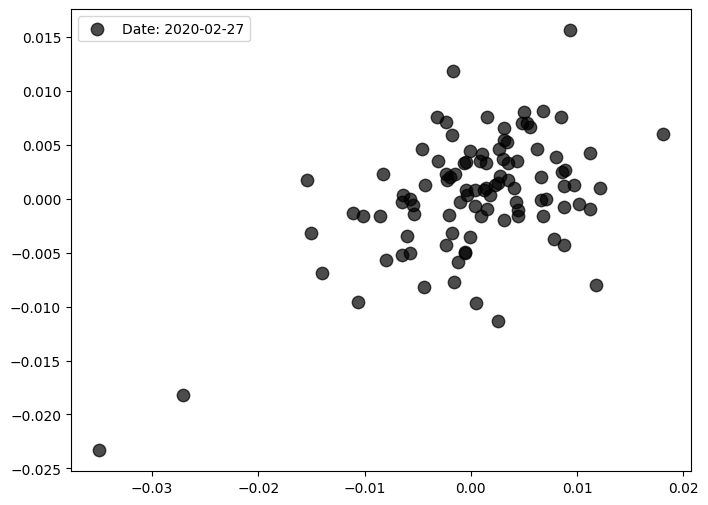

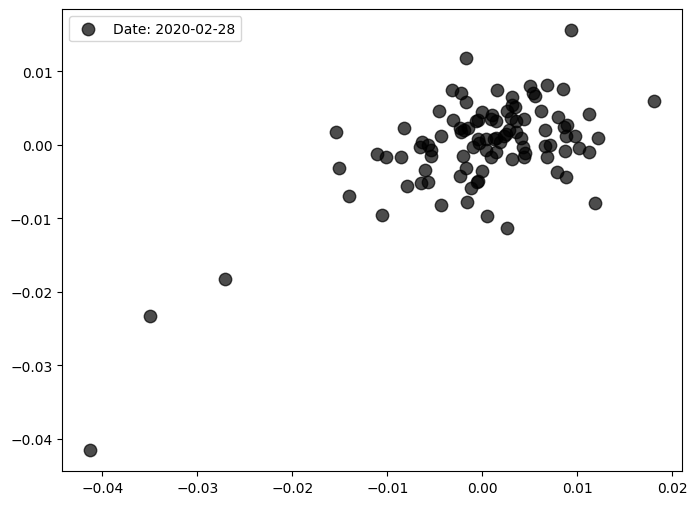

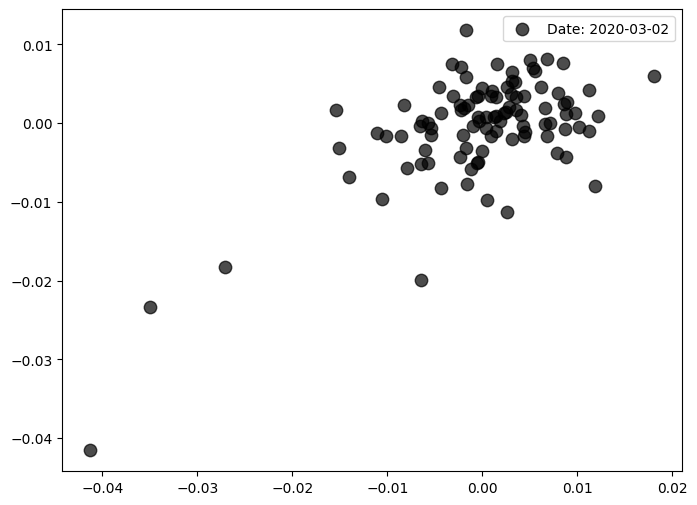

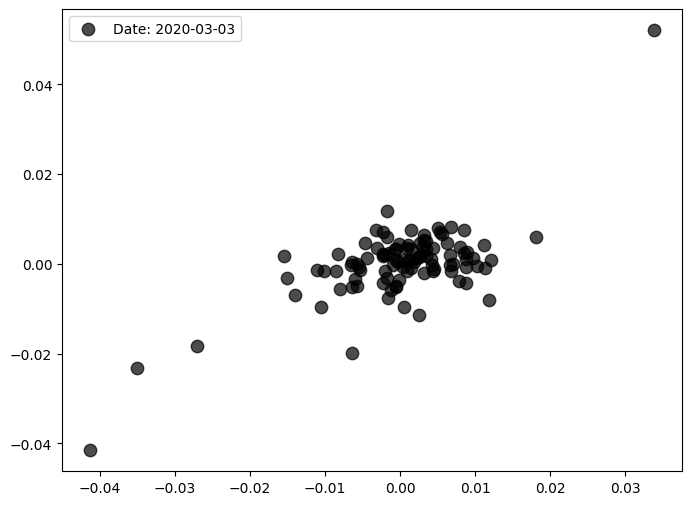

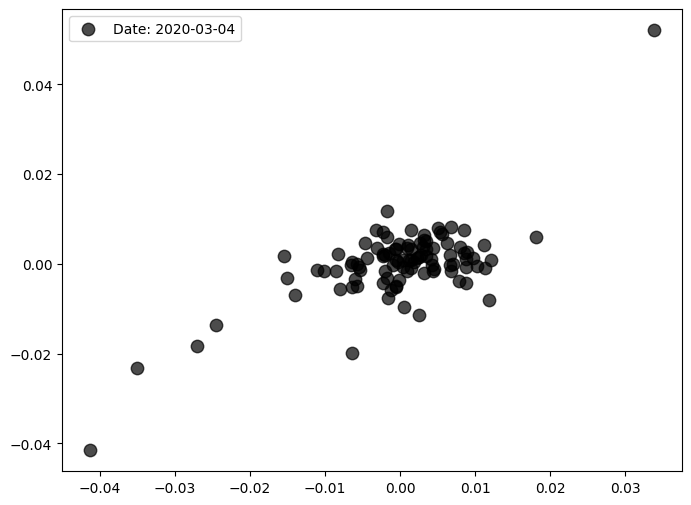

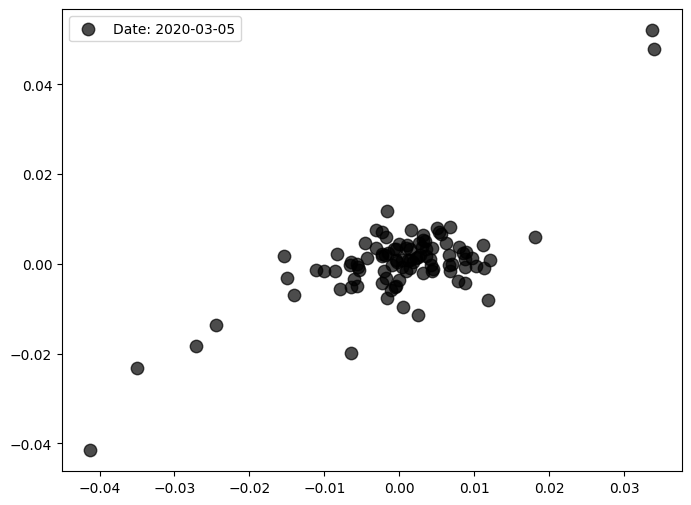

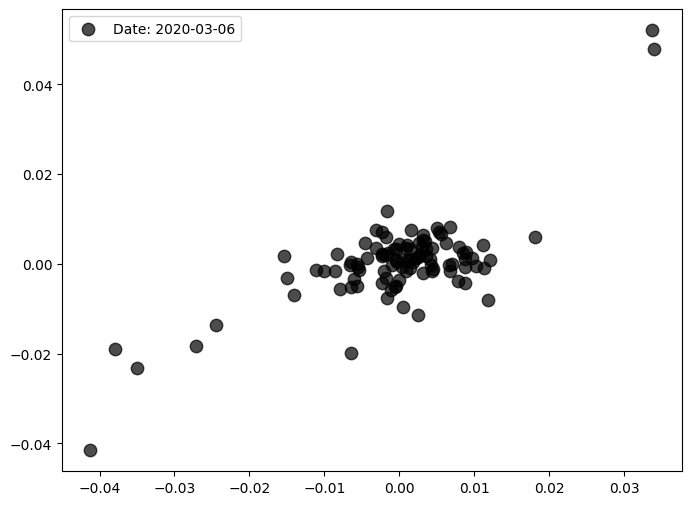

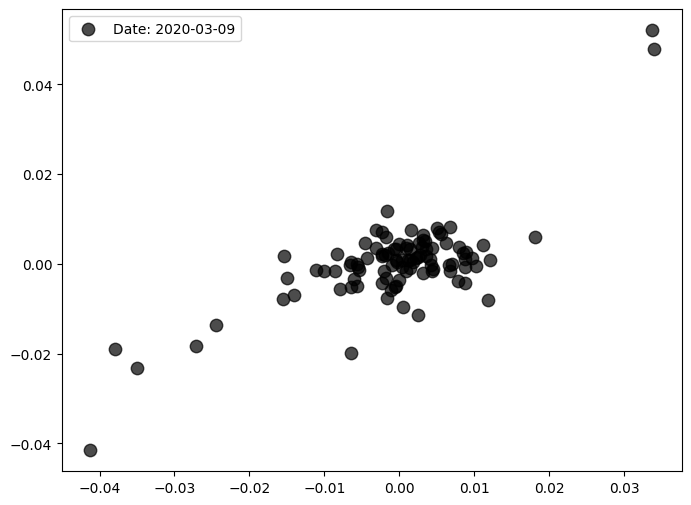

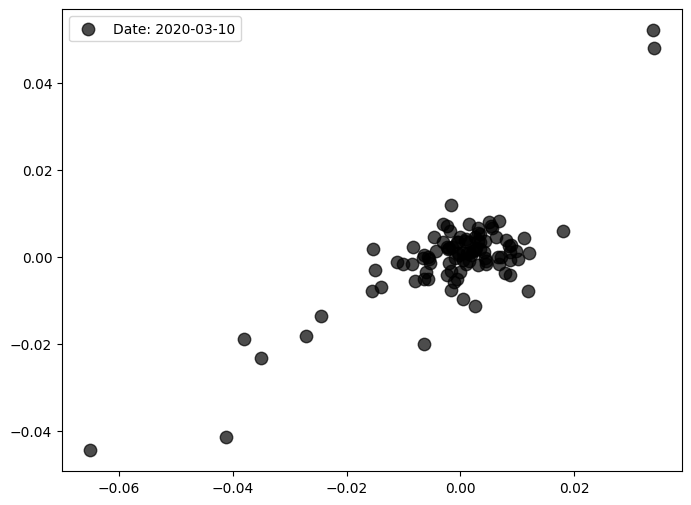

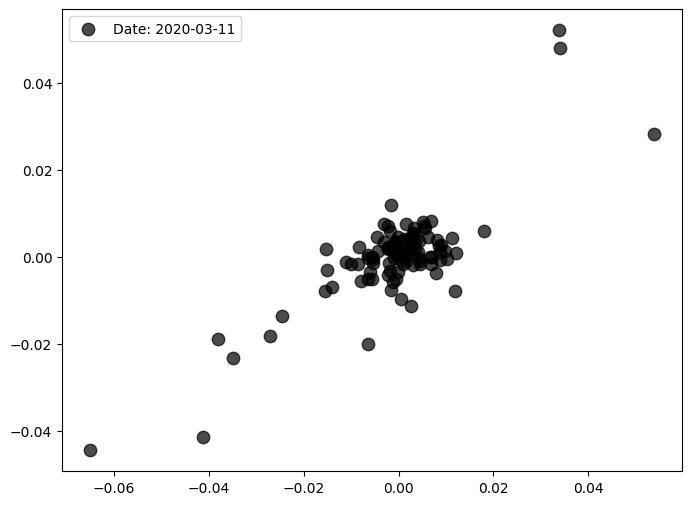

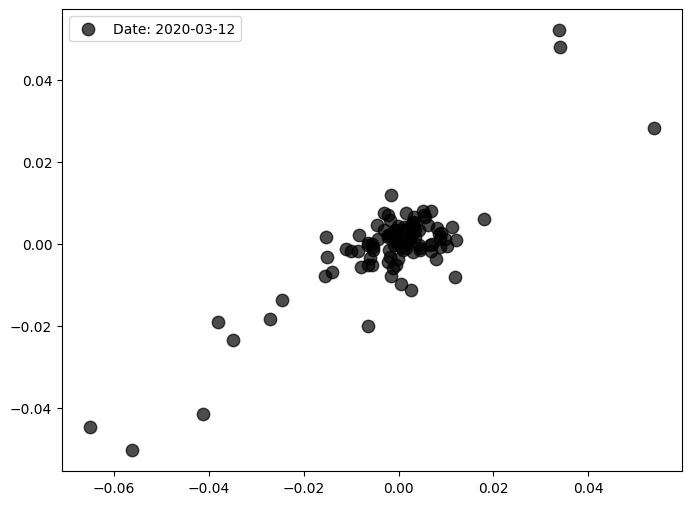

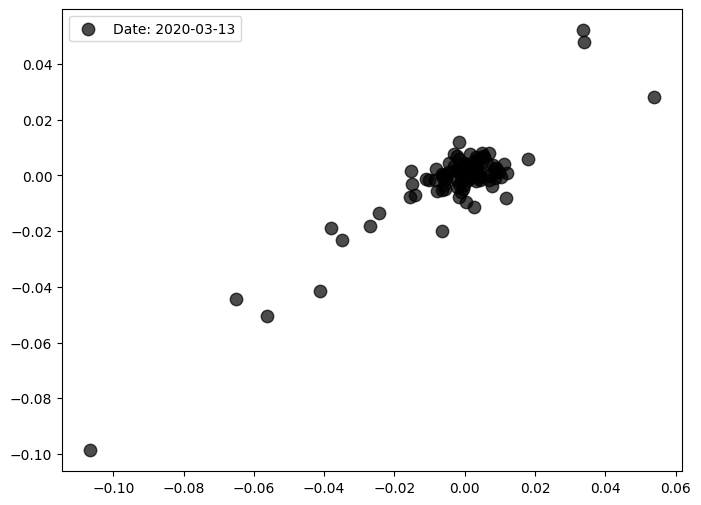

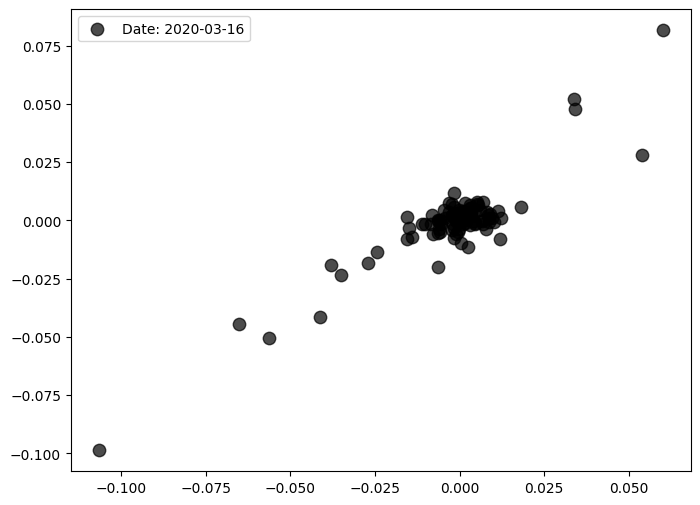

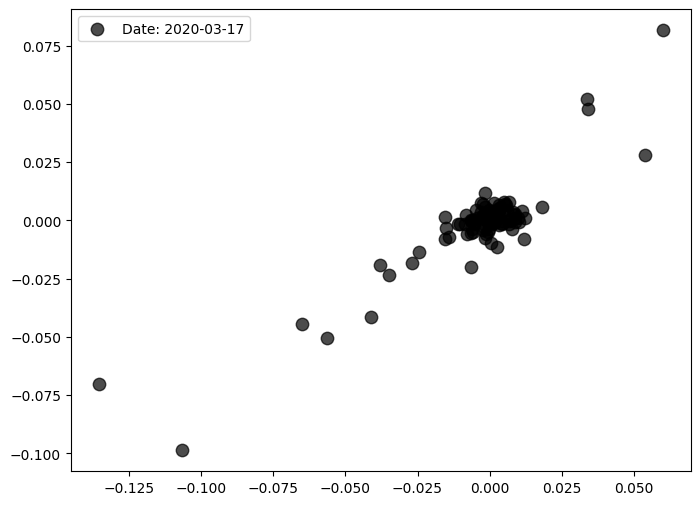

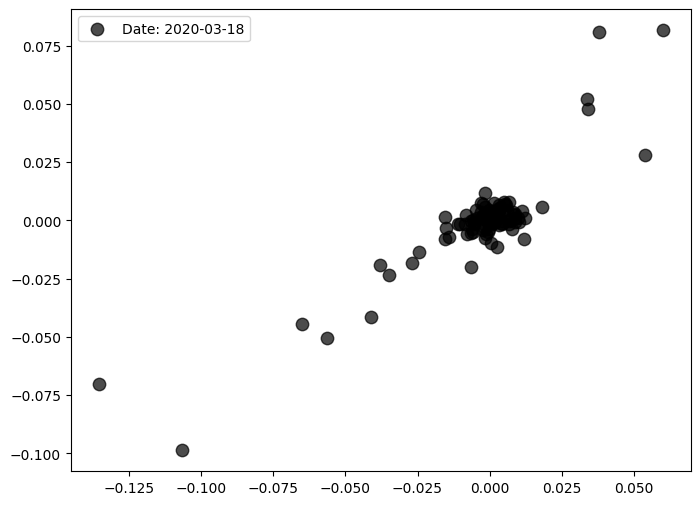

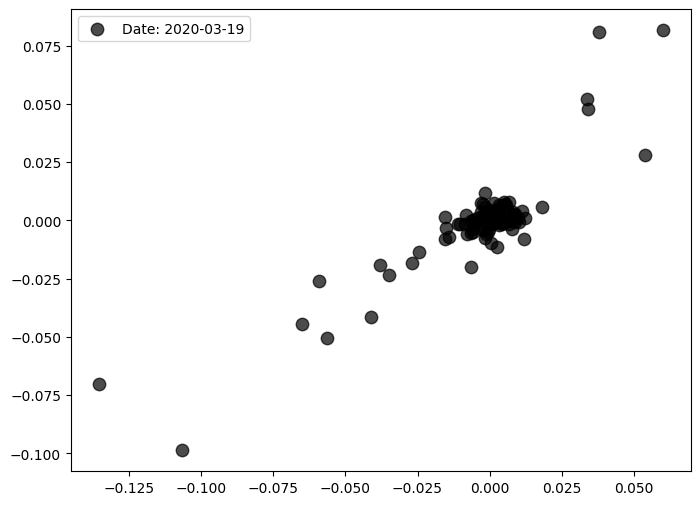

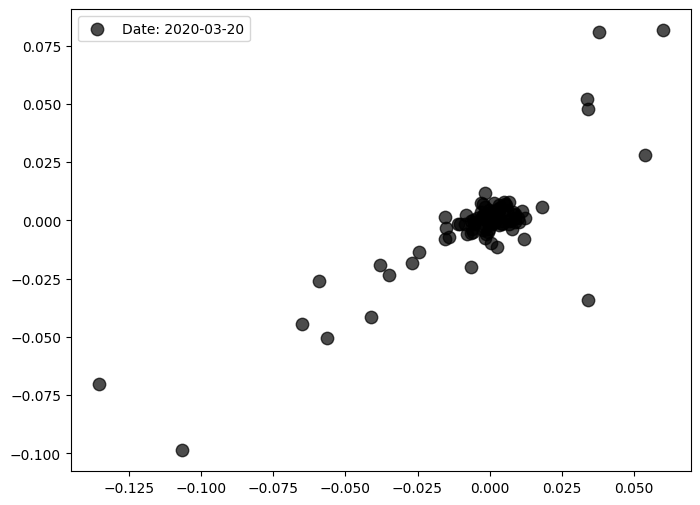

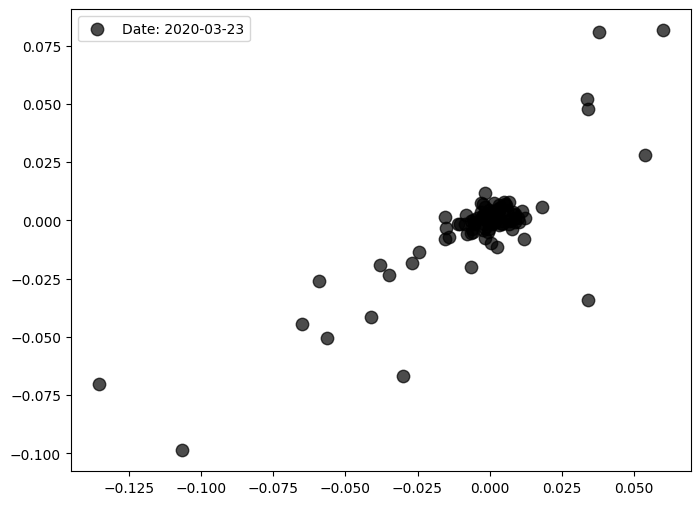

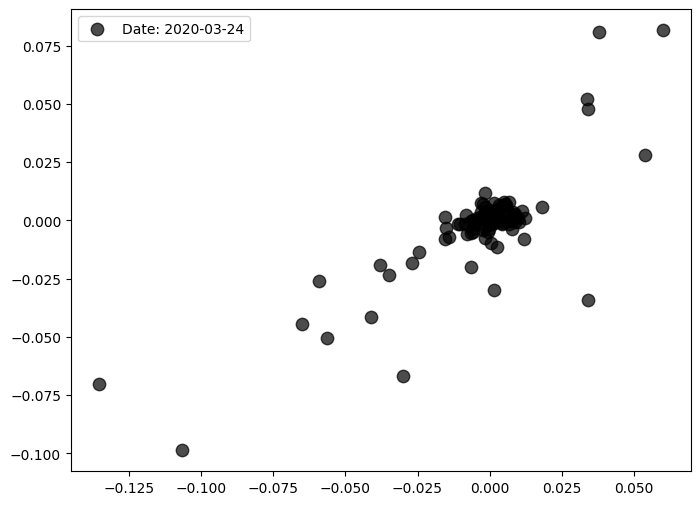

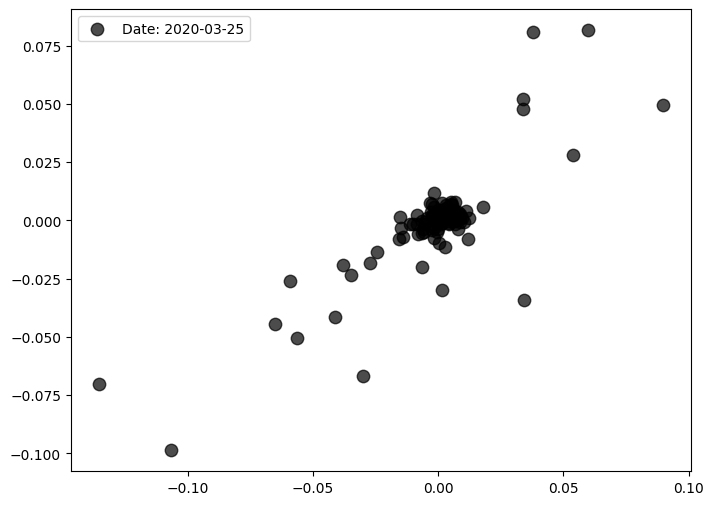

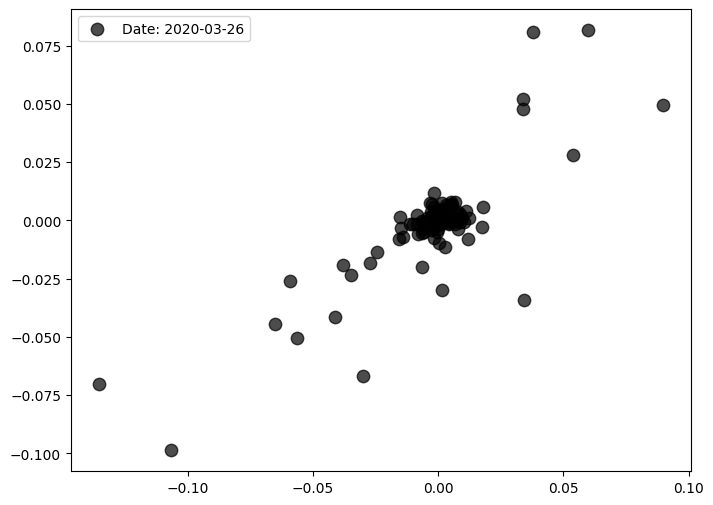

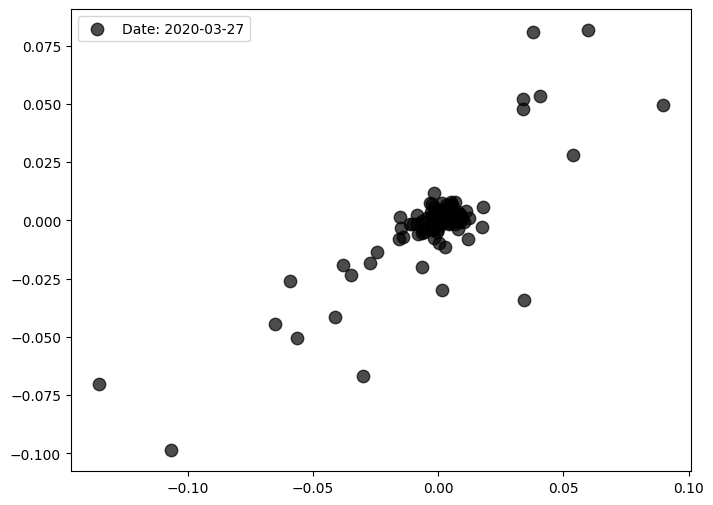

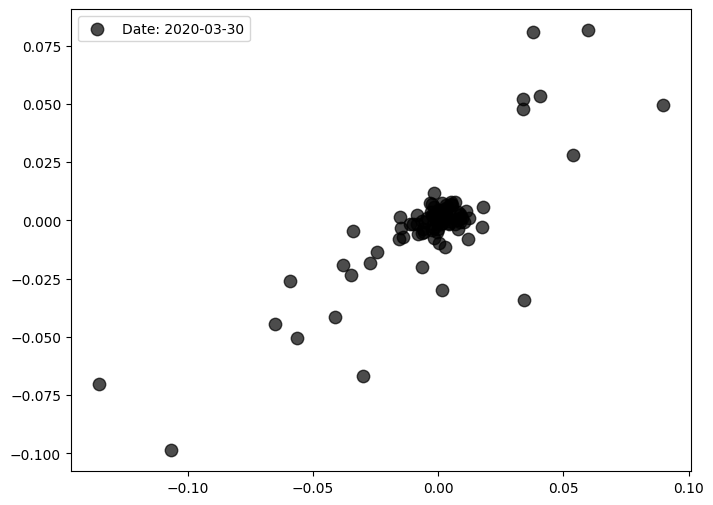

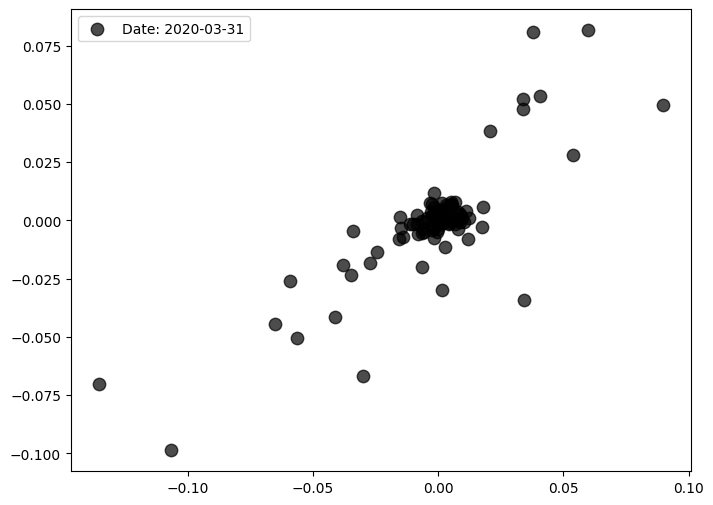

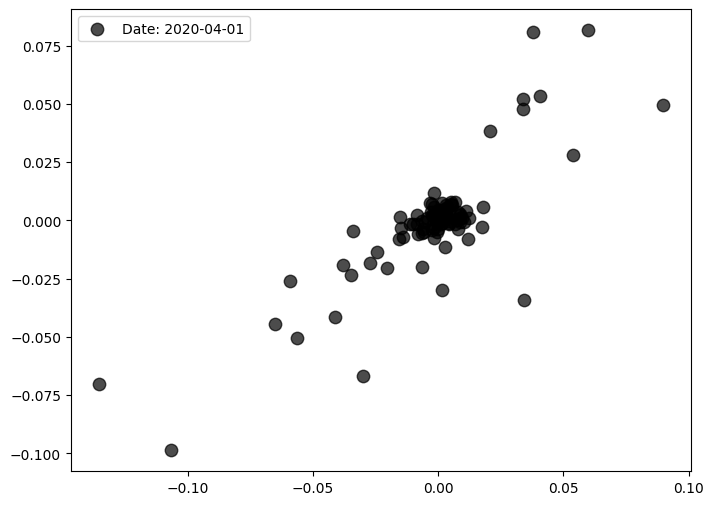

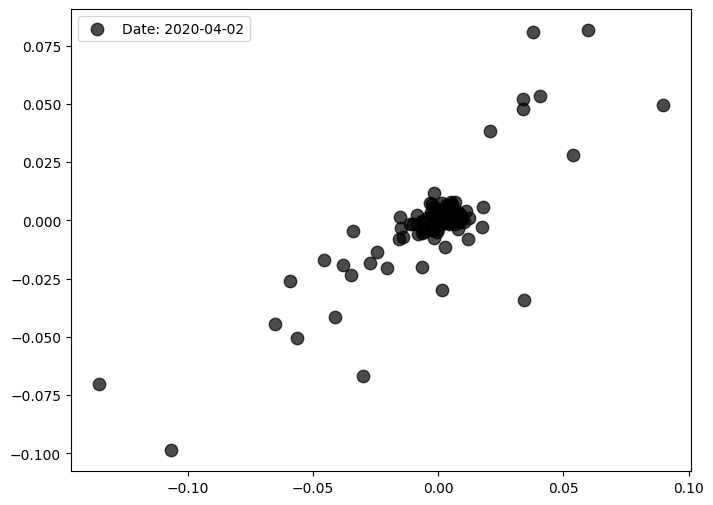

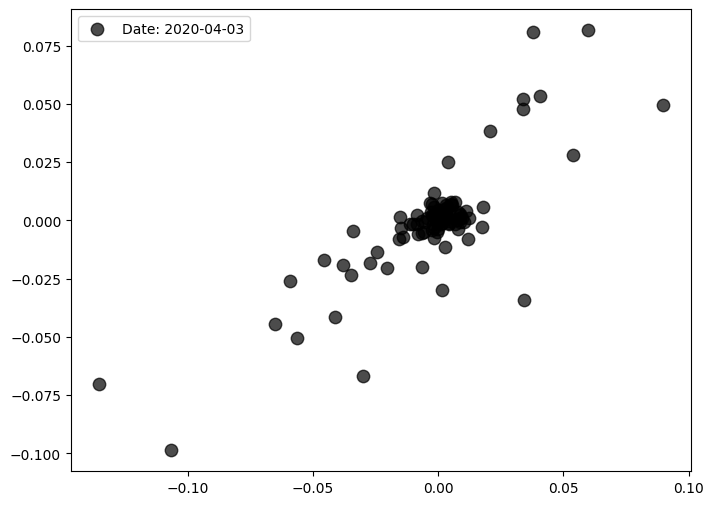

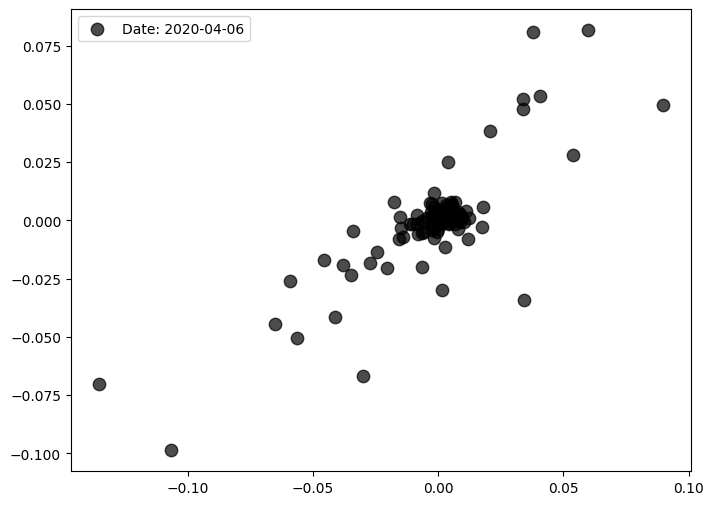

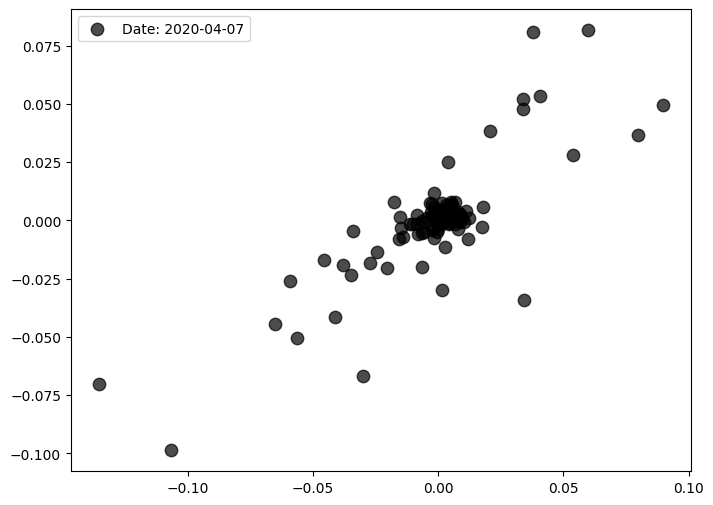

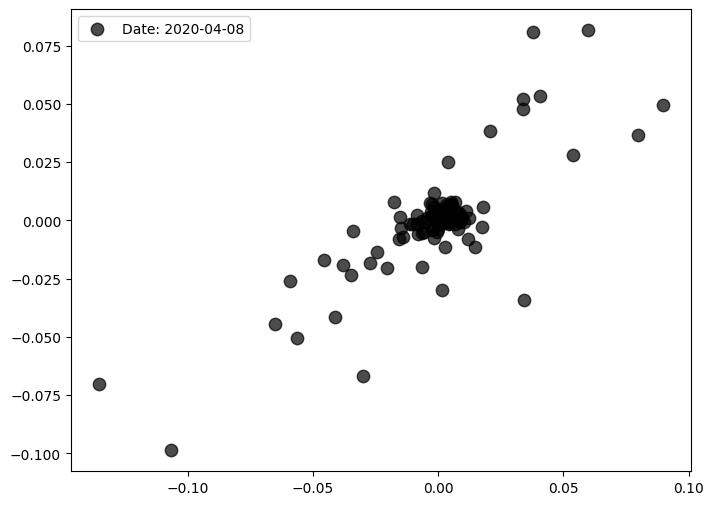

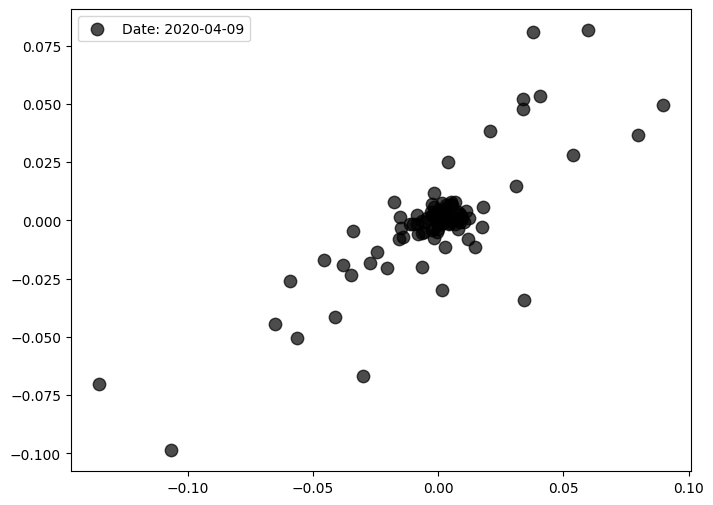

100%|██████████| 2384/2384 [00:06<00:00, 346.76it/s]


In [53]:
from tqdm import tqdm
import gudhi.representations as grepr

w = 100 # window size
diagrams_returns = []

covid_date = pd.Timestamp("2020-03-11")
for i in tqdm(range(w, len(log_returns))):
    window = log_returns.iloc[i-w:i].values  # shape (w, 4)
    rips = ripser.ripser(window)
    diagrams_returns.append(rips['dgms'])

    if np.abs(log_returns.index[i] - covid_date) < pd.Timedelta(days=30):
        # plot the point cloud of the current window
        plt.figure(figsize=(8, 6))
        date = log_returns.index[i]
        plt.scatter(window[:, 0], window[:, 1], c='black', s=80, alpha=0.7, label=f'Date: {date.date()}')
        plt.legend()
        plt.show()

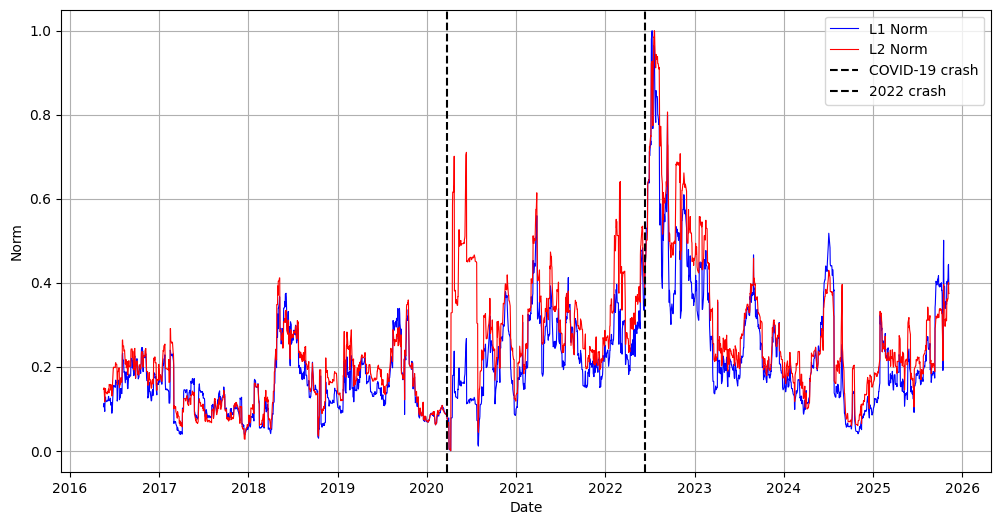

In [ ]:
# on two subplots, one is normalized L1 and L2 norms of persistence landscapes over time, other is VIX time series
l1_norms_returns = []
l2_norms_returns = []
for diag in diagrams_returns:
    pl = grepr.Landscape(num_landscapes=10, resolution=500)
    landscape = pl.fit_transform([diag[1]])[0]
    l1_norms_returns.append(np.sum(np.abs(landscape)))
    l2_norms_returns.append(np.sqrt(np.sum(landscape**2)))

# normalize between 0 and 1
l1_norms_returns = (np.array(l1_norms_returns) - np.min(l1_norms_returns)) / (np.max(l1_norms_returns) - np.min(l1_norms_returns))
l2_norms_returns = (np.array(l2_norms_returns) - np.min(l2_norms_returns)) / (np.max(l2_norms_returns) - np.min(l2_norms_returns))

dates = log_returns.index

# on two subplots, one is both normalized L1 / L2 norms of persistence landscapes over time, other is VIX time series
# add vertical lines corresponding to COVID-19 market crash (March 23, 2020) and 2022 market crash (June 13, 2022)
plt.figure(figsize=(12, 6))
plt.plot(dates[w:], l1_norms_returns, label='L1 Norm', color='blue', linewidth=0.8)
plt.plot(dates[w:], l2_norms_returns, label='L2 Norm', color='red', linewidth=0.8)
plt.axvline(pd.Timestamp('2020-03-23'), color='black', linestyle='--', label='COVID-19 crash')
plt.axvline(pd.Timestamp('2022-06-13'), color='BLACK', linestyle='--', label='2022 crash')
plt.xlabel("Date")
plt.ylabel("Norm")
plt.legend()
plt.show()

In [66]:
# use the library ruptures to detect change points in the L2 norm time series.
import ruptures as rpt

l2_signal = l2_norms_returns.reshape(-1, 1)
model = "l2"
algo = rpt.Pelt(model=model).fit(l2_signal)
result = algo.predict(pen=3)

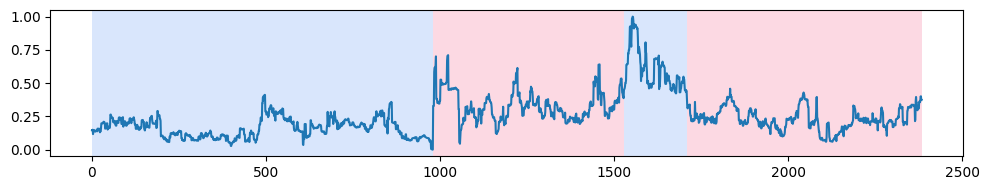

In [67]:
# plot the change points on the L2 norm time series
rpt.display(l2_signal, result)
plt.show()

In [57]:
# employ the 500 days rolling window with the sliding step of one day to calculate the variance, the average spectral density at low frequencies and the firstlag of the auto-correlation function (ACF) of the L2 norm for 250 trading days prior to the date of a market crash

import statsmodels.api as sm
from scipy.signal import welch

window_size = 500
variances = []
avg_spectral_densities = []
firstlags = []

for i in tqdm(range(window_size, len(l2_norms_returns))):
    window = pd.Series(l2_norms_returns[i-window_size:i])
    
    # Variance
    variance = window.var()
    variances.append(variance)
    
    # Average spectral density at low frequencies
    f, Pxx = welch(window.values, fs=1.0)
    low_freq_indices = f < 0.1
    avg_spectral_density = Pxx[low_freq_indices].mean()
    avg_spectral_densities.append(avg_spectral_density)

    # First lag of the Auto-Correlation Function (ACF)
    acf_values = sm.tsa.acf(window.values, nlags=1, fft=True)
    firstlag = acf_values[1].mean()
    firstlags.append(firstlag)

100%|██████████| 1884/1884 [00:00<00:00, 5117.43it/s]


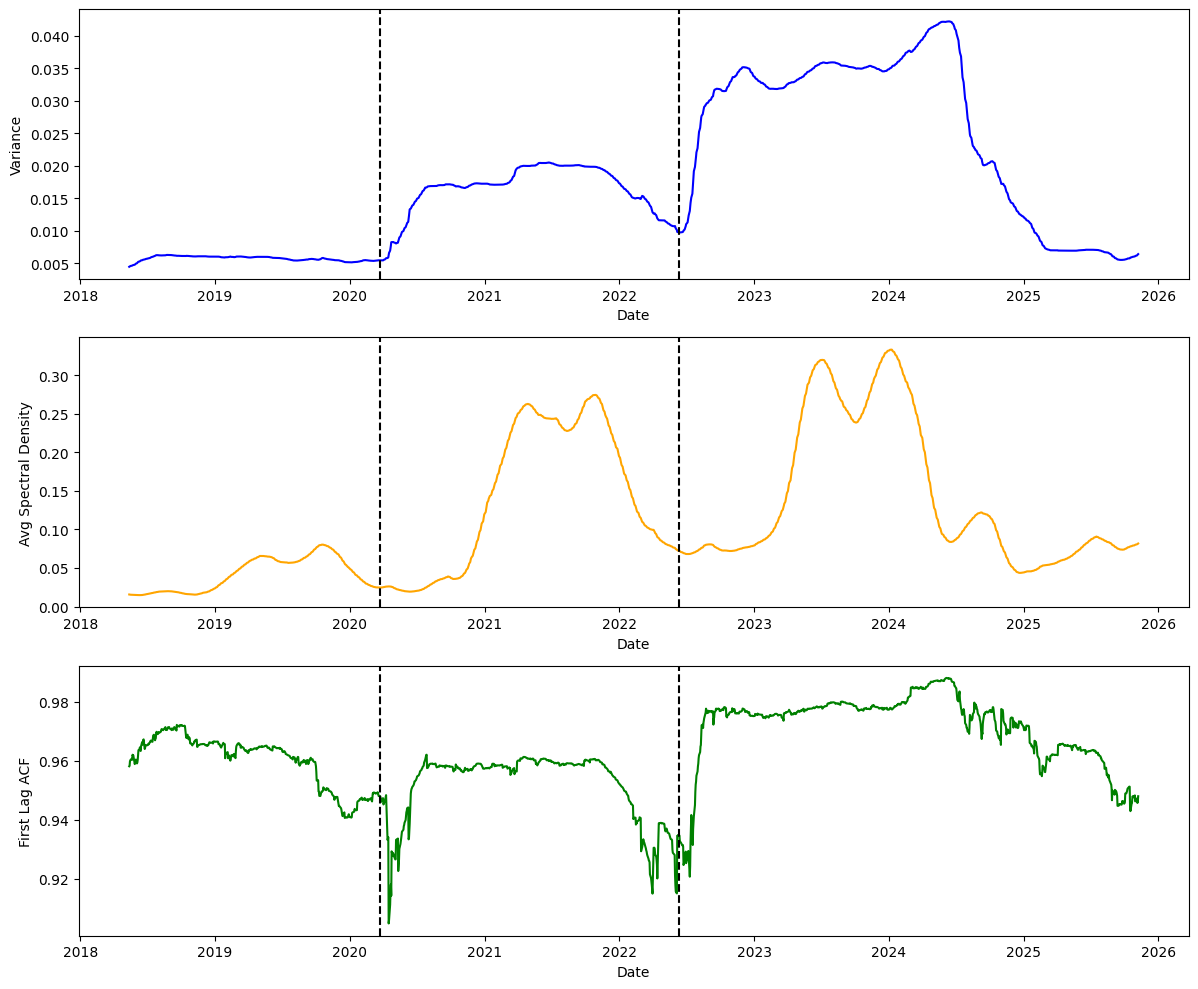

In [58]:
# plot variance, average spectral density, and firstlag over time

plt.figure(figsize=(12, 10))
plt.subplot(3, 1, 1)
plt.plot(dates[window_size+100:], variances, label='Variance', color='blue')
plt.axvline(pd.Timestamp("2020-03-23"), color='black', linestyle='--',  label='Covid-19 crash')
plt.axvline(pd.Timestamp('2022-06-13'), color='black', linestyle='--', label='2022 crash')
plt.xlabel("Date")
plt.ylabel("Variance")
plt.subplot(3, 1, 2)
plt.plot(dates[window_size+100:], avg_spectral_densities, label='Avg Spectral Density', color='orange')
plt.axvline(pd.Timestamp("2020-03-23"), color='black', linestyle='--',  label='Covid-19 crash')
plt.axvline(pd.Timestamp('2022-06-13'), color='black', linestyle='--', label='2022 crash')
plt.xlabel("Date")
plt.ylabel("Avg Spectral Density")
plt.subplot(3, 1, 3)
plt.plot(dates[window_size+100:], firstlags, label='First Lag ACF', color='green')
plt.axvline(pd.Timestamp("2020-03-23"), color='black', linestyle='--',  label='Covid-19 crash')
plt.axvline(pd.Timestamp('2022-06-13'), color='black', linestyle='--', label='2022 crash')
plt.xlabel("Date")
plt.ylabel("First Lag ACF")
plt.tight_layout()
plt.show()